<div style='text-align: center'>
    <p style='font-size:50px; margin-bottom: 0px'>Summary statistics</p>
    <o style='font-size:20px;'>This notebook handles calculating stats for all variations and putting them into a table</p>
</div>

In [1]:
import cogsworth
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib as mpl

import sys
sys.path.append('../src')
import plotting, helpers, constants
from importlib import reload

%config InlineBackend.figure_format = 'retina'


pd.options.display.max_columns = 999

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

In [2]:
reload(constants)
files = constants.SIMULATION_FILES

main_labels = [
    r"$f_{\rm bin} = 1.0$",
    "No BH kicks", "Hobbs+2005", "No fallback rescaling",
    "Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025",
    r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$",
    r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$",
    'Time-evolving potential'
]
markers = ['o'] * (len(main_labels) - 1) + ['d']
initC_labels = [
    r"$f_{\rm bin} = 0.0$",
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$"
]
markers += ['^'] * len(initC_labels)
main_labels += initC_labels
mt_labels = [
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$",
]
markers += ['s'] * len(mt_labels)
labels = main_labels + mt_labels
mt_labels = [main_labels[0]] + mt_labels  # include the fiducial model in the MT section

In [3]:
plot_labels = [
    "Fiducial",
    "No BH kicks",
    "Hobbs+2005",
    "No fallback rescaling",
    "Fryer+2012 Rapid", r"Mandel & Muller 2020", "Maltsev+2025 (Default)",
    r"Maltsev+2025 ($f_{\rm fb} = 0.0$)", r"Maltsev+2025 ($f_{\rm fb} = 0.25$)", r"Maltsev+2025 ($f_{\rm fb} = 0.75$)", r"Maltsev+2025 ($f_{\rm fb} = 1.0$)",
    r"Maltsev+2025 ($P({\rm pf}) = 0.0$)", r"Maltsev+2025 ($P({\rm pf}) = 1.0$)",
    'Time-evolving potential',
    # initC
    "Single star evolution",
    r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$",
    r"$\kappa = -1.0$", r"$\kappa = 1.0$",
    r"$q_{\rm min} = -1.0$",
    r"$\pi = 0.0$", r"$\pi = -1.0$",
    r"$P_{\rm orb, max} = 10^3\,{\rm days}$",
    # mt
    r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$",
    r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$",
    r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"
]

In [4]:
groups = [
    {
        "title": "Fiducial",
        "members": [r"$f_{\rm bin} = 1.0$"],
        "colour": "black"
    },
    {
        "title": "Supernova natal kicks",
        "members": ["No BH kicks", "Hobbs+2005", "No fallback rescaling"],
        "colour": "tab:green"
    },
    {
        "title": "Remnant mass prescriptions",
        "members": ["Fryer+2012 Rapid", r"Mandel\&Muller2020", "Maltsev+2025", r"$f_{\rm fb} = 0.0$", r"$f_{\rm fb} = 0.25$", r"$f_{\rm fb} = 0.75$", r"$f_{\rm fb} = 1.0$", r"$P({\rm pf}) = 0.0$", r"$P({\rm pf}) = 1.0$"],
        "colour": "#f14432"
    },
    {
        "title": "Time-evolving potential",
        "members": ['Time-evolving potential'],
        "colour": "#FF9D1E"
    },
    {
        "title": "Initial distributions",
        "members": [r"$f_{\rm bin} = 0.0$", r"$\alpha_{\rm IMF} = -1.9$", r"$\alpha_{\rm IMF} = -2.7$", r"$\kappa = -1.0$", r"$\kappa = 1.0$", r"$q_{\rm min} = -1.0$", r"$\pi = 0.0$", r"$\pi = -1.0$", r"$P_{\rm orb, max} = 10^3\,{\rm days}$"],
        "colour": "black"
    },
    {
        "title": "Mass transfer physics",
        "members": [r"$\beta = 0.0$", r"$\beta = 0.5$", r"$\beta = 1.0$", r"$\alpha_{\rm CE} = 0.1$", r"$\alpha_{\rm CE} = 0.5$", r"$\alpha_{\rm CE} = 2.0$", r"$\alpha_{\rm CE} = 10.0$", r"$q_{\rm crit, B} = 0$", r"$q_{\rm crit, B} = \infty$"],
        "colour": "tab:blue"
    }
]

group_spacing = 2.0
member_spacing = 1.0

y_positions = [("group", "Fiducial", (group_spacing + member_spacing) / 2)]
group_ind = 0
label_ind = 0
while label_ind < len(labels):
    label = labels[label_ind]
    if label not in groups[group_ind]["members"]:
        group_ind += 1
        y_positions.append(("group", groups[group_ind]["title"], (group_spacing + member_spacing) / 2))
        continue

    y_positions.append(("member", label, member_spacing))
    label_ind += 1

In [ ]:
reload(helpers)
pops, data = helpers.load_postprocessed_pops(files, labels, [None] * len(files))

Loading post-processed data for $f_{\rm bin} = 1.0$ from fiducial
Loading post-processed data for No BH kicks from bhflag_0
Loading post-processed data for Hobbs+2005 from kickflag_1
Loading post-processed data for No fallback rescaling from bhflag_3
Loading post-processed data for Fryer+2012 Rapid from fryer_rapid
Loading post-processed data for Mandel\&Muller2020 from mandel_muller
Loading post-processed data for Maltsev+2025 from maltsev_fallback_0.5
Loading post-processed data for $f_{\rm fb} = 0.0$ from maltsev_fallback_0.0
Loading post-processed data for $f_{\rm fb} = 0.25$ from maltsev_fallback_0.25
Loading post-processed data for $f_{\rm fb} = 0.75$ from maltsev_fallback_0.75
Loading post-processed data for $f_{\rm fb} = 1.0$ from maltsev_fallback_1.0
Loading post-processed data for $P({\rm pf}) = 0.0$ from maltsev_pf_prob_0.0
Loading post-processed data for $P({\rm pf}) = 1.0$ from maltsev_pf_prob_1.0
Loading post-processed data for Time-evolving potential from time-evolving-p

In [6]:
for pop in pops:
    if "companion" not in data[pop.label]:
        for key in ["n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]:
            data[pop.label][key] = np.nan
        print("Skipping", pop.label)
        continue
    data[pop.label]["n_BH_star"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] < 10))
    data[pop.label]["n_BH_wd"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (np.isin(data[pop.label]["companion"]["BH"], [10, 11, 12])))
    data[pop.label]["n_BH_NS"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["companion"]["BH"] == 13))
    data[pop.label]["n_BH_BH"] = np.sum((data[pop.label]["sep"]["BH"] > 0) & (data[pop.label]["primary"]["BH"]) & (data[pop.label]["companion"]["BH"] == 14))

    data[pop.label]["n_NS_star"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["companion"]["NS"] < 10))
    data[pop.label]["n_NS_wd"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (np.isin(data[pop.label]["companion"]["NS"], [10, 11, 12])))
    data[pop.label]["n_NS_NS"] = np.sum((data[pop.label]["sep"]["NS"] > 0) & (data[pop.label]["primary"]["NS"]) & (data[pop.label]["companion"]["NS"] == 13))

In [7]:
reload(plotting)

scale_heights = []

for label, colour in zip(labels, constants.SIMULATION_COLOURS):
    sh, sh_err, _, _ = plotting.estimate_scale_height_cdf(
        z=data[label]["pos"]["BH"][:, 2][~data[label]["escaped"]["BH"]],
        xlim=(1e-2, 1e2),
    )
    scale_heights.append(sh * 1000)

In [8]:
stats = {
    "scale_up": [6e10 / data[label]["mass_binaries"] for label in labels],
    "n_BH": [data[label]["n_BH"] for label in labels],
    "m_BH": [sum(data[label]["mass"]["BH"]) for label in labels],
    "scale_height": scale_heights,
    r"$f_{\rm esc}$": [data[label]["escaped"]["BH"].sum() / len(data[label]["escaped"]["BH"])
                       for label in labels],
    r"$\median{m_{|z| < 1 \, {\rm kpc}}}$": [np.median(data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) < 1) & ~(data[label]["escaped"]["BH"])]) for label in labels],
    r"$\median{m_{|z| \geq 1 \, {\rm kpc}}}$": [np.median(data[label]["mass"]["BH"][(abs(data[label]["pos"]["BH"][:, 2]) >= 1) & ~(data[label]["escaped"]["BH"])]) for label in labels],
    r"$f_{\rm bound}$": [(data[label]["sep"]["BH"] > 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm merger}$": [(data[label]["sep"]["BH"] == 0).sum() / data[label]["n_BH"] for label in labels],
    r"$f_{\rm unbound}$": [(data[label]["sep"]["BH"] < 0).sum() / data[label]["n_BH"] for label in labels],
    "n_BH_star": [data[label]["n_BH_star"] for label in labels],
    "n_BH_wd": [data[label]["n_BH_wd"] for label in labels],
    "n_BH_NS": [data[label]["n_BH_NS"] for label in labels],
    "n_BH_BH": [data[label]["n_BH_BH"] for label in labels],
    "n_NS_star": [data[label]["n_NS_star"] for label in labels],
    "n_NS_wd": [data[label]["n_NS_wd"] for label in labels],
    "n_NS_NS": [data[label]["n_NS_NS"] for label in labels],
}

df = pd.DataFrame(stats)
df.index = labels

# fix stats for singles because wide binaries make it funky
df.loc[r"$f_{\rm bin} = 0.0$", [r"$f_{\rm bound}$", r"$f_{\rm merger}$", r"$f_{\rm unbound}$", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"]] = [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]

for col, norm in zip(
    ["n_BH", "m_BH", "n_BH_star", "n_BH_wd", "n_BH_NS", "n_BH_BH", "n_NS_star", "n_NS_wd", "n_NS_NS"],
    [1e8, 1e9, 1e4, 1e5, 1e5, 1e6, 1e4, 1e5, 1e4]
):
    df[col] *= df["scale_up"] / norm
del df["scale_up"]

latex_header = [r"$N_{\rm BH} / 10^8$", r"$M_{\rm BH} / 10^9 M_\odot$", r"$h_{z, {\rm eff}}$ (pc)"]
df.rename(columns=dict(zip(df.columns, latex_header)), inplace=True)
df.rename(columns={
    "n_BH_star": r"$N_{\rm BH\text{-}star} / 10^4$",
    "n_BH_wd": r"$N_{\rm BH\text{-}WD} / 10^5$",
    "n_BH_NS": r"$N_{\rm BH\text{-}NS} / 10^5$",
    "n_BH_BH": r"$N_{\rm BH\text{-}BH} / 10^6$",
    "n_NS_star": r"$N_{\rm NS\text{-}star} / 10^4$",
    "n_NS_wd": r"$N_{\rm NS\text{-}WD} / 10^5$",
    "n_NS_NS": r"$N_{\rm NS\text{-}NS} / 10^4$",
}, inplace=True)

df.round(2)

,$N_{\rm BH} / 10^8$,$M_{\rm BH} / 10^9 M_\odot$,"$h_{z, {\rm eff}}$ (pc)",$f_{\rm esc}$,"$\median{m_{|z| < 1 \, {\rm kpc}}}$","$\median{m_{|z| \geq 1 \, {\rm kpc}}}$",$f_{\rm bound}$,$f_{\rm merger}$,$f_{\rm unbound}$,$N_{\rm BH\text{-}star} / 10^4$,$N_{\rm BH\text{-}WD} / 10^5$,$N_{\rm BH\text{-}NS} / 10^5$,$N_{\rm BH\text{-}BH} / 10^6$,$N_{\rm NS\text{-}star} / 10^4$,$N_{\rm NS\text{-}WD} / 10^5$,$N_{\rm NS\text{-}NS} / 10^4$
$f_{\rm bin} = 1.0$,1.73,1.50,786.34,0.03,7.70,6.22,0.09,0.33,0.58,17.07,12.71,1.39,6.70,41.93,30.41,9.76
No BH kicks,1.69,1.46,378.53,0.00,6.84,8.62,0.33,0.35,0.32,74.29,56.37,4.03,24.30,41.92,30.55,9.49
Hobbs+2005,1.81,1.56,1122.23,0.03,8.15,6.08,0.07,0.31,0.62,15.53,10.78,0.51,5.95,31.67,21.72,5.15
No fallback rescaling,1.77,1.54,2557.12,0.16,6.38,7.75,0.00,0.30,0.69,2.25,2.76,0.45,0.24,42.53,30.77,8.64
Fryer+2012 Rapid,1.34,1.50,518.82,0.01,9.30,8.62,0.15,0.34,0.51,38.01,24.79,3.53,8.60,39.44,25.97,8.79
Mandel\&Muller2020,2.17,1.90,368.38,0.00,8.19,7.11,0.26,0.41,0.32,102.77,79.96,3.23,23.75,38.52,23.81,7.92
Maltsev+2025,0.38,0.47,467.53,0.01,9.66,7.83,0.18,0.31,0.51,15.03,10.57,3.73,2.50,40.00,27.95,8.72
$f_{\rm fb} = 0.0$,0.30,0.42,397.64,0.00,9.82,9.92,0.21,0.31,0.48,15.06,10.54,3.86,2.45,40.74,27.88,8.55
$f_{\rm fb} = 0.25$,0.37,0.45,469.76,0.02,9.70,5.19,0.18,0.30,0.52,15.06,10.59,3.64,2.48,40.05,27.95,8.53
$f_{\rm fb} = 0.75$,0.38,0.49,442.01,0.00,9.76,9.60,0.18,0.31,0.51,15.15,10.75,4.06,2.57,40.52,27.86,8.53


# Main summary table

In [11]:
first_label_to_section = {
    "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$f_{\rm bin} = 0.0$": "Single star evolution",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution"
}

cols = df.columns.values[:8]
latex_table = r"""\begin{tabular}{lcccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False



for i, row in df.loc[main_labels].iterrows():
    if i in first_label_to_section:

        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{8}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row.values

    bound_perc = fr"${vals[6] * 100:1.0f}\%$" if not np.isnan(vals[6]) else "-"
    merger_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    latex_table += model_name + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f}$ & {vals[3] * 100:1.1f}\% & ${vals[4]:.2f}$ & ${vals[5]:.2f}$ & {bound_perc} & {merger_perc} \\\\' + "\n"

latex_table += r"\hline\hline" + "\n"
latex_table += r"\textbf{Summary statistics} \\" + "\n"
min_med_max = df.loc[main_labels].describe()[cols].loc[["min", "50%", "max"]]
for col, l in zip(["min", "50%", "max"], ["Minimum", "Median", "Maximum"]):
    vals = min_med_max.loc[col].values
    bound_perc = fr"${vals[6] * 100:1.0f}\%$" if not np.isnan(vals[6]) else "-"
    merger_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"
    latex_table += f'\\quad {l} & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f}$ & ${vals[3] * 100:1.1f}\%$ & ${vals[4]:.2f}$ & ${vals[5]:.2f}$ & {bound_perc} & {merger_perc} \\\\' + "\n"

latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_{z, {\rm eff}}$ (pc) & $f_{\rm esc}$ & $\median{m_{|z| < 1 \, {\rm kpc}}}$ & $\median{m_{|z| \geq 1 \, {\rm kpc}}}$ & $f_{\rm bound}$ & $f_{\rm merger}$ \\
\midrule
\textbf{Fiducial} & $1.73$ & $1.50$ & $786$ & 2.7\% & $7.70$ & $6.22$ & $9\%$ & $33\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $1.69$ & $1.46$ & $379$ & 0.0\% & $6.84$ & $8.62$ & $33\%$ & $35\%$ \\
\quad Hobbs+2005 & $1.81$ & $1.56$ & $1122$ & 2.6\% & $8.15$ & $6.08$ & $7\%$ & $31\%$ \\
\quad No fallback rescaling & $1.77$ & $1.54$ & $2557$ & 15.5\% & $6.38$ & $7.75$ & $0\%$ & $30\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $1.34$ & $1.50$ & $519$ & 0.7\% & $9.30$ & $8.62$ & $15\%$ & $34\%$ \\
\quad Mandel\&Muller2020 & $2.17$ & $1.90$ & $368$ & 0.1\% & $8.19$ & $7.11$ & $26\%$ & $41\%$ \\
\quad Maltsev+

In [145]:
first_label_to_section = {
    # r"$f_{\rm bin} = 1.0$": "Fiducial",
    "No BH kicks": "Supernova natal kicks",
    "Fryer+2012 Rapid": "Remnant mass prescriptions",
    r"$f_{\rm fb} = 0.0$": "Maltsev+2025 fallback mass fraction",
    r"$P({\rm pf}) = 0.0$": "Maltsev+2025 partial fallback probability",
    "Time-evolving potential": "Galactic gravitational potential",
    r"$\alpha_{\rm IMF} = -1.9$": "Initial mass function",
    r"$\kappa = -1.0$": "Initial mass ratio distribution",
    r"$\pi = 0.0$": "Initial orbital period distribution",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = [col for col in df.columns if col != r"$\sigma_{h_z}$ (pc)"]
cols = cols[-7:-3]
latex_table = r"\begin{tabular}{l" + "c" * len(cols) + r"""}
\toprule
"""
latex_table += "Model & " + " & ".join(cols) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

in_maltsev_subsection = False

for i, row in df.iterrows():
    if i == r"$f_{\rm bin} = 0.0$":
        continue
    if i in first_label_to_section:
        if first_label_to_section[i].startswith("Maltsev+2025"):
            in_maltsev_subsection = True
            first_label_to_section[i] = r"\quad " + first_label_to_section[i]
        else:
            in_maltsev_subsection = False
            # add a small bit of vertical space before the section header
            latex_table += r"\addlinespace[0.5em]" + "\n"

        header_type = "bf" if not in_maltsev_subsection else "it"
        latex_table += r"\multicolumn{" + str(len(cols)) + "}{l}{" + r"\text" + header_type + "{" + first_label_to_section[i] + r"}} \\" + "\n"

    vals = row[cols].values

    vals_str = [f"${val:.1f}$" for val in vals]

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    latex_table += model_name + f' & {" & ".join(vals_str)} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccc}
\toprule
Model & $N_{\rm BH\text{-}star} / 10^4$ & $N_{\rm BH\text{-}WD} / 10^5$ & $N_{\rm BH\text{-}NS} / 10^5$ & $N_{\rm BH\text{-}BH} / 10^6$ \\
\midrule
\textbf{Fiducial} & $17.1$ & $12.7$ & $1.4$ & $6.7$ \\
\addlinespace[0.5em]
\multicolumn{4}{l}{\textbf{Supernova natal kicks}} \\
\quad No BH kicks & $74.3$ & $56.4$ & $4.0$ & $24.3$ \\
\quad Hobbs+2005 & $15.5$ & $10.8$ & $0.5$ & $5.9$ \\
\quad No fallback rescaling & $2.2$ & $2.8$ & $0.5$ & $0.2$ \\
\addlinespace[0.5em]
\multicolumn{4}{l}{\textbf{Remnant mass prescriptions}} \\
\quad Fryer+2012 Rapid & $38.0$ & $24.8$ & $3.5$ & $8.6$ \\
\quad Mandel\&Muller2020 & $102.8$ & $80.0$ & $3.2$ & $23.7$ \\
\quad Maltsev+2025 & $15.0$ & $10.6$ & $3.7$ & $2.5$ \\
\multicolumn{4}{l}{\textit{\quad Maltsev+2025 fallback mass fraction}} \\
\quad\quad $f_{\rm fb} = 0.0$ & $15.1$ & $10.5$ & $3.9$ & $2.5$ \\
\quad\quad $f_{\rm fb} = 0.25$ & $15.1$ & $10.6$ & $3.6$ & $2.5$ \\
\quad\quad $f_{\rm fb} = 0.75$ & $15.2$ & $10.8$

# Appendix MT summary plot

In [12]:
first_label_to_section = {
    # r"$f_{\rm bin} = 1.0$": "Fiducial",
    r"$\beta = 0.0$": "Mass transfer efficiency",
    r"$\alpha_{\rm CE} = 0.1$": "Common-envelope efficiency",
    r"$q_{\rm crit, B} = 0$": "Mass transfer stability",
}

cols = df.columns.values[:8]
latex_table = r"""\begin{tabular}{lcccccccc}
\toprule
"""
latex_table += "Model & " + " & ".join(cols) + r" \\" + "\n"
latex_table += r"\midrule" + "\n"

for i, row in df.loc[mt_labels].iterrows():
    if i in first_label_to_section:
        # add a small bit of vertical space before the section header
        latex_table += r"\addlinespace[0.5em]" + "\n"
        latex_table += r"\multicolumn{8}{l}{" + r"\textbf{" + first_label_to_section[i] + r"}} \\" + "\n"
    vals = row.values

    model_name = r"\quad" + (r"\quad " if in_maltsev_subsection else " ") + i
    if i == r"$f_{\rm bin} = 1.0$":
        model_name = r"\textbf{Fiducial}"

    bound_perc = fr"${vals[6] * 100:1.0f}\%$" if not np.isnan(vals[6]) else "-"
    merger_perc = fr"${vals[7] * 100:1.0f}\%$" if not np.isnan(vals[7]) else "-"

    latex_table += model_name + f' & ${vals[0]:.2f}$ & ${vals[1]:.2f}$ & ${vals[2]:.0f}$ & {vals[3] * 100:1.1f}\% & ${vals[4]:.2f}$ & ${vals[5]:.2f}$ & {bound_perc} & {merger_perc} \\\\' + "\n"
latex_table += r"\bottomrule" + "\n"
latex_table += r"\end{tabular}"

print(latex_table)

\begin{tabular}{lcccccccc}
\toprule
Model & $N_{\rm BH} / 10^8$ & $M_{\rm BH} / 10^9 M_\odot$ & $h_{z, {\rm eff}}$ (pc) & $f_{\rm esc}$ & $\median{m_{|z| < 1 \, {\rm kpc}}}$ & $\median{m_{|z| \geq 1 \, {\rm kpc}}}$ & $f_{\rm bound}$ & $f_{\rm merger}$ \\
\midrule
\textbf{Fiducial} & $1.73$ & $1.50$ & $786$ & 2.7\% & $7.70$ & $6.22$ & $9\%$ & $33\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Mass transfer efficiency}} \\
\quad $\beta = 0.0$ & $1.37$ & $1.21$ & $771$ & 2.6\% & $7.91$ & $6.05$ & $11\%$ & $38\%$ \\
\quad $\beta = 0.5$ & $1.53$ & $1.34$ & $790$ & 2.7\% & $7.83$ & $6.10$ & $10\%$ & $35\%$ \\
\quad $\beta = 1.0$ & $1.73$ & $1.50$ & $786$ & 2.7\% & $7.69$ & $6.21$ & $9\%$ & $33\%$ \\
\addlinespace[0.5em]
\multicolumn{8}{l}{\textbf{Common-envelope efficiency}} \\
\quad $\alpha_{\rm CE} = 0.1$ & $1.77$ & $1.53$ & $775$ & 2.7\% & $7.65$ & $6.26$ & $8\%$ & $35\%$ \\
\quad $\alpha_{\rm CE} = 0.5$ & $1.75$ & $1.52$ & $779$ & 2.7\% & $7.67$ & $6.24$ & $9\%$ & $34\%$ \\
\quad 

# Summary plot

In [14]:
def summary_plot(label_subset, col, fig=None, ax=None, show=True, groups_to_show=groups, legend_kwargs={"loc":"lower left", "fontsize":12, "ncol":5, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={}, norm=1.0):

    default_ax_kwargs = {
        "xscale": 'log',
    }
    default_ax_kwargs.update(ax_kwargs)
    ax_kwargs = default_ax_kwargs

    if fig is None or ax is None:
        fig, ax = plt.subplots()
    
    labels_inds = np.array([labels.index(label) for label in label_subset])

    # create a legend with the labels
    handles = [plt.Line2D([0], [0], color=constants.SIMULATION_COLOURS[i], marker=markers[i], linestyle='', markersize=10) for i in labels_inds]

    if legend_kwargs is not None:
        ax.legend(handles, np.array(plot_labels)[labels_inds], **legend_kwargs)


    plot_df = df.loc[label_subset]

    vs = plot_df[col].values.copy() * norm
    cs = np.array([constants.SIMULATION_COLOURS[i] for i in labels_inds])
    ms = np.array([markers[i] for i in labels_inds])

    group_titles_to_show = [group["title"] for group in groups_to_show]
    group_ys = []
    ys = []
    current_y = 0.0
    for pos_type, label, dy in y_positions:
        if pos_type == "group" and label in group_titles_to_show:
            group_ys.append(current_y + (dy - member_spacing) / 2)
            current_y += dy
        elif pos_type == "member" and label in label_subset:
            ys.append(current_y)
            current_y += dy

    ys = np.array(ys)

    # ys = np.array([member_y_positions[i] for i in labels_inds])

    for m in np.unique(ms):
        mask = ms == m
        ax.scatter(vs[mask], ys[mask], color=cs[mask], marker=m, zorder=10, s=100)

            # print(labels[i], "not in labels_inds", member_y_positions[i], to_subtract)

    # ys = np.array([member_y_positions[i] for i in labels_inds])

    for m in np.unique(ms):
        mask = ms == m
        ax.scatter(vs[mask], ys[mask], color=cs[mask], marker=m, zorder=10, s=100)

    for group, group_y in zip(groups_to_show, group_ys):
        gc = "grey"#group["colour"]
        ax.annotate(group["title"], xy=(0.5, group_y), fontsize=12, color=gc, ha='center', va='center', xycoords=ax.get_yaxis_transform(),
                    bbox=dict(boxstyle="round,pad=0.05", fc="white", ec="white"), clip_on=True)
        ax.axhline(group_y, color=gc, ls='-', lw=1, zorder=-1)

    if group_ys == []:
        group_ys = [min(ys)]
    ax.set_ylim(top=min(min(group_ys), min(ys)) - 0.8, bottom=max(max(group_ys), max(ys)) + 0.8)

    ax.axvline(plot_df[col].values[0] * norm, color="#333", ls="--", zorder=-1, lw=1)

    ax.set(**ax_kwargs)
    ax.set_yticks([])

    ax.grid(True, which='both', axis='x', ls=':', lw=0.5, zorder=-100)
    ax.tick_params(which='both', axis='x', labelsize=16)

    if show:
        plt.show()

    return fig, ax

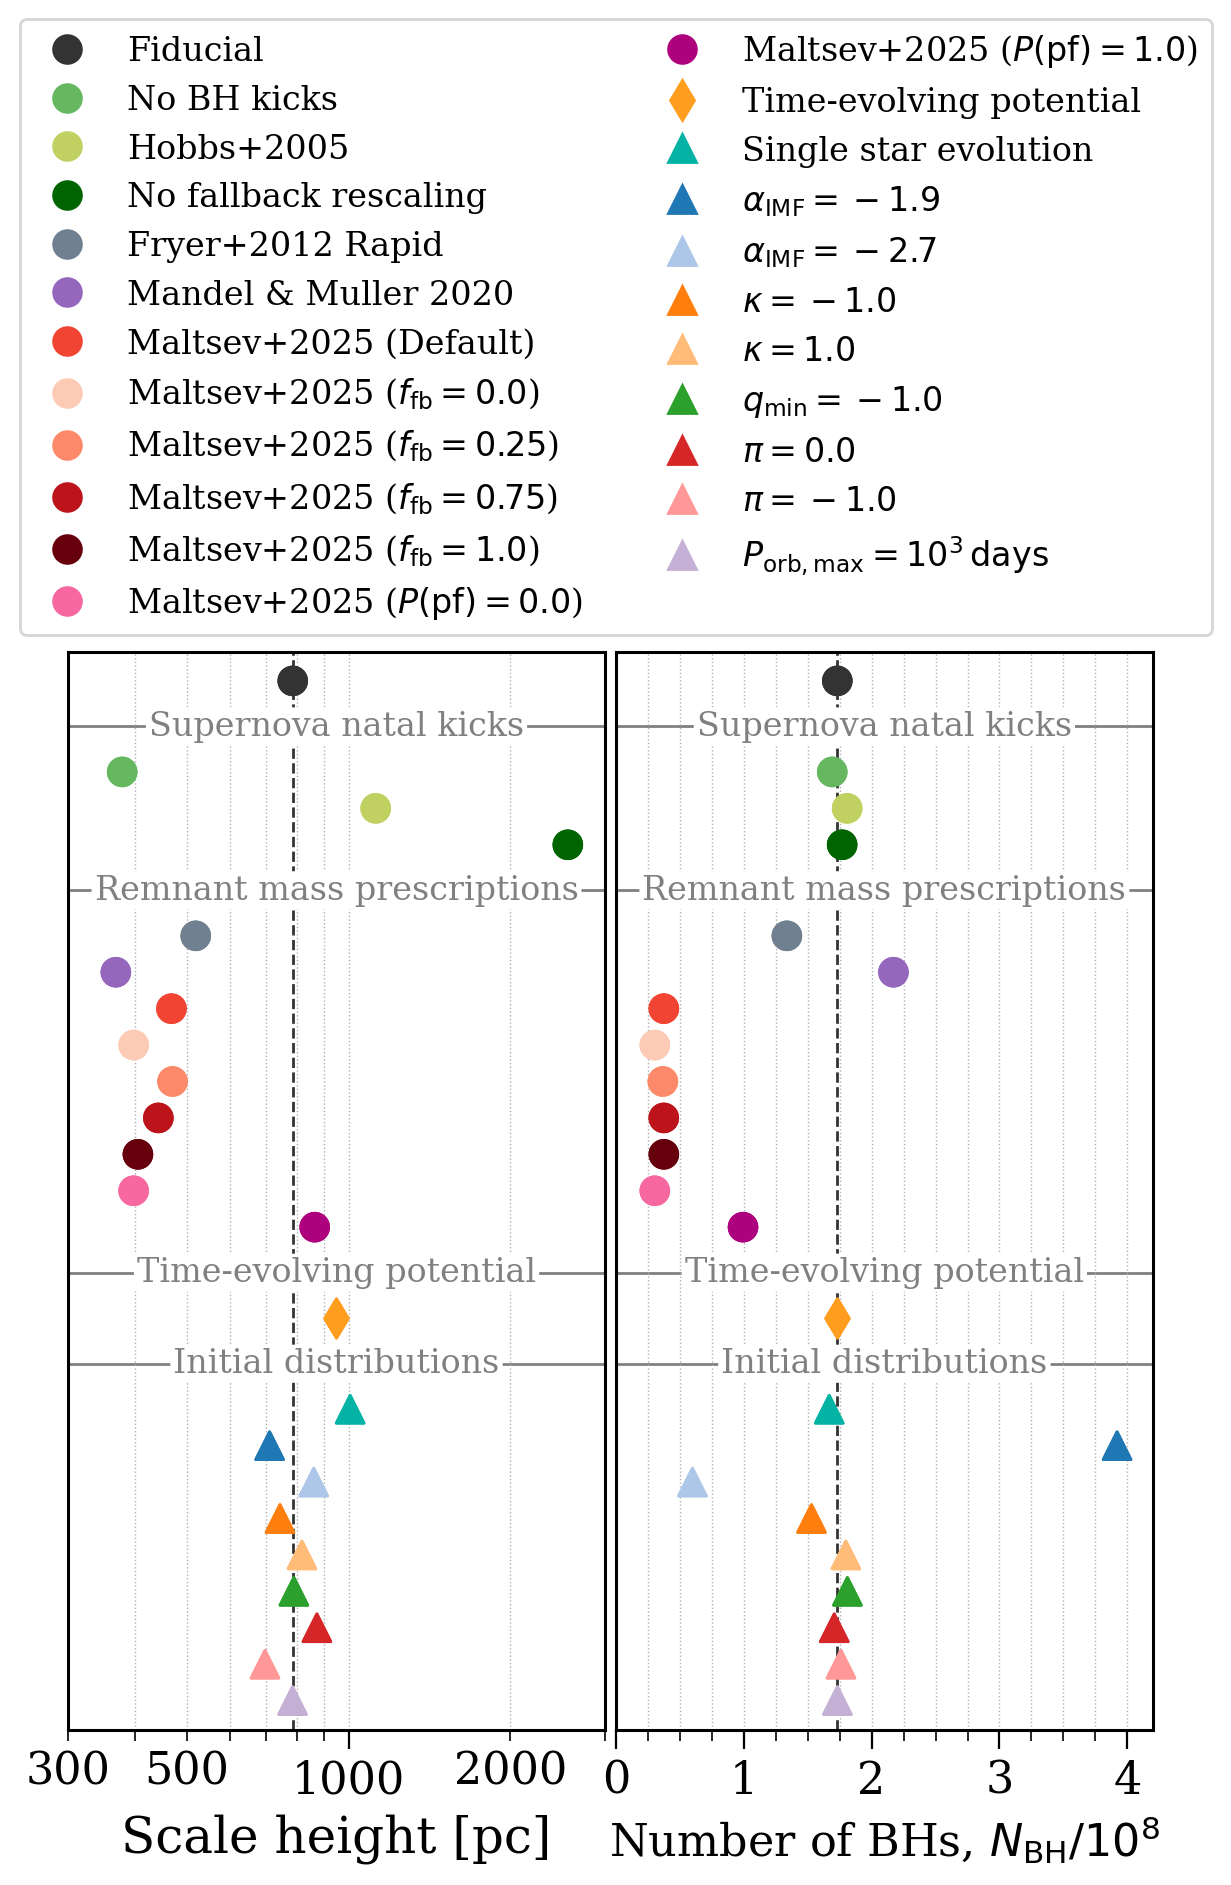

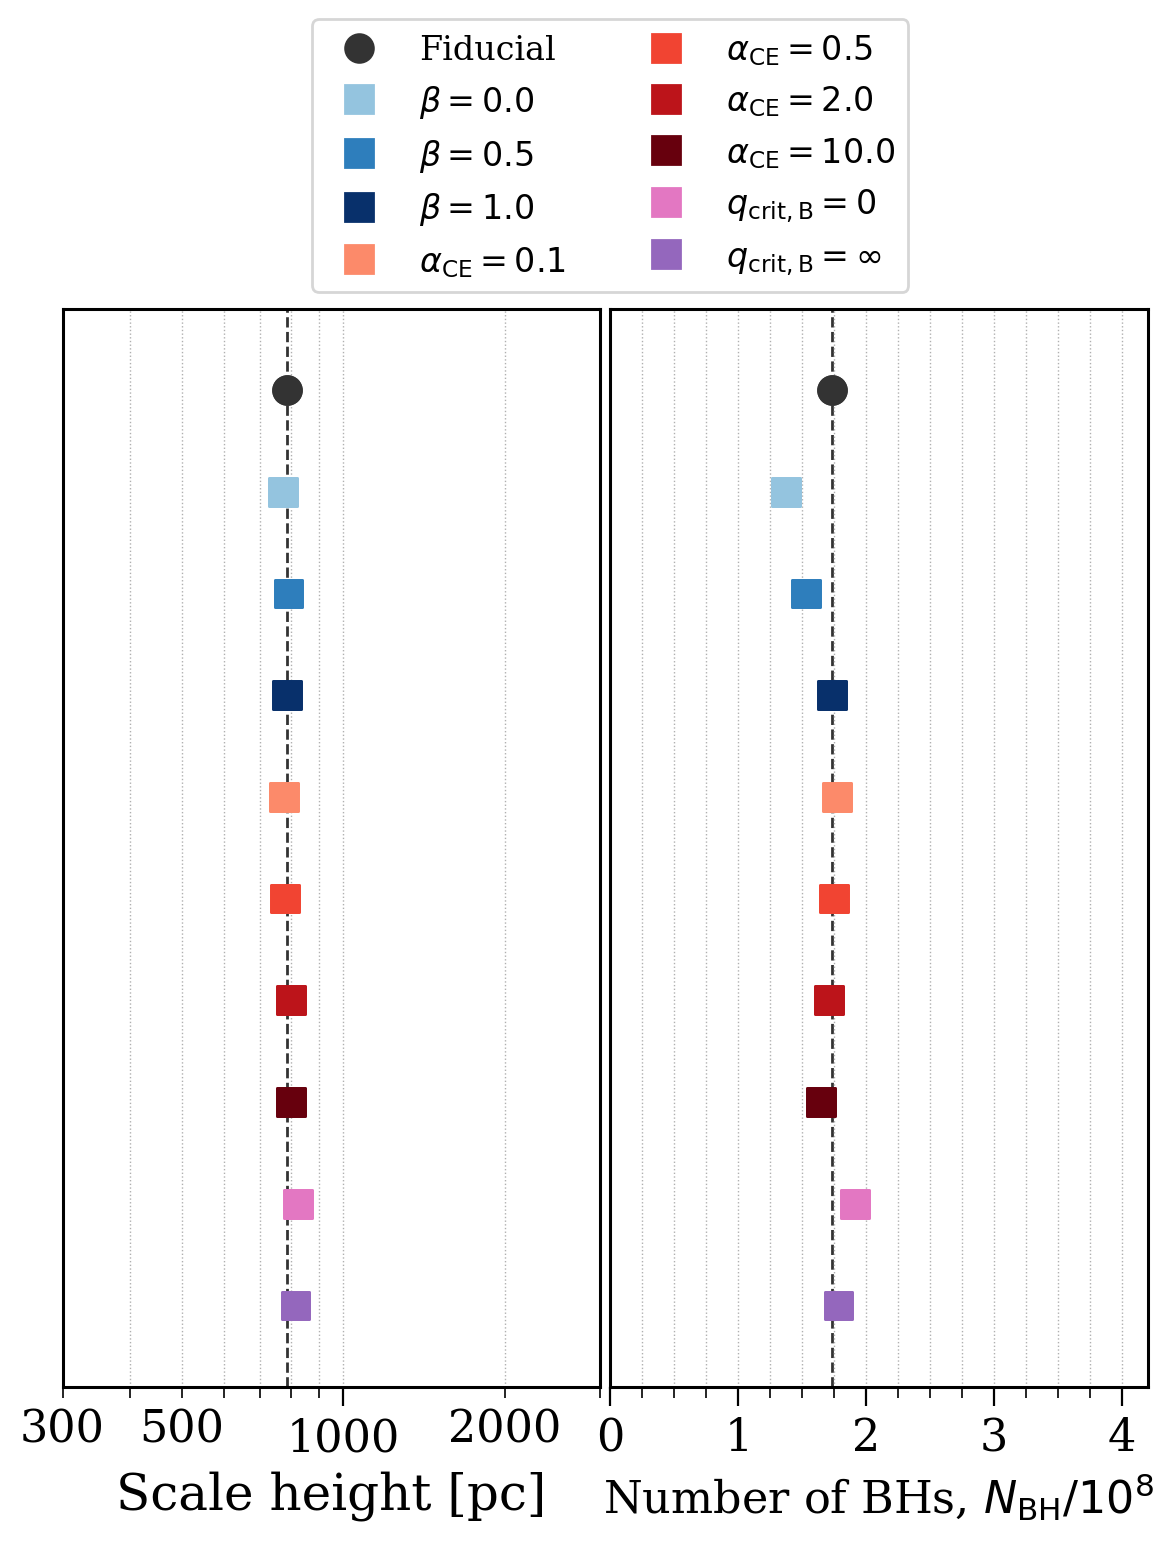

In [84]:
for label_set, groups_to_show, save_file in zip([main_labels, mt_labels], [[g for g in groups if g["title"] != "Fiducial"][:-1], []], ["bh_summary_stats", "bh_summary_stats_mt"]):
    fig, axes = plt.subplots(1, 2, figsize=(7, 7), sharey=True)

    fig.subplots_adjust(wspace=0.02)

    summary_plot(label_set, col="$h_z$ (pc)", fig=fig, ax=axes[0], show=False, legend_kwargs=None, groups_to_show=groups_to_show)
    summary_plot(label_set, col="$N_{\\rm BH} / 10^8$", fig=fig, ax=axes[1], show=False, legend_kwargs={"loc":"lower center", "fontsize":12, "ncol":2, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={"xscale": 'linear'}, groups_to_show=groups_to_show)

    label_these = [300, 500, 1000, 2000]
    formatter = mticker.FuncFormatter(lambda x, pos: f'{int(x)}' if x in label_these else '')
    axes[0].xaxis.set_minor_formatter(formatter)
    axes[0].xaxis.set_major_formatter(formatter)

    axes[0].set_xlabel("Scale height [pc]", fontsize=18)

    axes[1].set_xlabel(r"Number of BHs, $N_{\rm BH} / 10^8$", fontsize=16)
    axes[1].xaxis.set_major_locator(plt.MultipleLocator(1))
    axes[1].xaxis.set_minor_locator(plt.MultipleLocator(.25))

    axes[0].set_xlim(300, 3000)
    axes[1].set_xlim(0, 4.2)

    plt.savefig(f"../plots/{save_file}.pdf", format='pdf', bbox_inches='tight')

    plt.show()

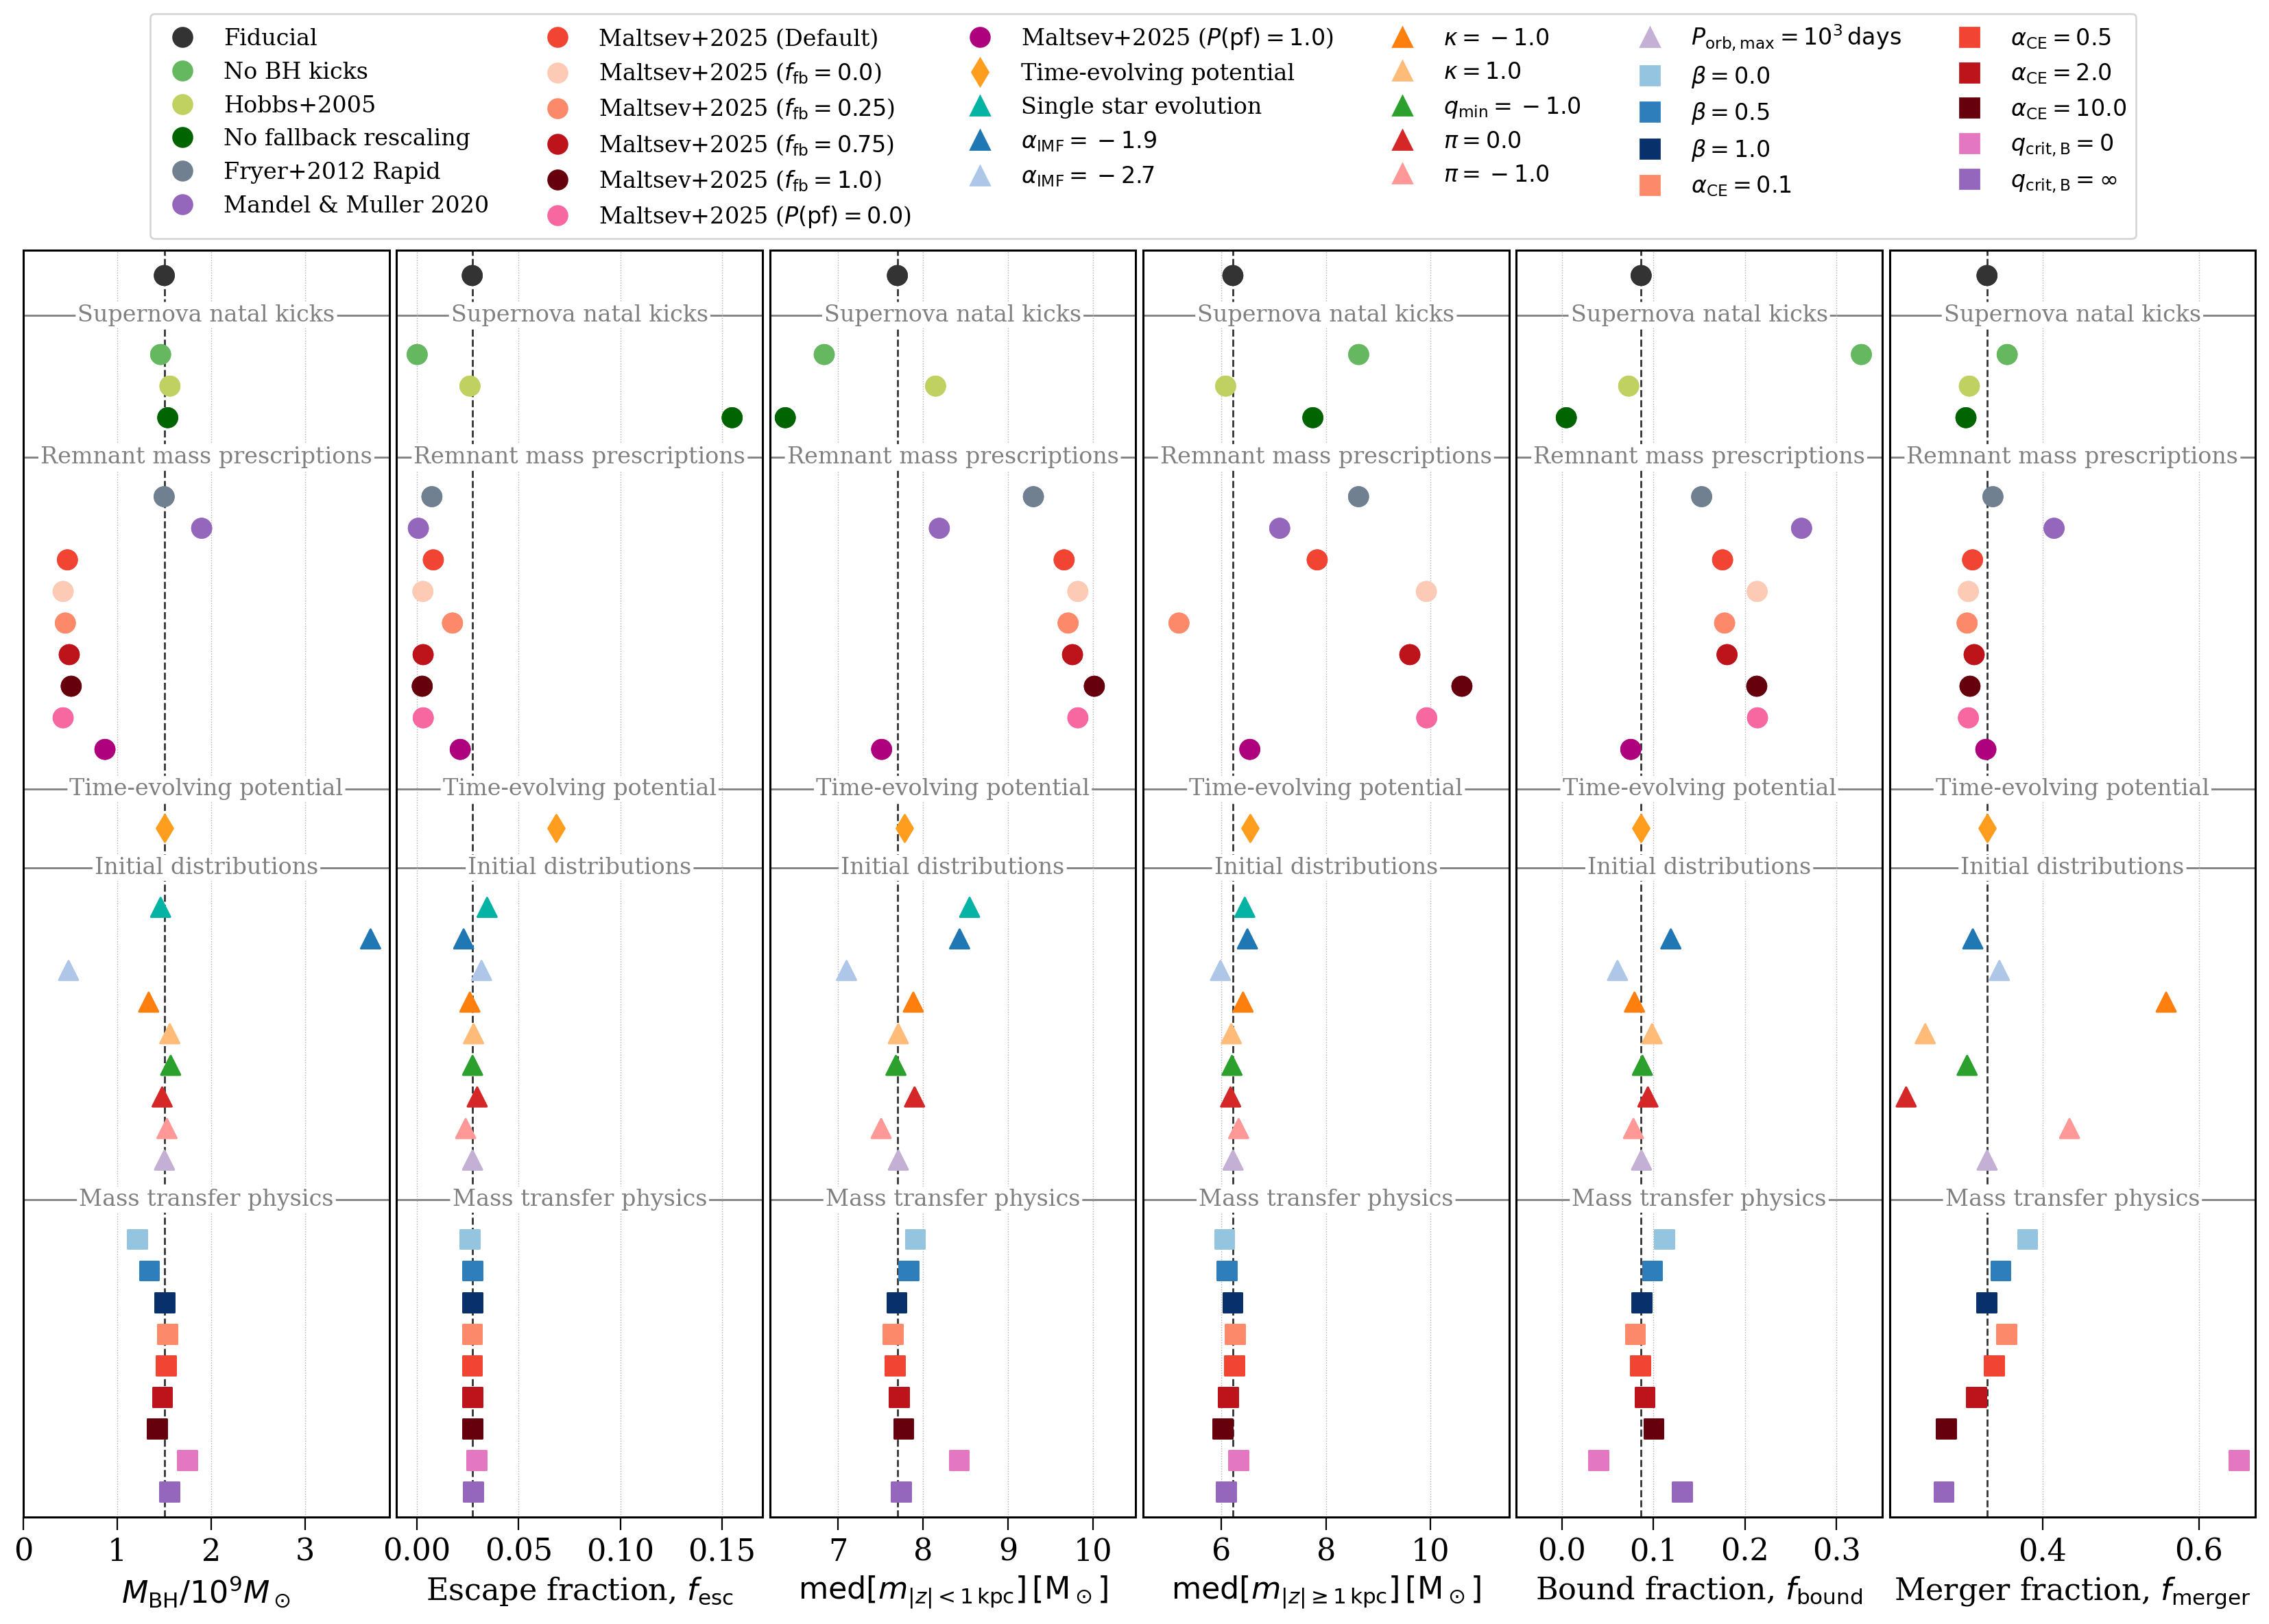

In [27]:
groups_to_show = [g for g in groups if g["title"] != "Fiducial"]

fig, axes = plt.subplots(1, 6, figsize=(21, 12), sharey=True)

fig.subplots_adjust(wspace=0.02)

summary_plot(labels, col=r'$M_{\rm BH} / 10^9 M_\odot$', fig=fig, ax=axes[0], show=False, legend_kwargs=None, ax_kwargs={"xscale": 'linear', "xlim":(0, 3.9)}, groups_to_show=groups_to_show)
axes[0].set_xlabel(r'$M_{\rm BH} / 10^9 M_\odot$', fontsize=16)

summary_plot(labels, col=r'$f_{\rm esc}$', fig=fig, ax=axes[1], show=False, legend_kwargs=None,
            #  ax_kwargs={"xscale": 'log', "xlim":(8e-5, 2e-1)},
                ax_kwargs={"xscale": 'linear', "xlim":(-0.01, 0.17)},
                groups_to_show=groups_to_show)
axes[1].set_xlabel(r"Escape fraction, $f_{\rm esc}$", fontsize=16)

summary_plot(labels, col=r'$\median{m_{|z| < 1 \, {\rm kpc}}}$', fig=fig, ax=axes[2], show=False, legend_kwargs=None, ax_kwargs={"xscale": 'linear', "xlim":(6.2, 10.5)}, groups_to_show=groups_to_show)
axes[2].set_xlabel(r'$\text{med}[m_{|z| < 1 \, {\rm kpc}}] \, [\rm M_\odot]$', fontsize=16)
axes[2].xaxis.set_major_locator(plt.MultipleLocator(1))

summary_plot(labels, col=r'$\median{m_{|z| \geq 1 \, {\rm kpc}}}$', fig=fig, ax=axes[3], show=False,
                legend_kwargs={"loc":"lower center", "fontsize":12, "ncol":6, "bbox_to_anchor":(0.0, 1.0)}, ax_kwargs={"xscale": 'linear', "xlim":(4.5, 11.5)}, groups_to_show=groups_to_show)
axes[3].set_xlabel(r'$\text{med}[m_{|z| \geq 1 \, {\rm kpc}}] \, [\rm M_\odot]$', fontsize=16)

summary_plot(labels, col=r'$f_{\rm bound}$', fig=fig, ax=axes[4], show=False, legend_kwargs=None, ax_kwargs={"xscale": 'linear', "xlim":(-0.05, 0.35)}, groups_to_show=groups_to_show)
axes[4].set_xlabel(r"Bound fraction, $f_{\rm bound}$", fontsize=16)

summary_plot(labels, col=r'$f_{\rm merger}$', fig=fig, ax=axes[5], show=False, legend_kwargs=None, ax_kwargs={"xscale": 'linear'}, groups_to_show=groups_to_show)
axes[5].set_xlabel(r"Merger fraction, $f_{\rm merger}$", fontsize=16)

plt.savefig(f"../plots/bh_summary_other_cols.pdf", format='pdf', bbox_inches='tight')

plt.show()

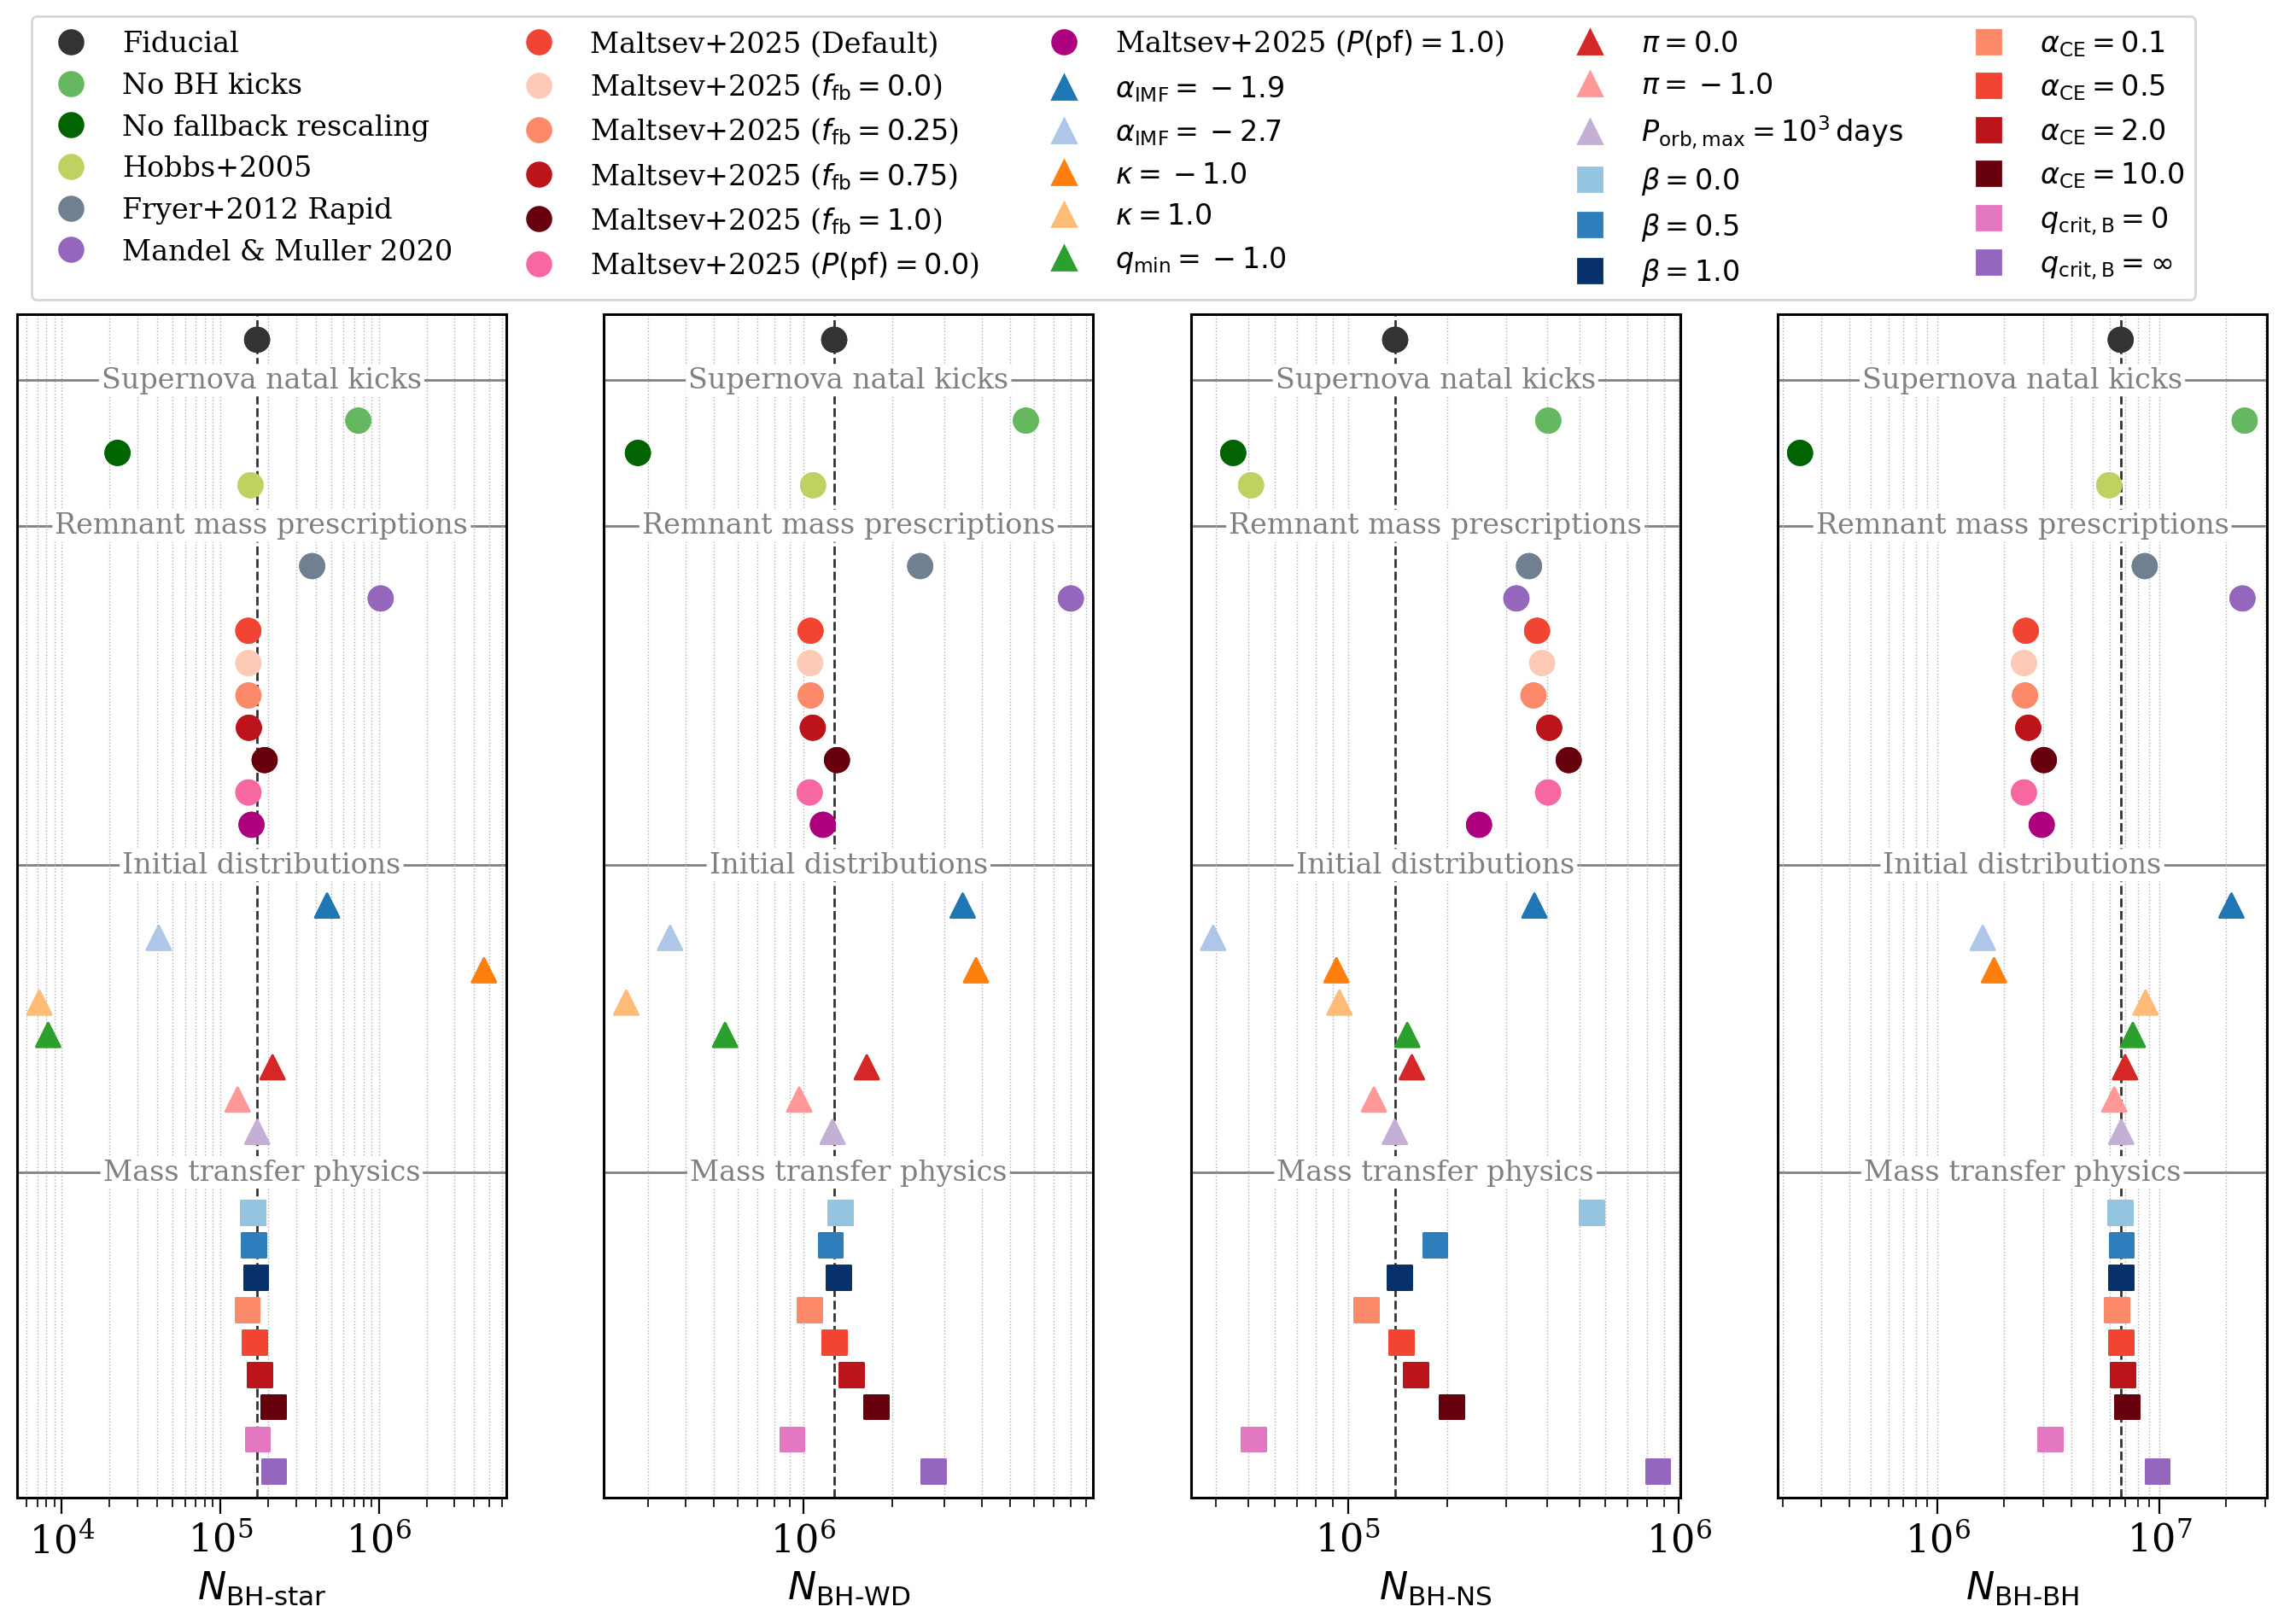

In [41]:
reload(constants)

fig, axes = plt.subplots(1, 4, figsize=(17, 9), sharey=True)

# main labels without the 2nd entry
main_labels_no_singles = [label for label in main_labels if (label != r"$f_{\rm bin} = 0.0$" and label != "Time-evolving potential")]
main_labels_no_singles += [label for label in mt_labels if label != r"$f_{\rm bin} = 1.0$"]
labels_inds = np.array([labels.index(label) for label in main_labels_no_singles])

for col, ax, norm in zip(
    [r"$N_{\rm BH\text{-}star} / 10^4$", r"$N_{\rm BH\text{-}WD} / 10^5$", r"$N_{\rm BH\text{-}NS} / 10^5$", r"$N_{\rm BH\text{-}BH} / 10^6$"],
    axes,
    [1e4, 1e5, 1e5, 1e6]
):

    summary_plot(main_labels_no_singles, col=col, fig=fig, ax=ax, show=False,
                 legend_kwargs={"loc":"lower left", "fontsize":12, "ncol":5, "bbox_to_anchor":(0.0, 1.0)} if ax == axes[0] else None,
                 norm=norm, groups_to_show=[g for g in groups if g["title"] != "Time-evolving potential" and g["title"] != "Fiducial"])

    ax.set_xlabel(col.split("/")[0] + "$", fontsize=16)


plt.savefig("../plots/bh_summary_stats_bound.pdf", format='pdf', bbox_inches='tight')

plt.show()

$f_{\rm bin} = 1.0$ 1778


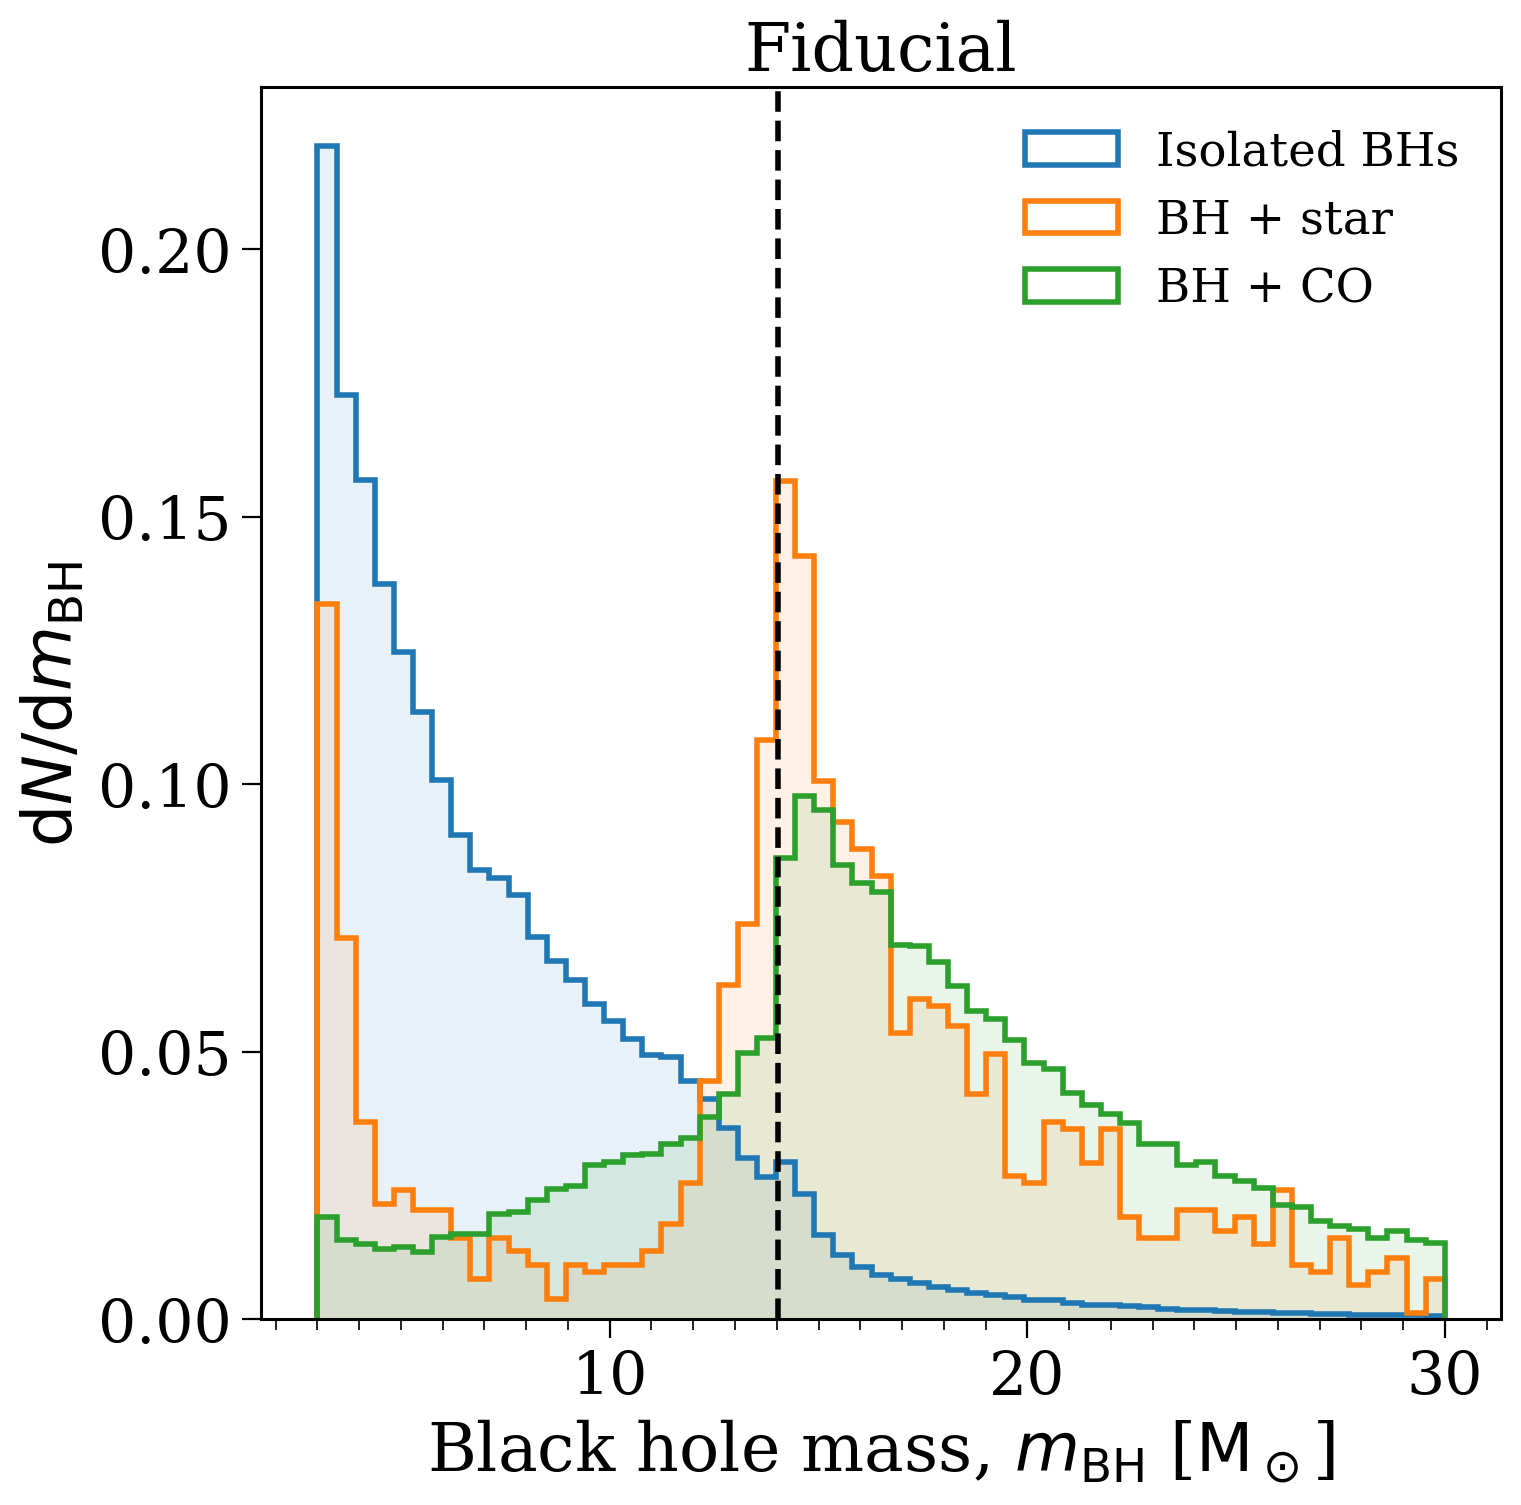

No BH kicks 7737


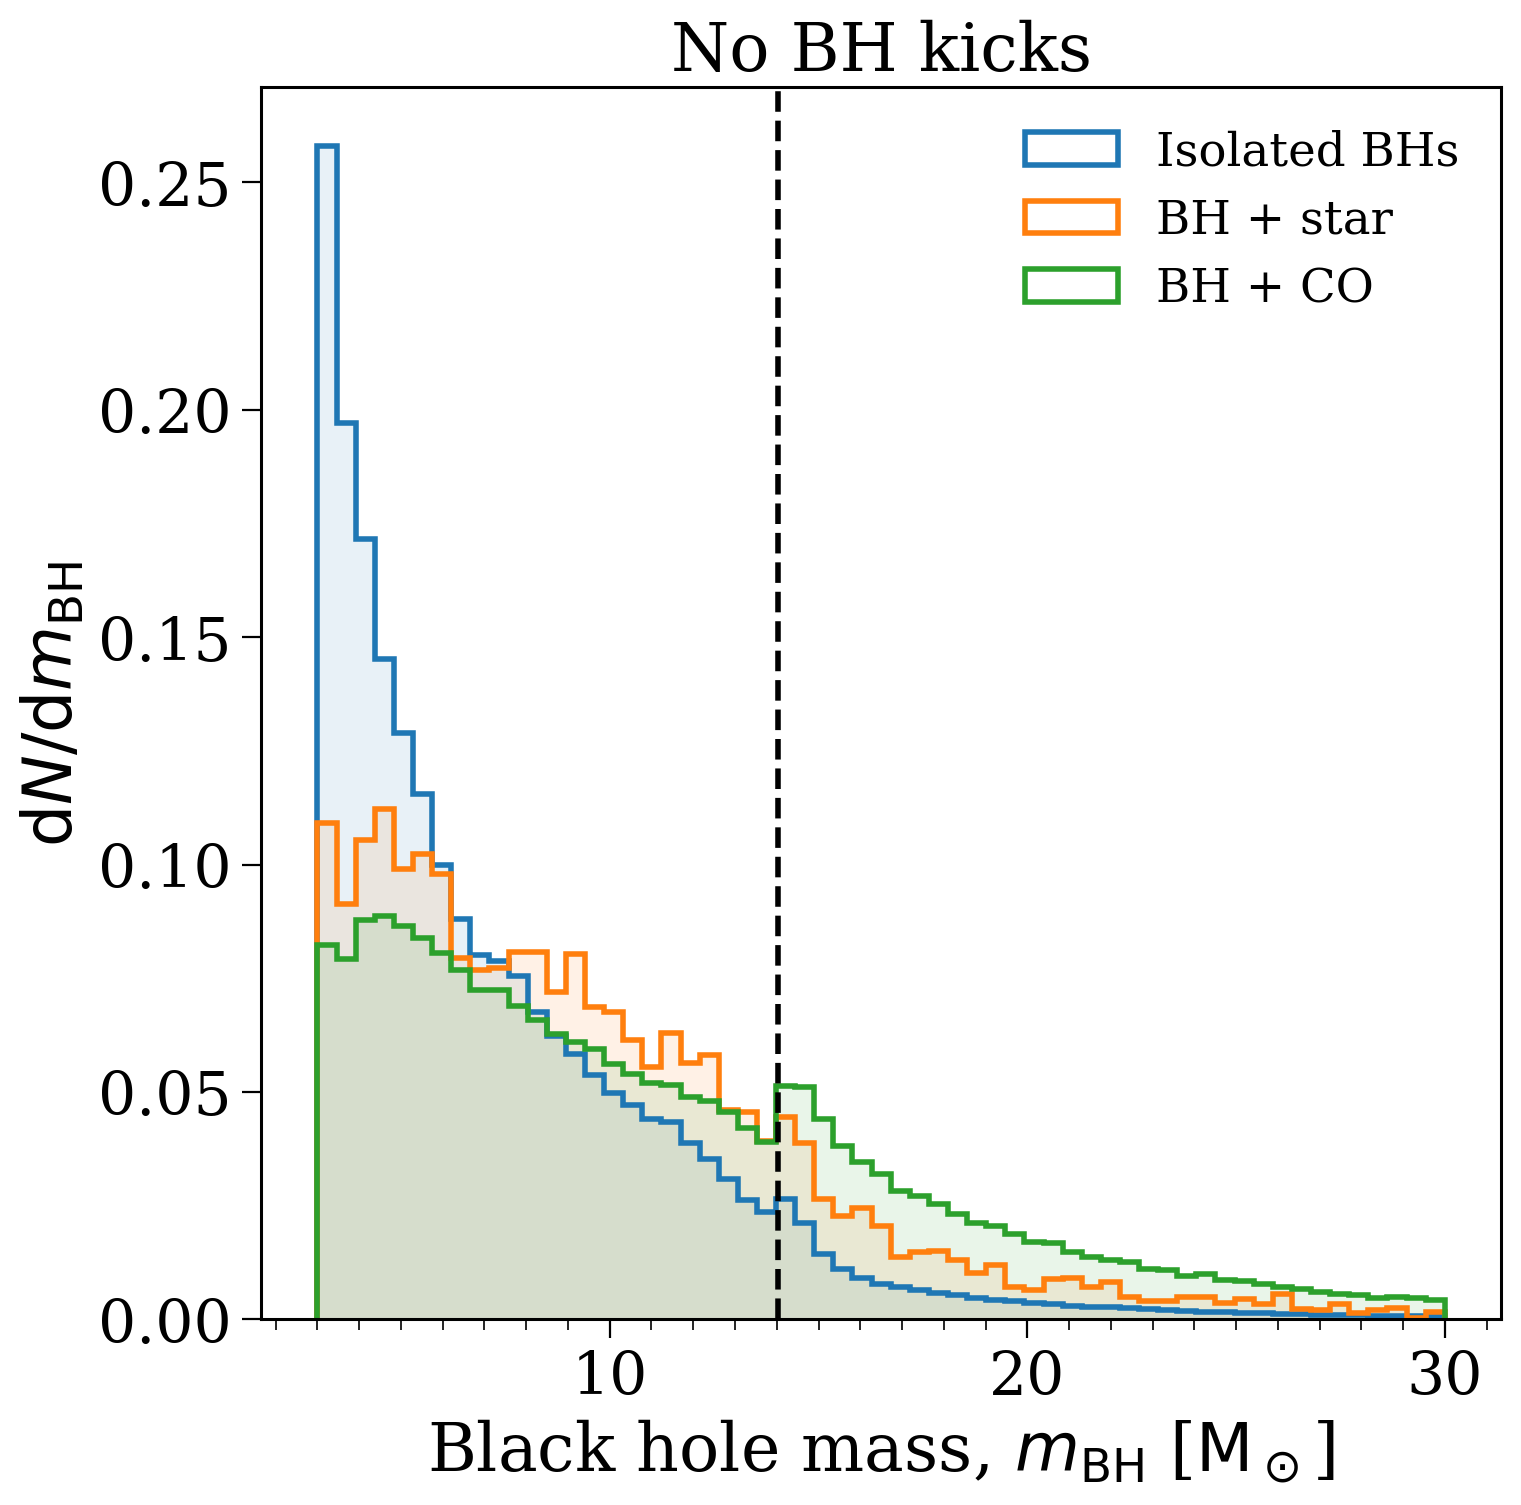

No fallback rescaling 234


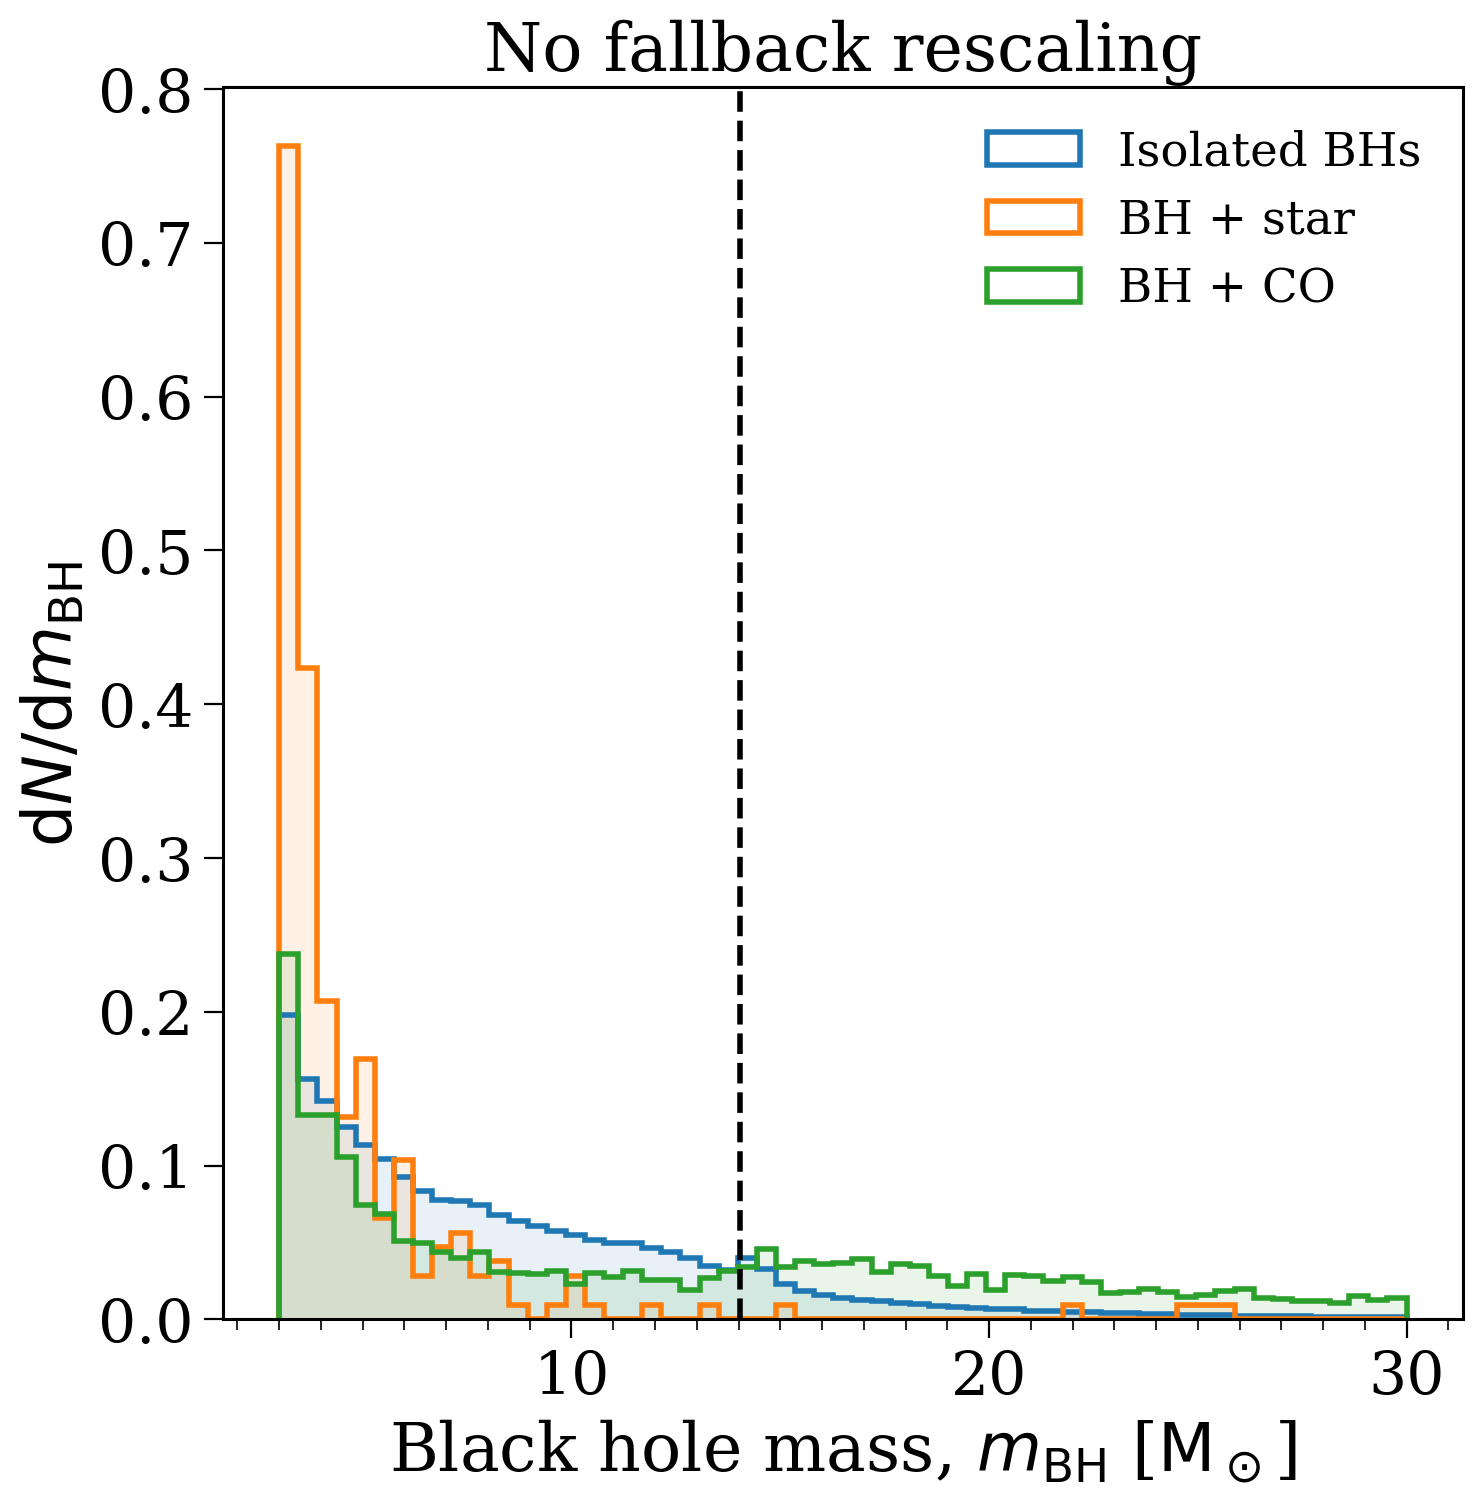

Hobbs+2005 1617


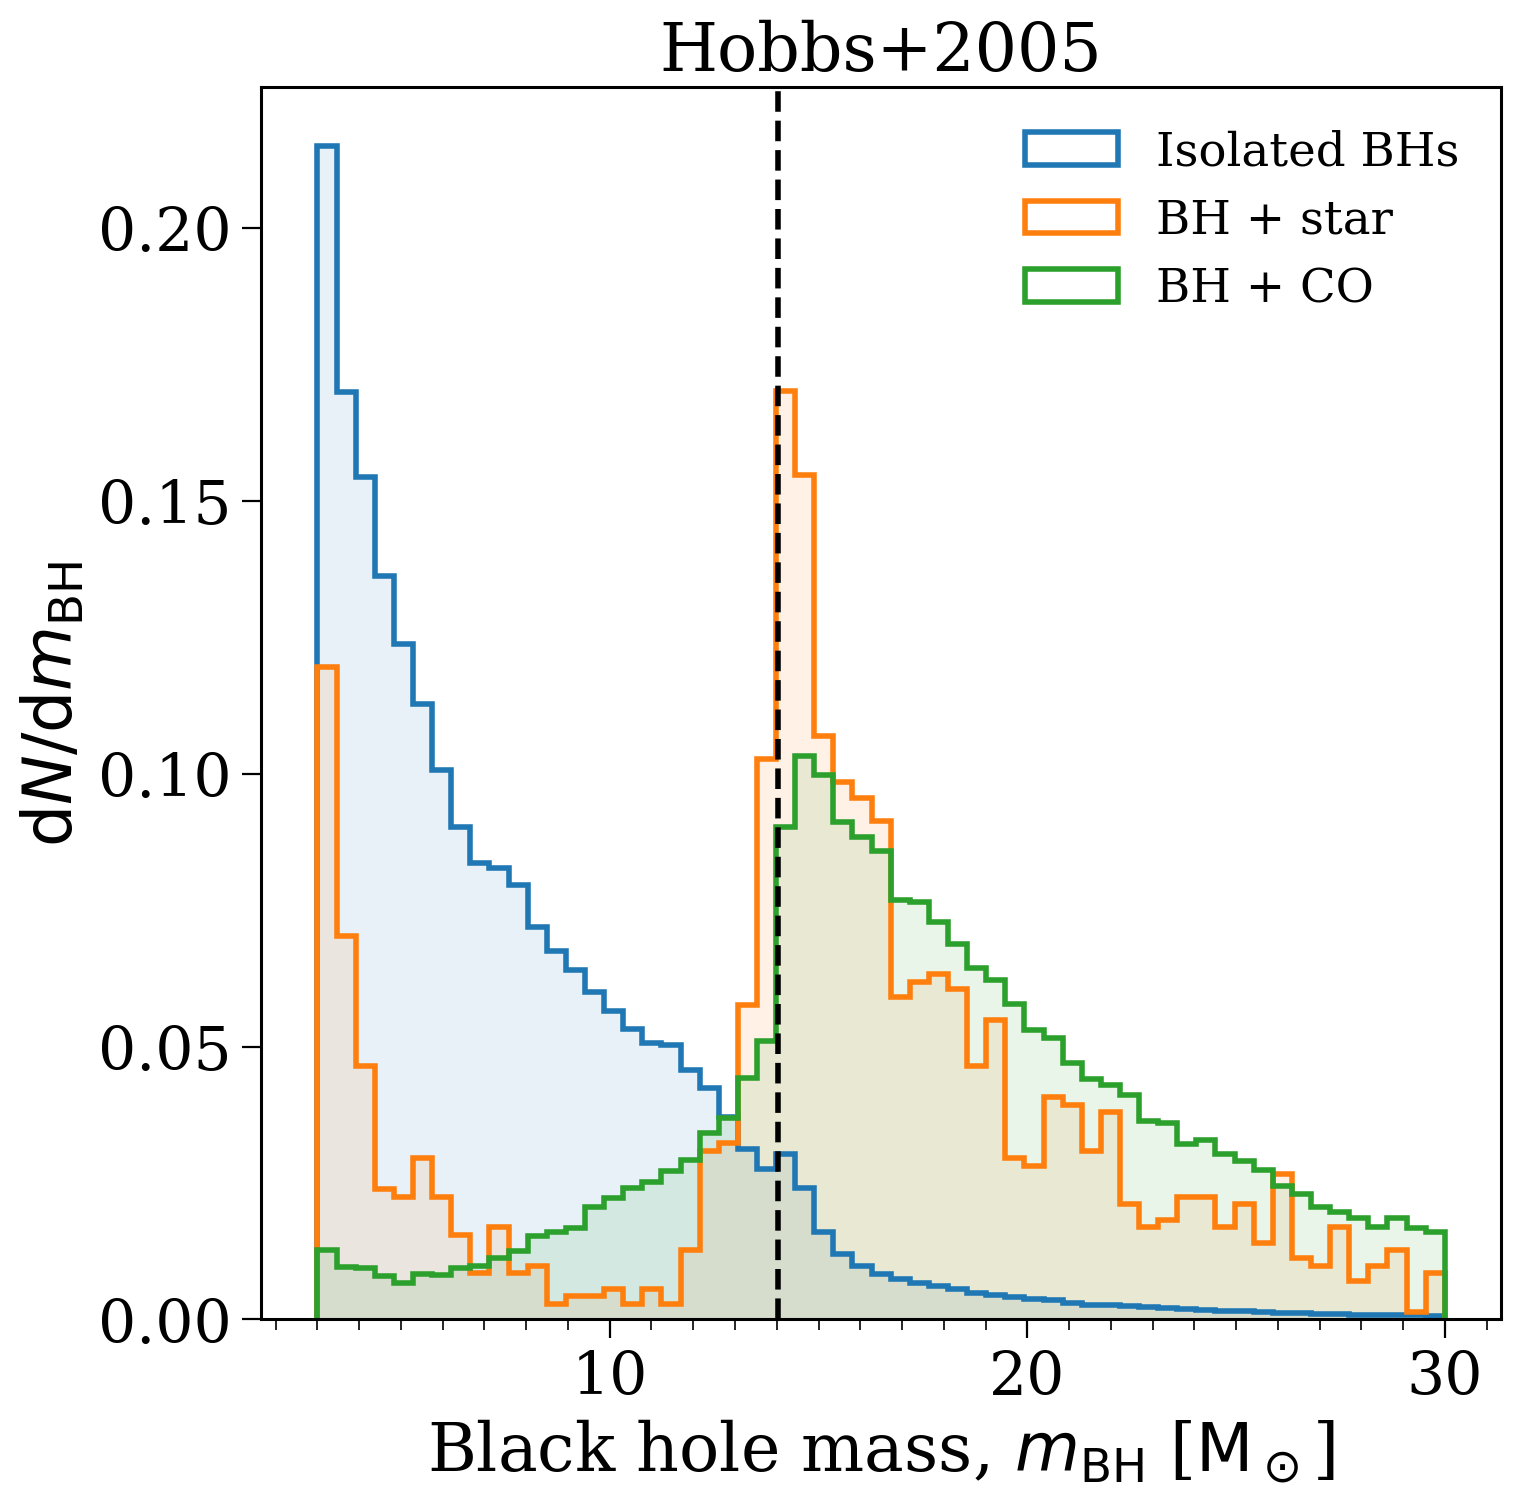

Fryer+2012 Rapid 3958


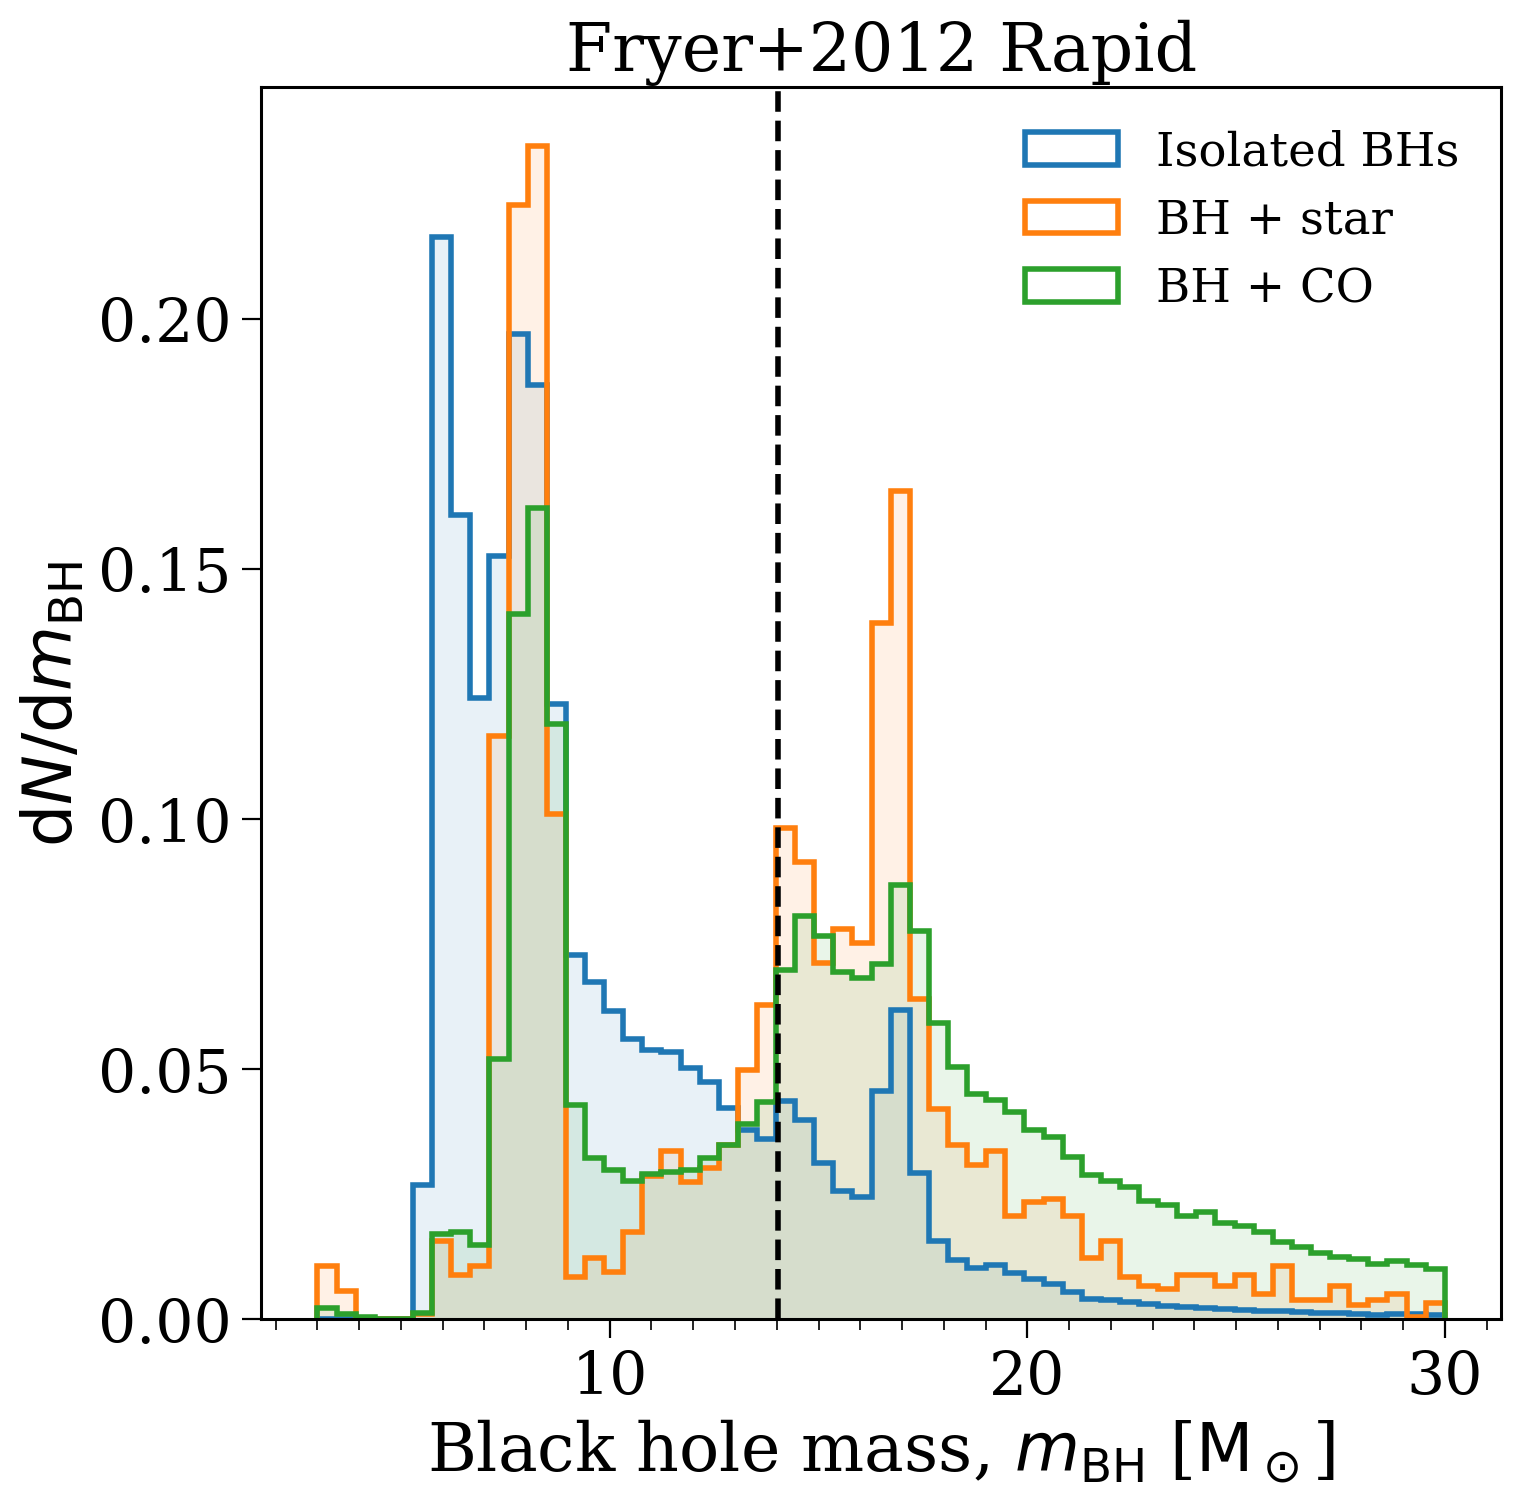

Mandel\&Muller2020 10703


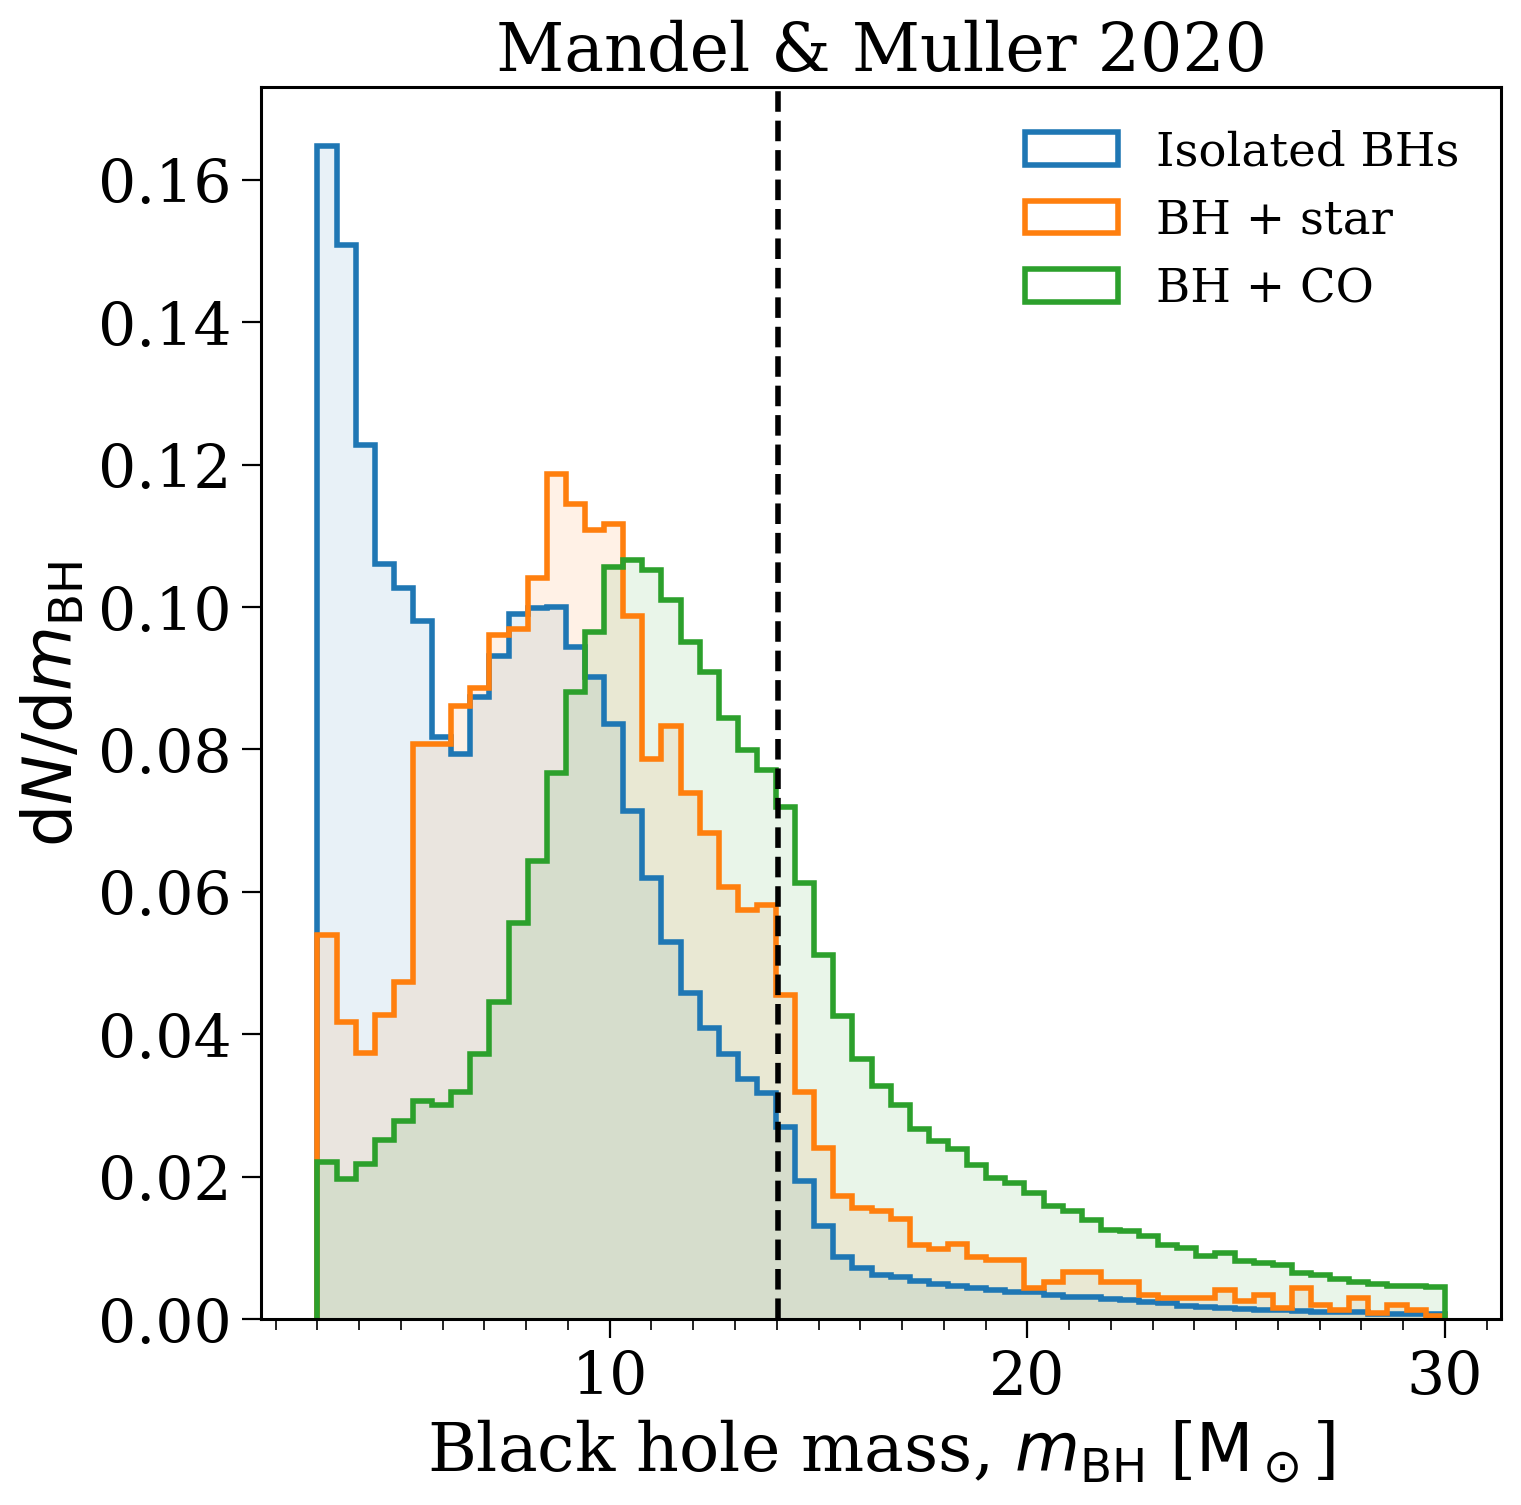

Maltsev+2025 1565


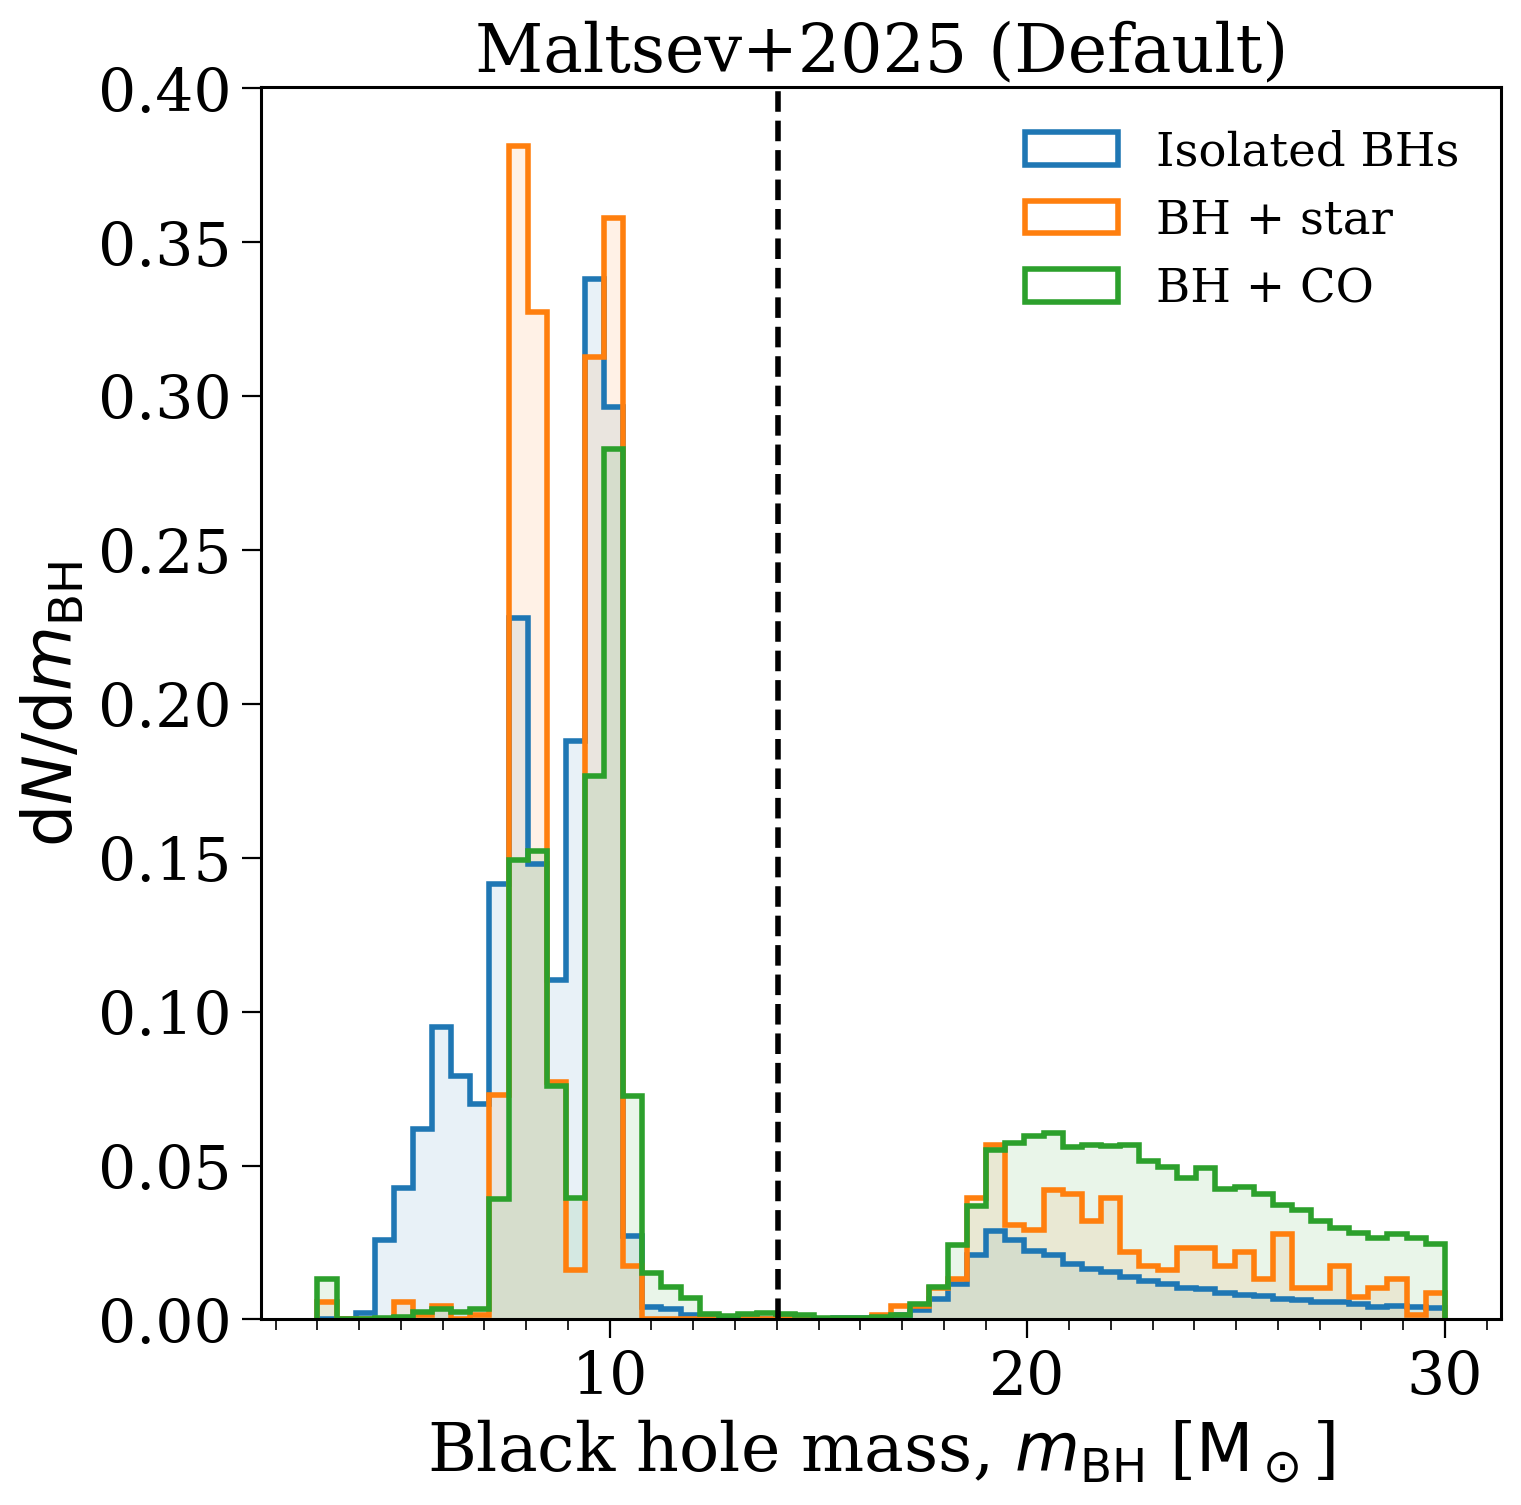

$f_{\rm fb} = 0.0$ 1568


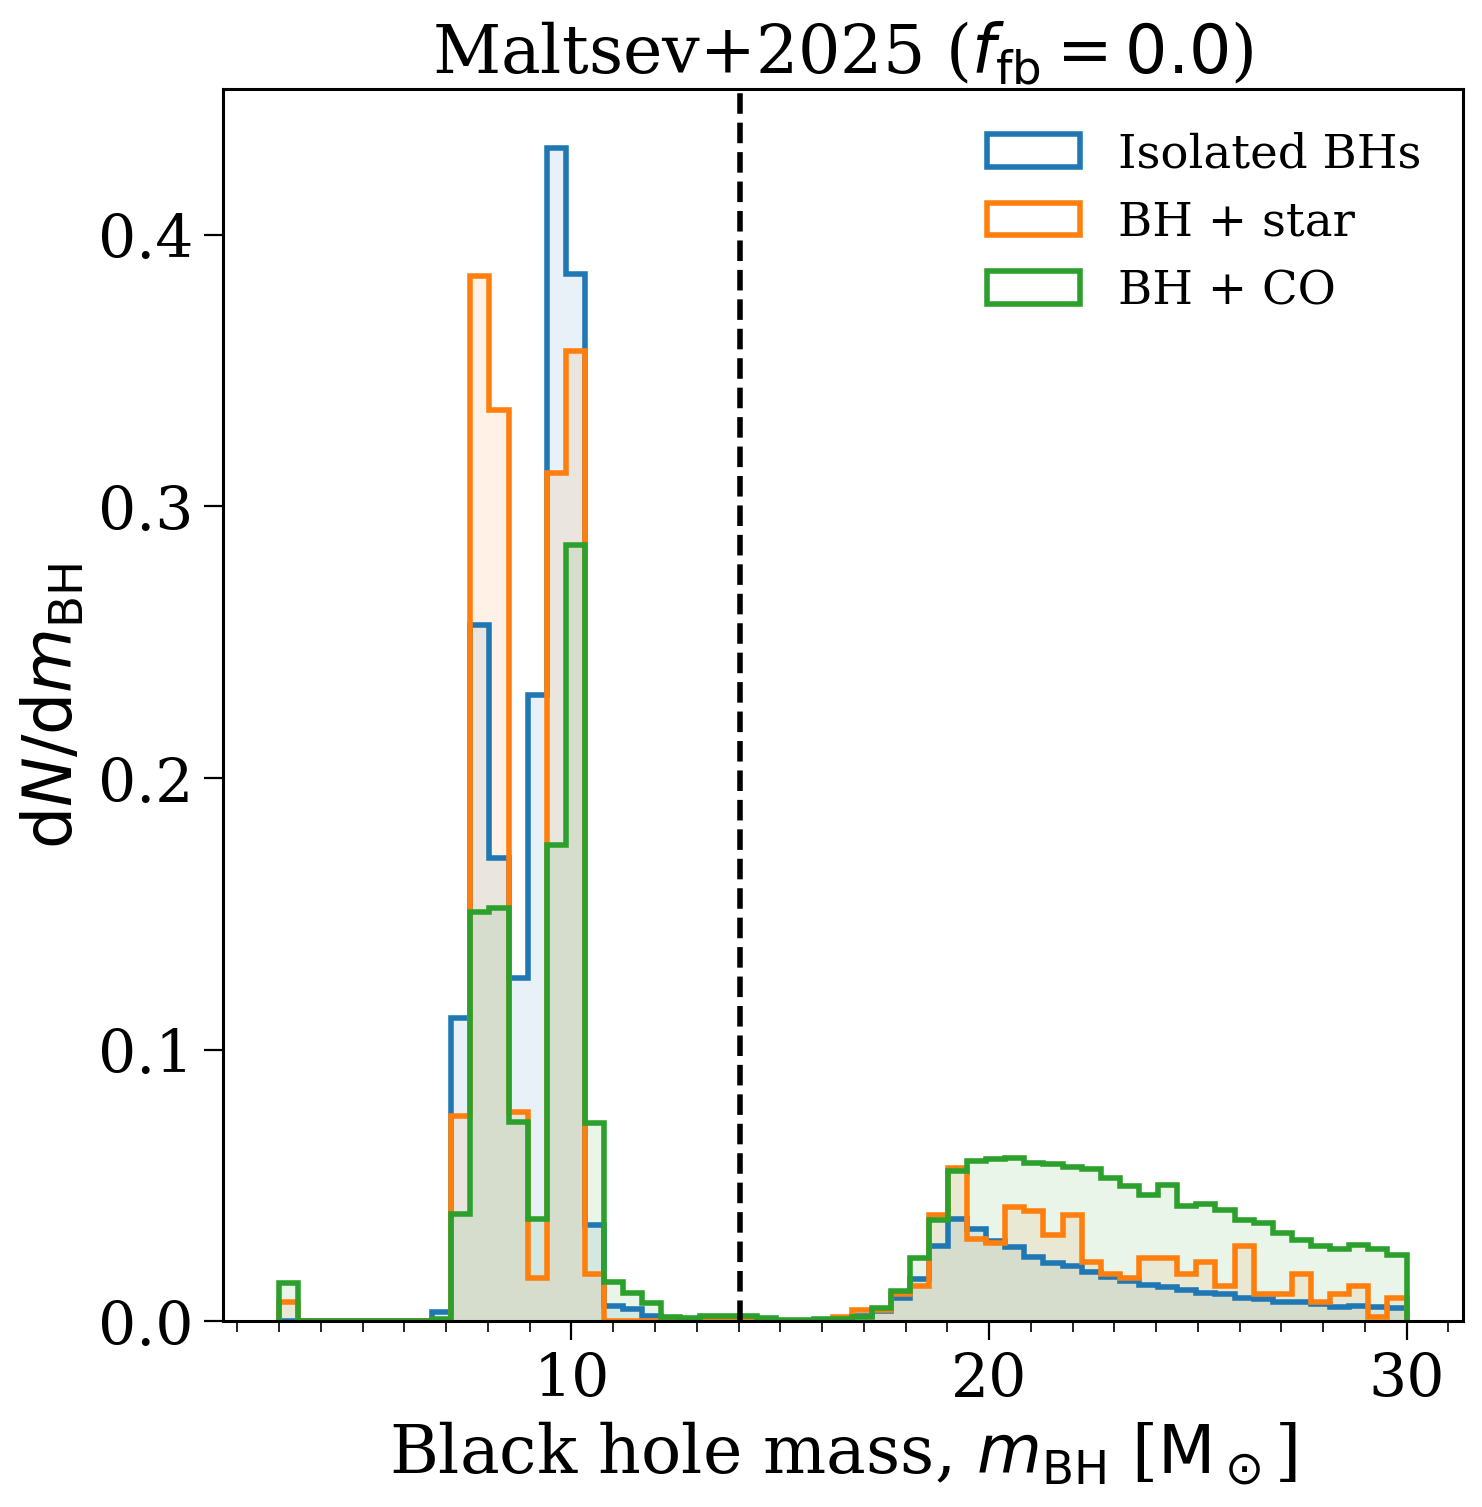

$f_{\rm fb} = 0.25$ 1568


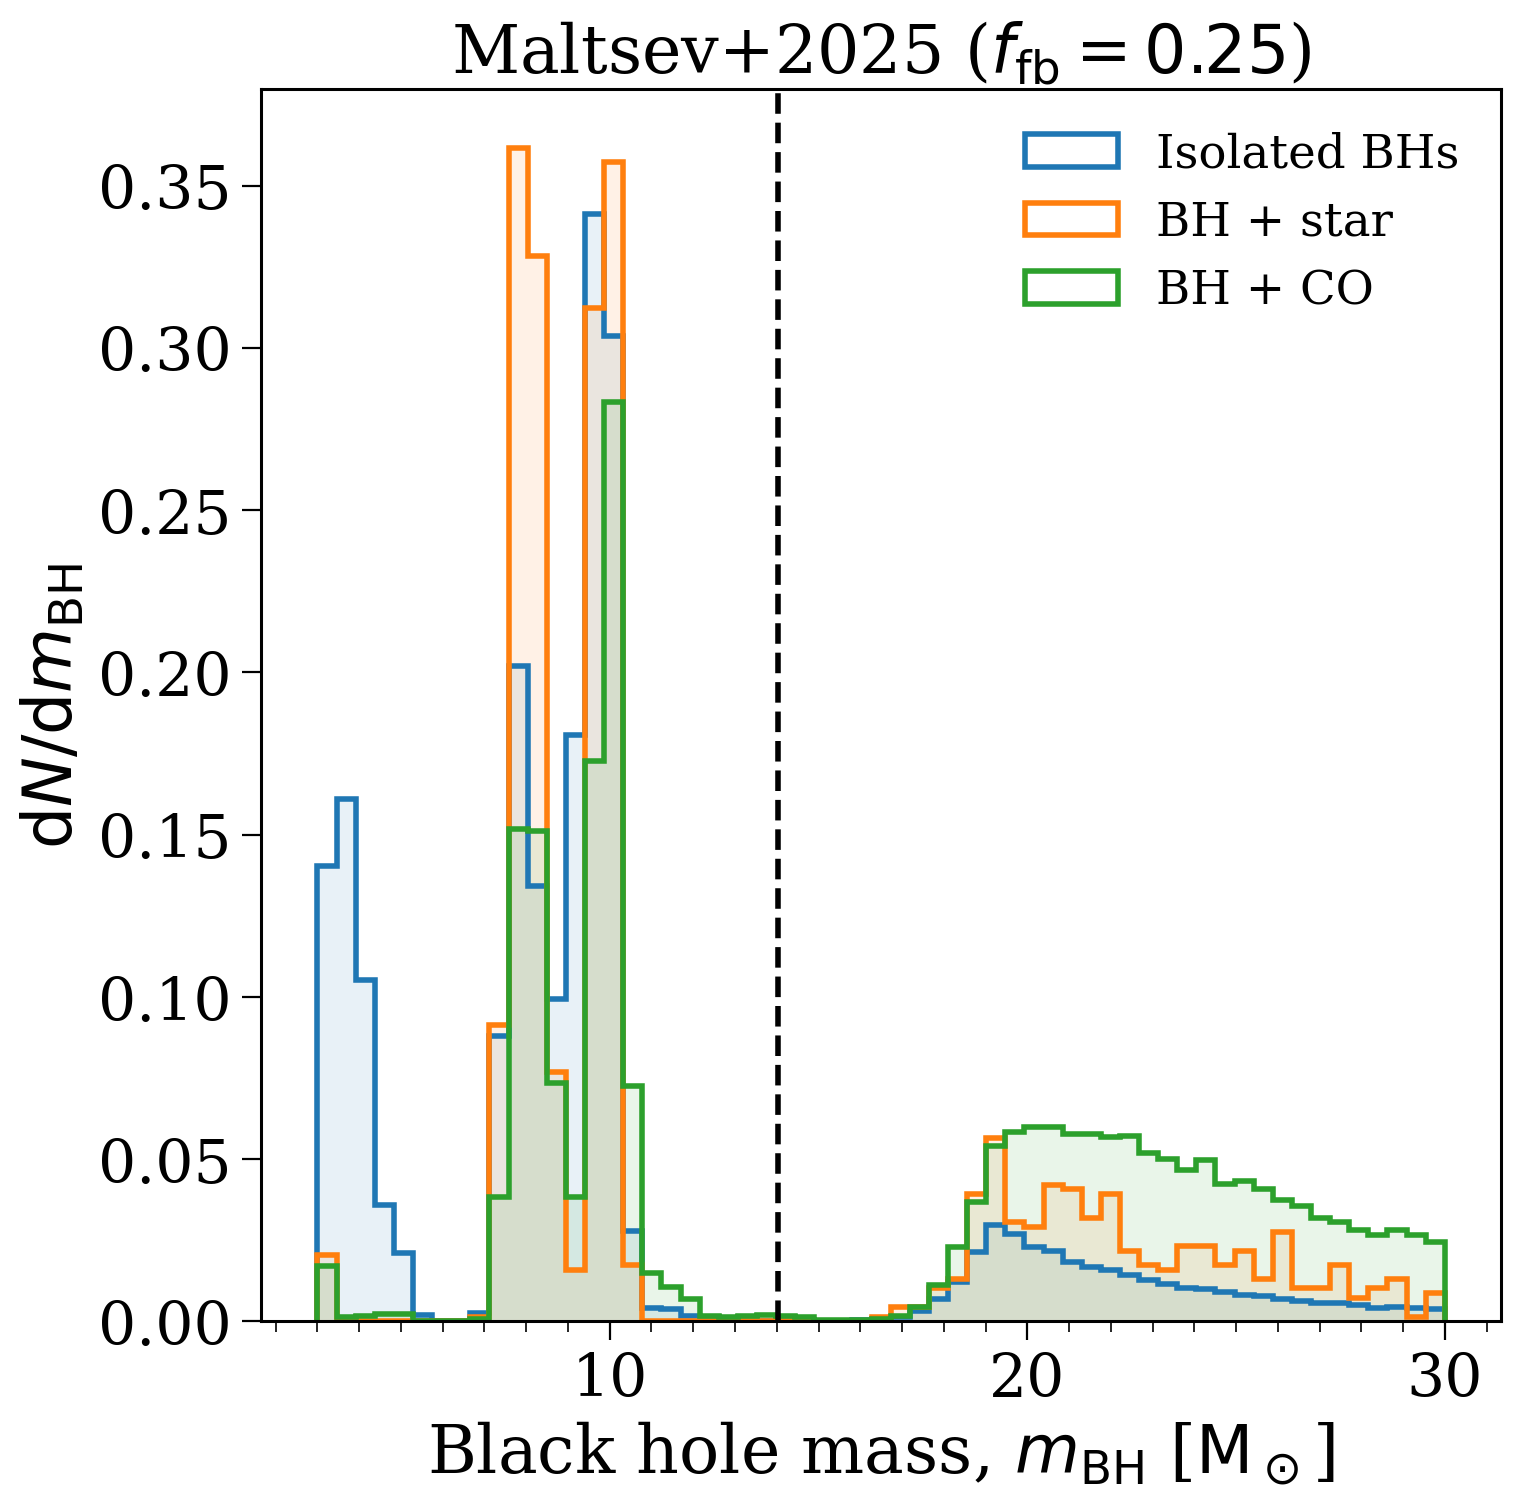

$f_{\rm fb} = 0.75$ 1578


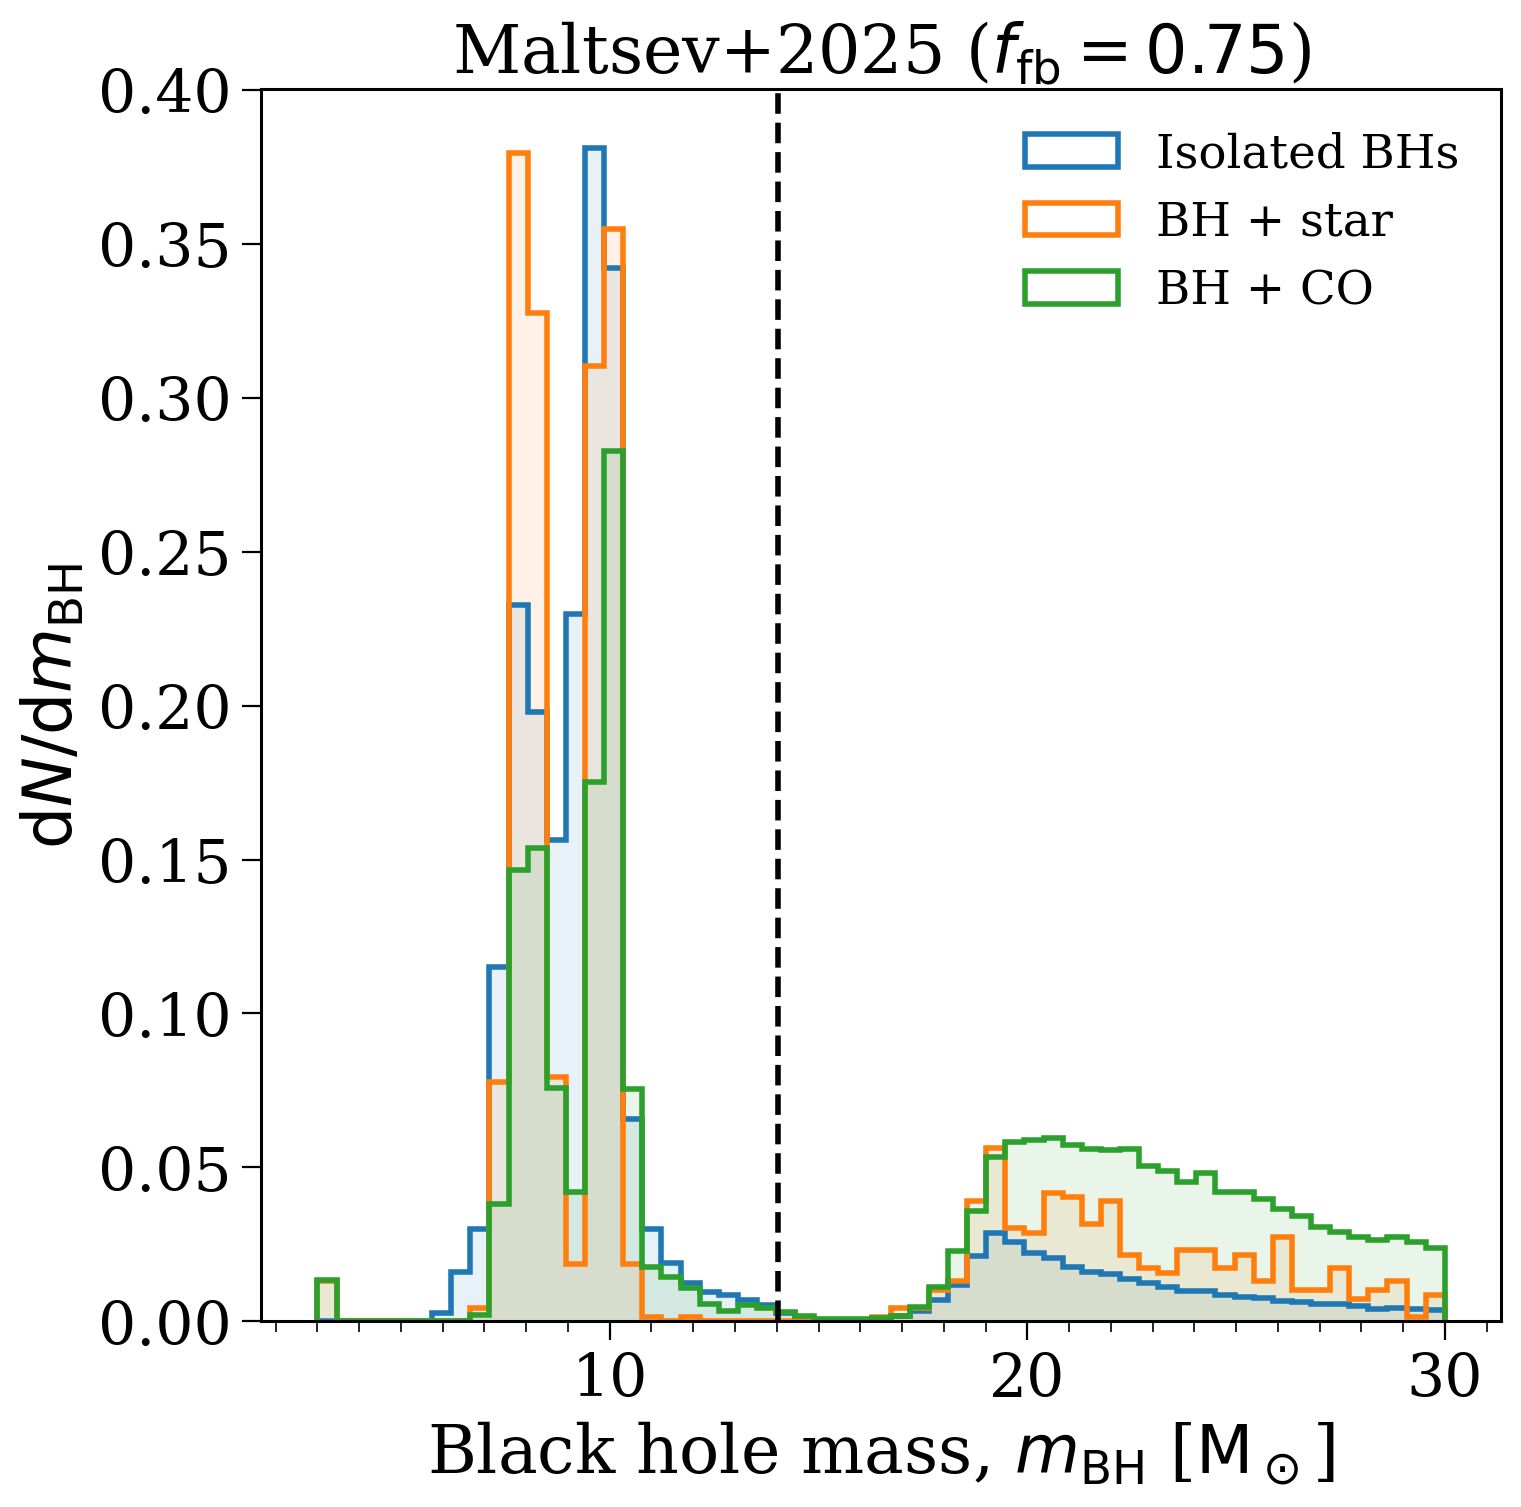

$f_{\rm fb} = 1.0$ 1984


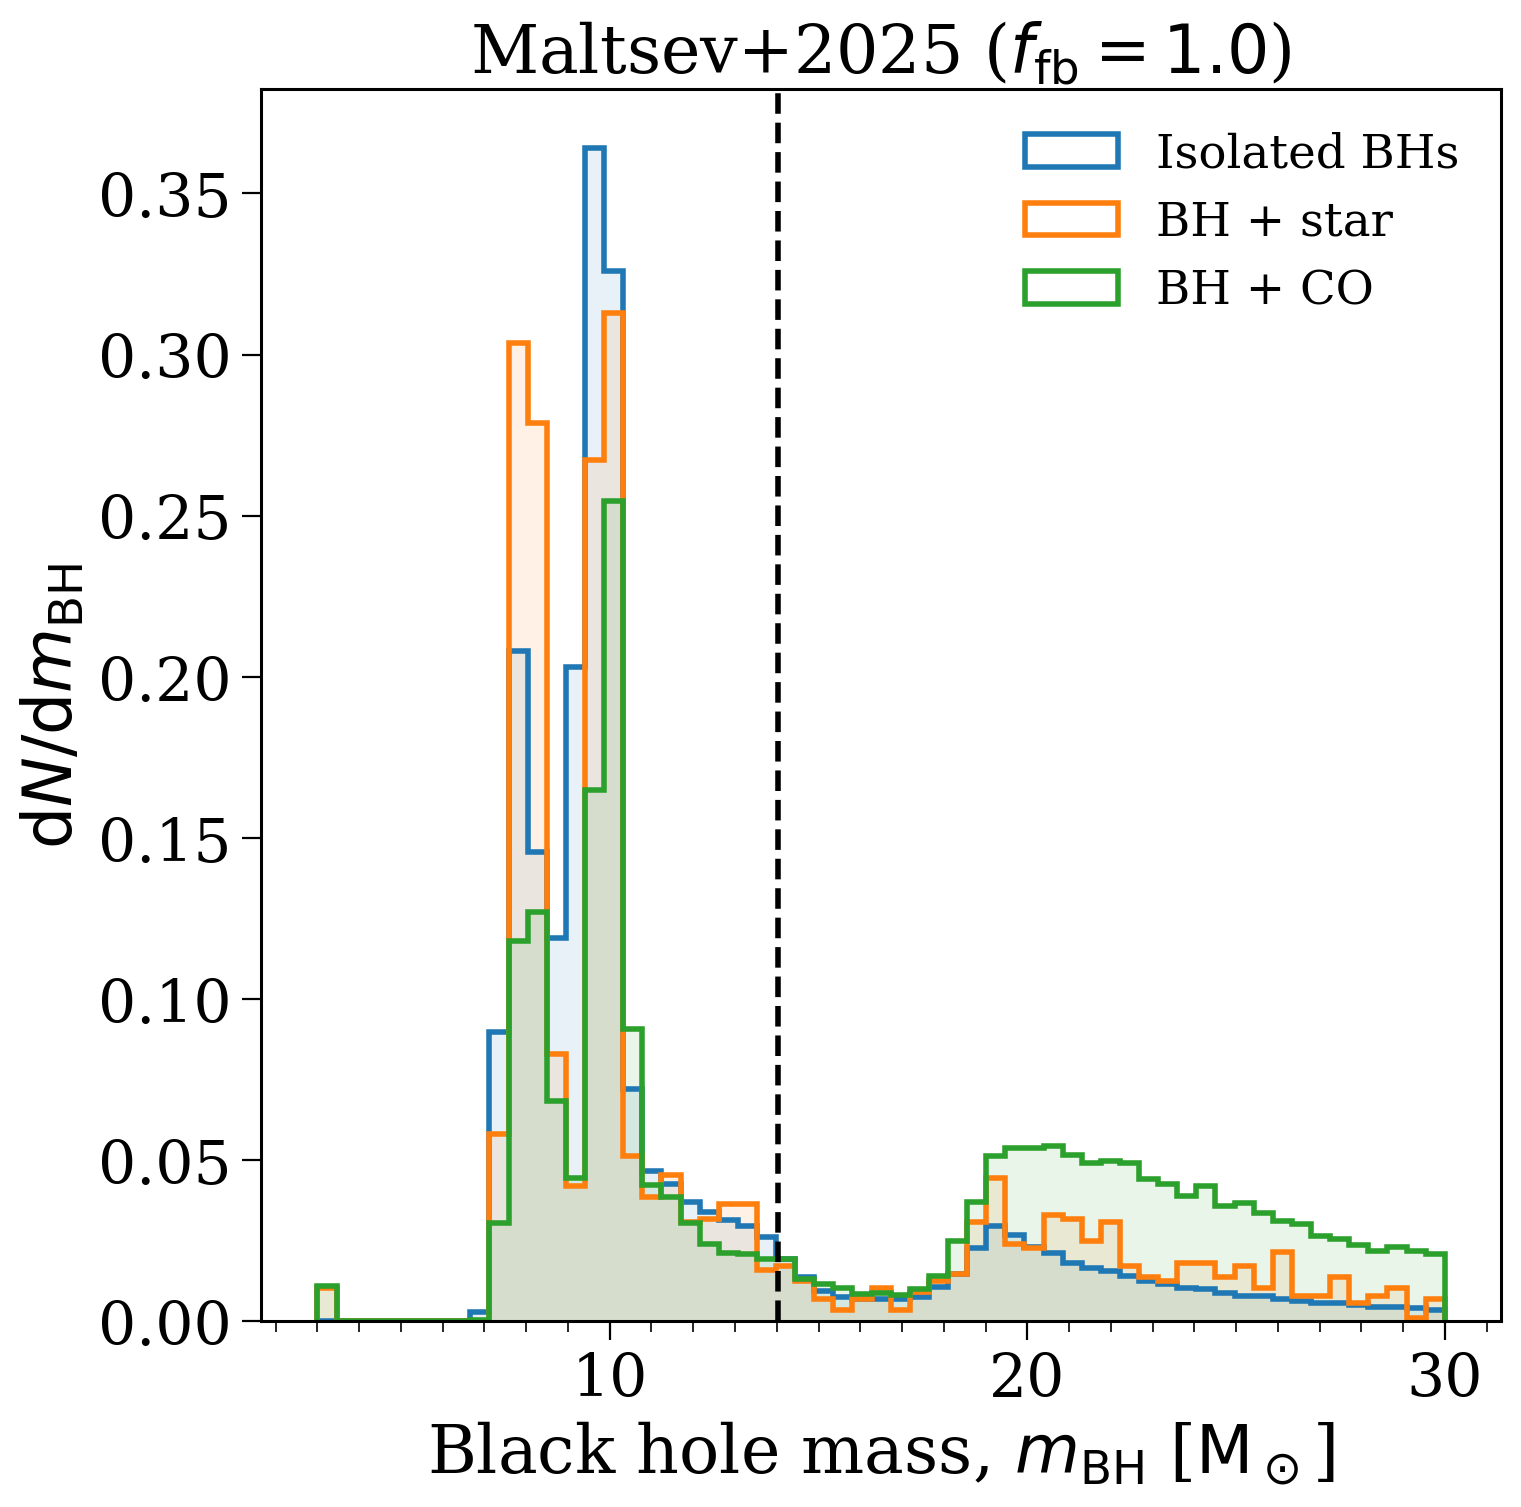

$P({\rm pf}) = 0.0$ 1567


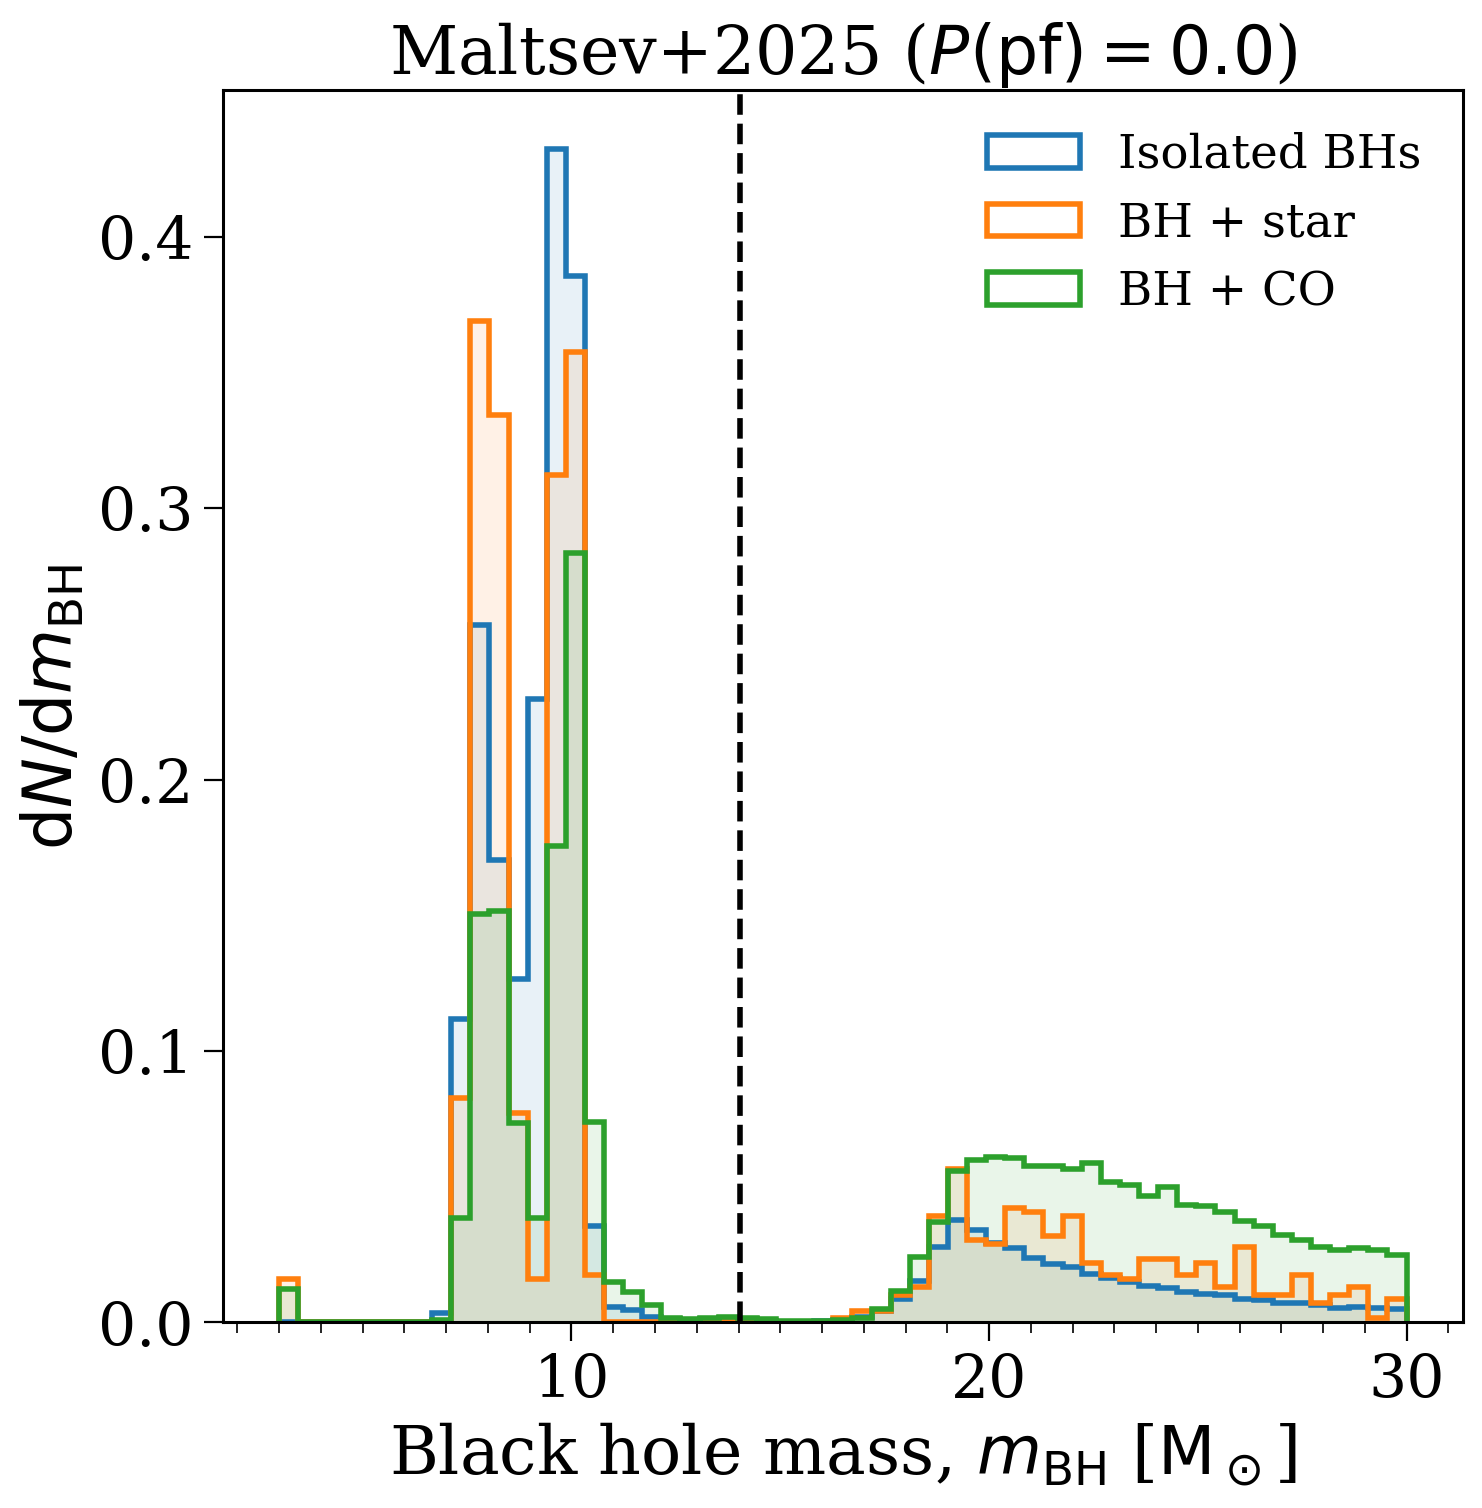

$P({\rm pf}) = 1.0$ 1639


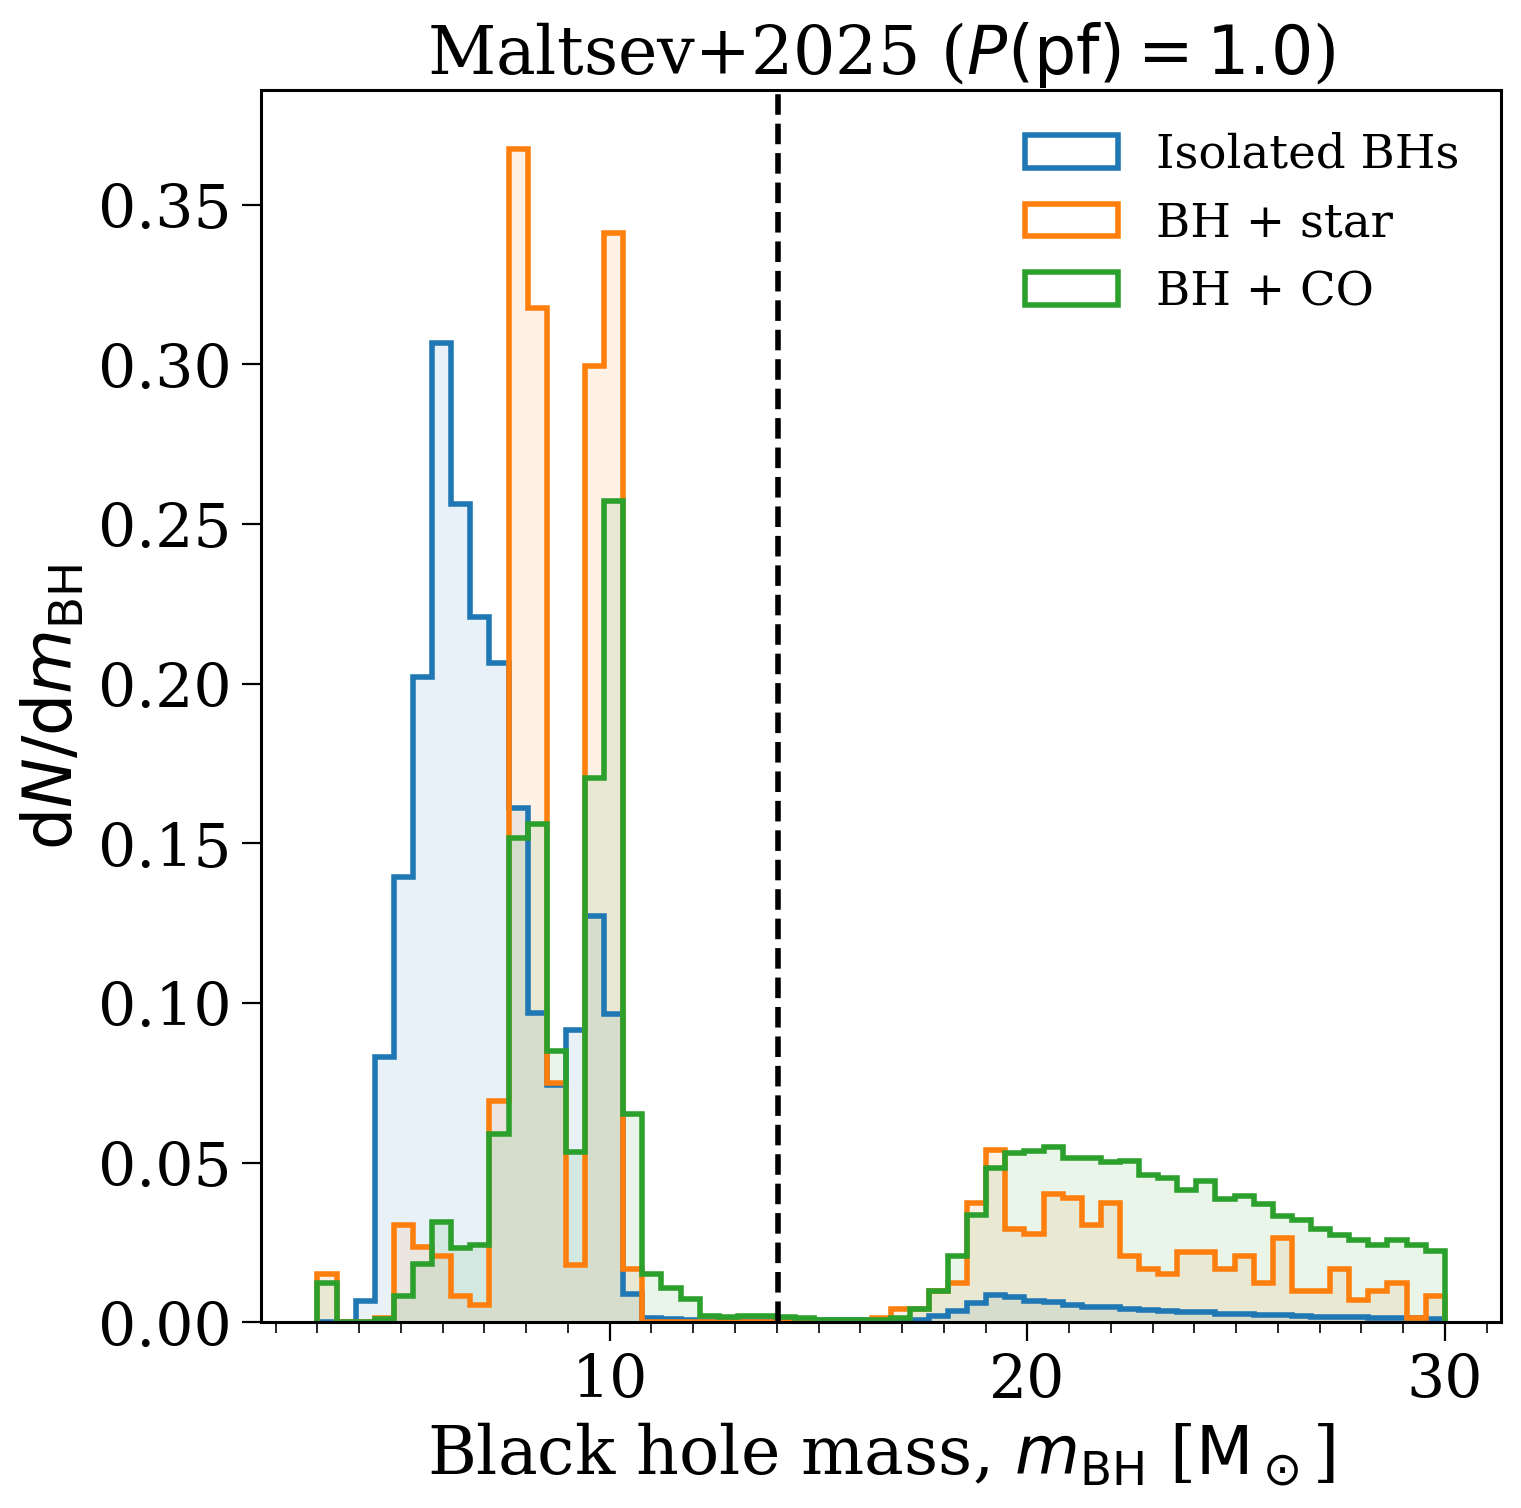

Time-evolving potential 1778


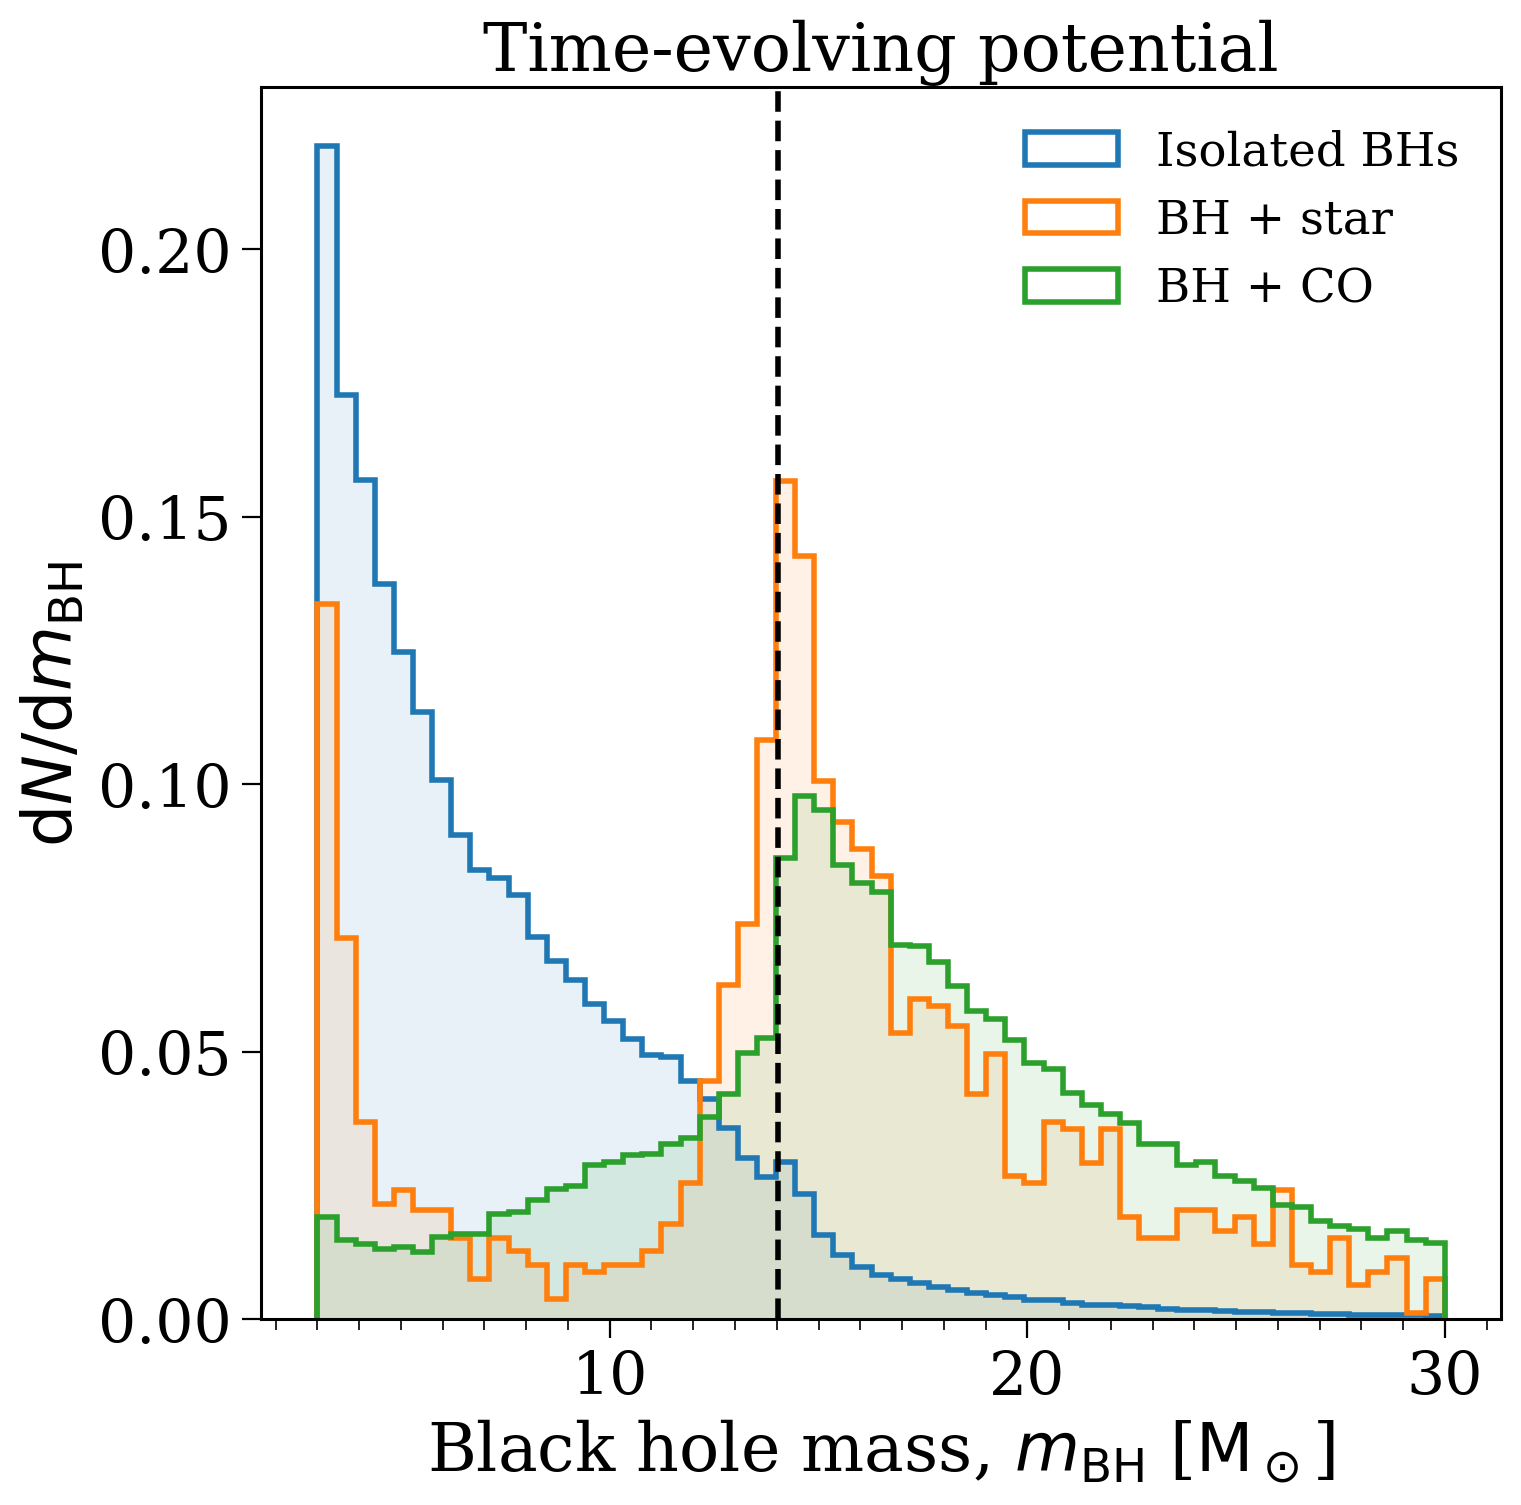

$\alpha_{\rm IMF} = -1.9$ 8534


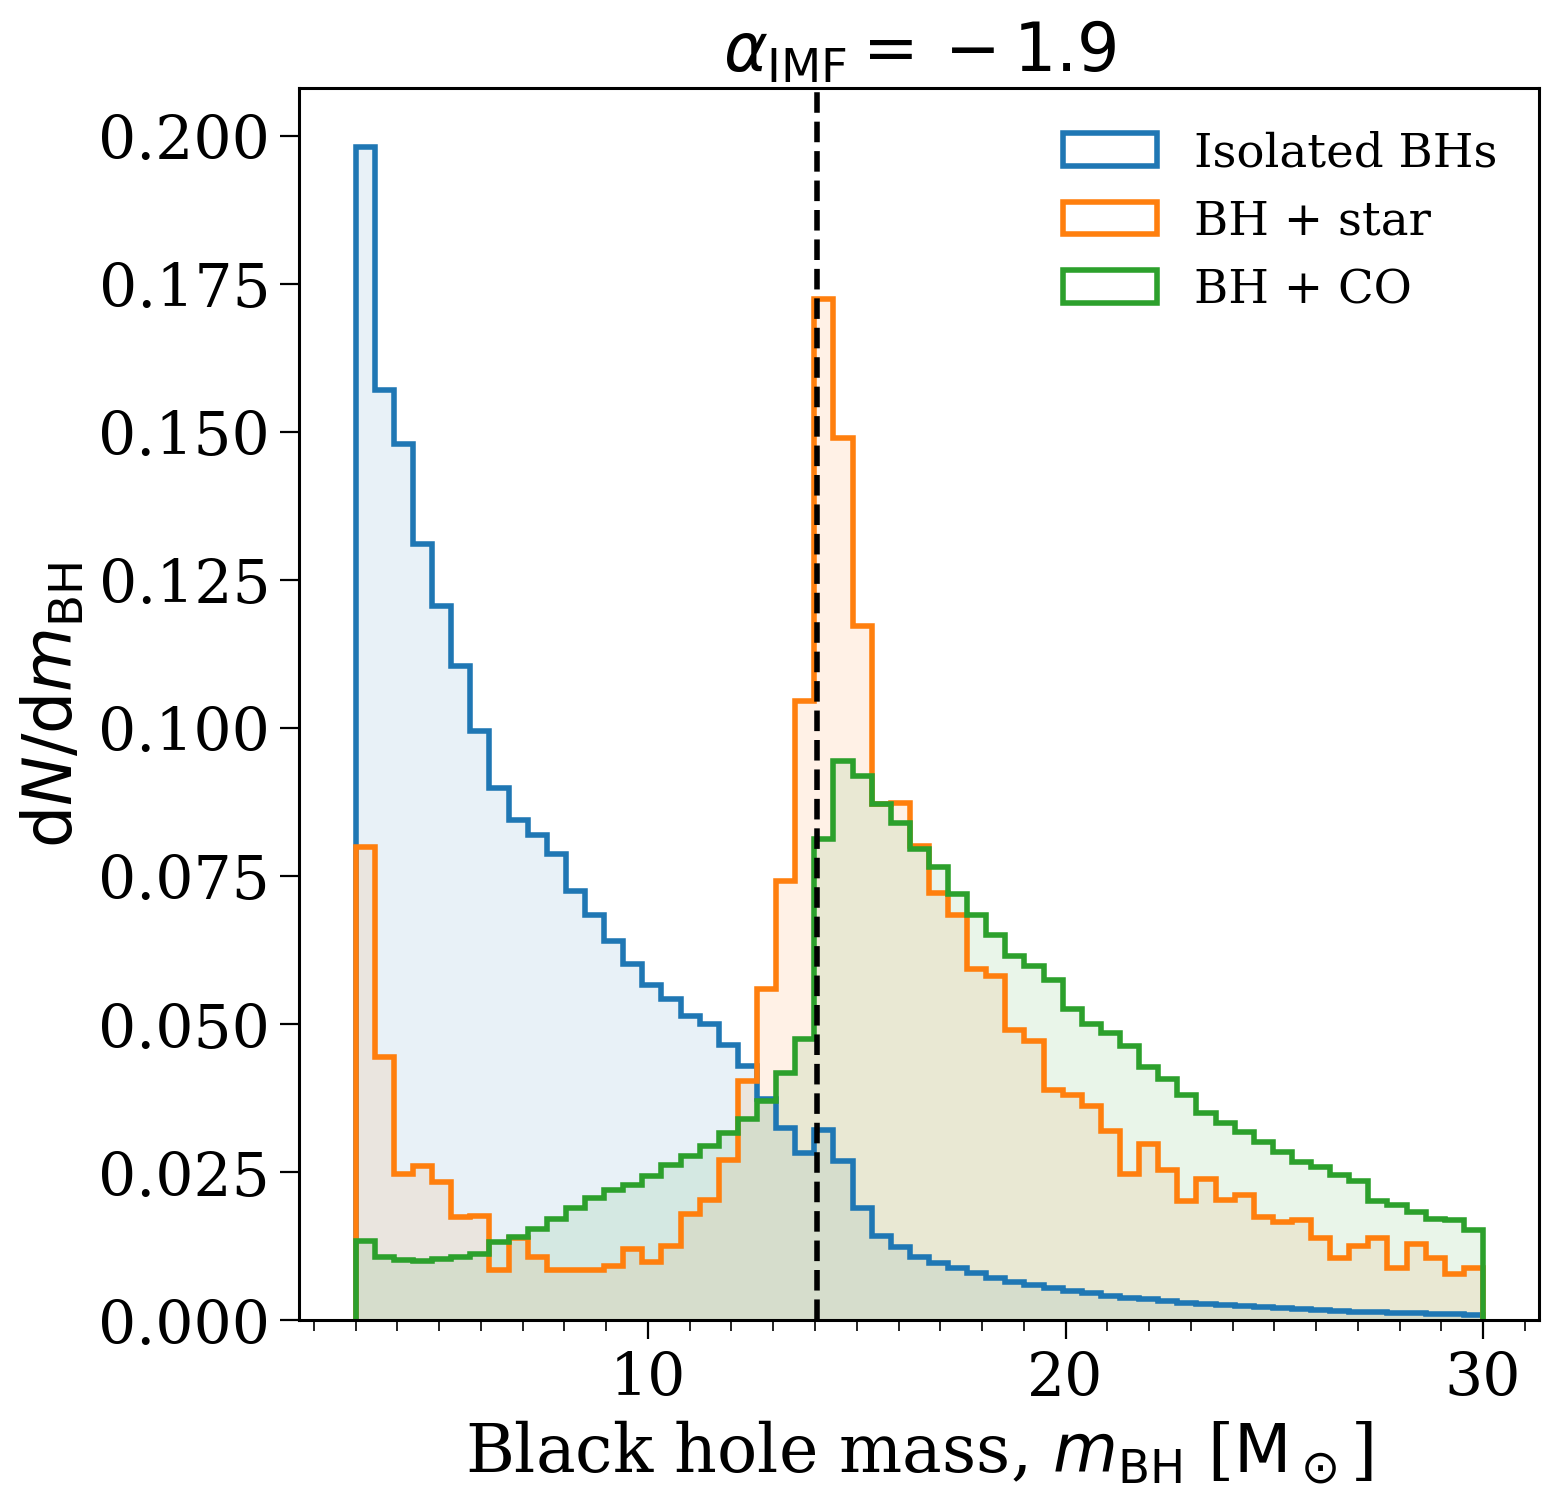

$\alpha_{\rm IMF} = -2.7$ 327


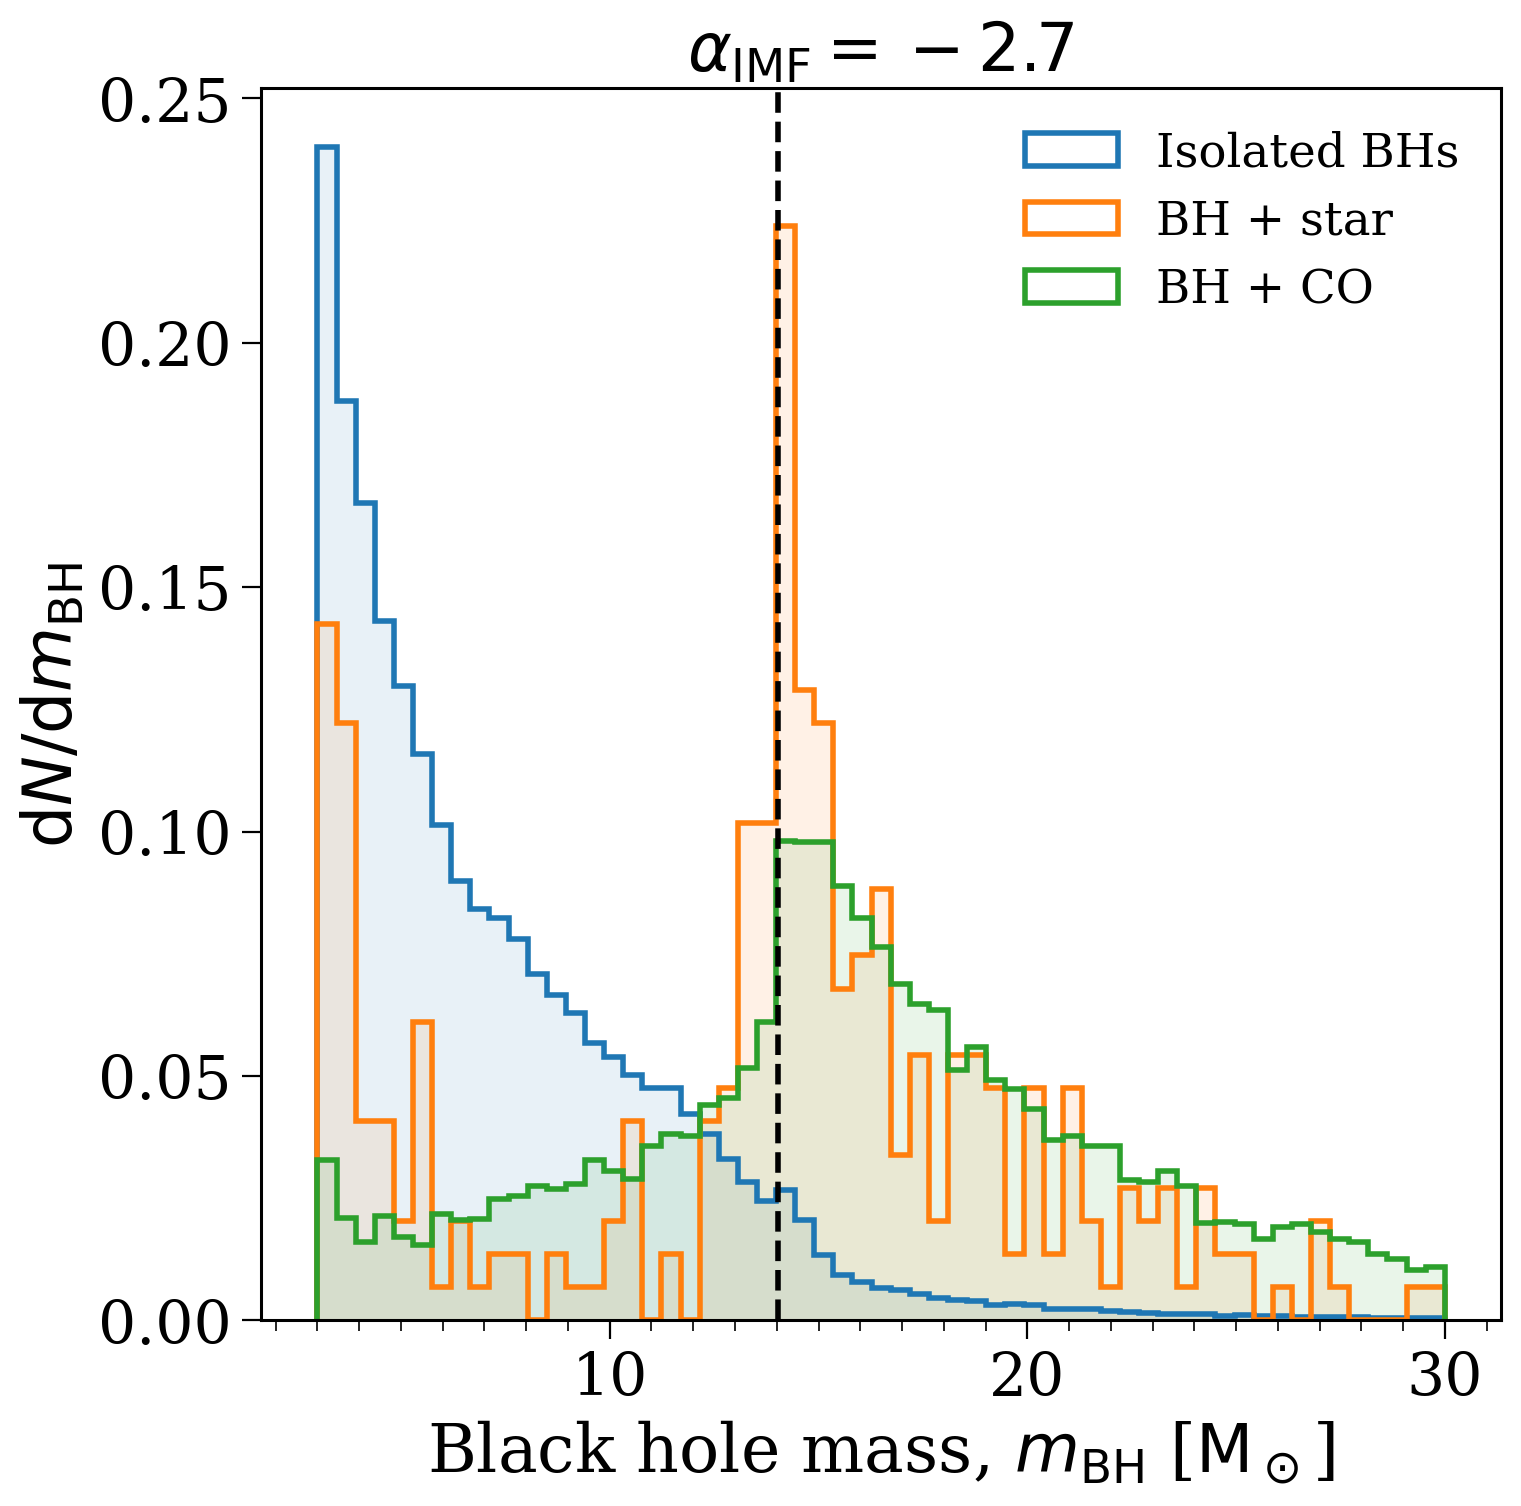

$\kappa = -1.0$ 42054


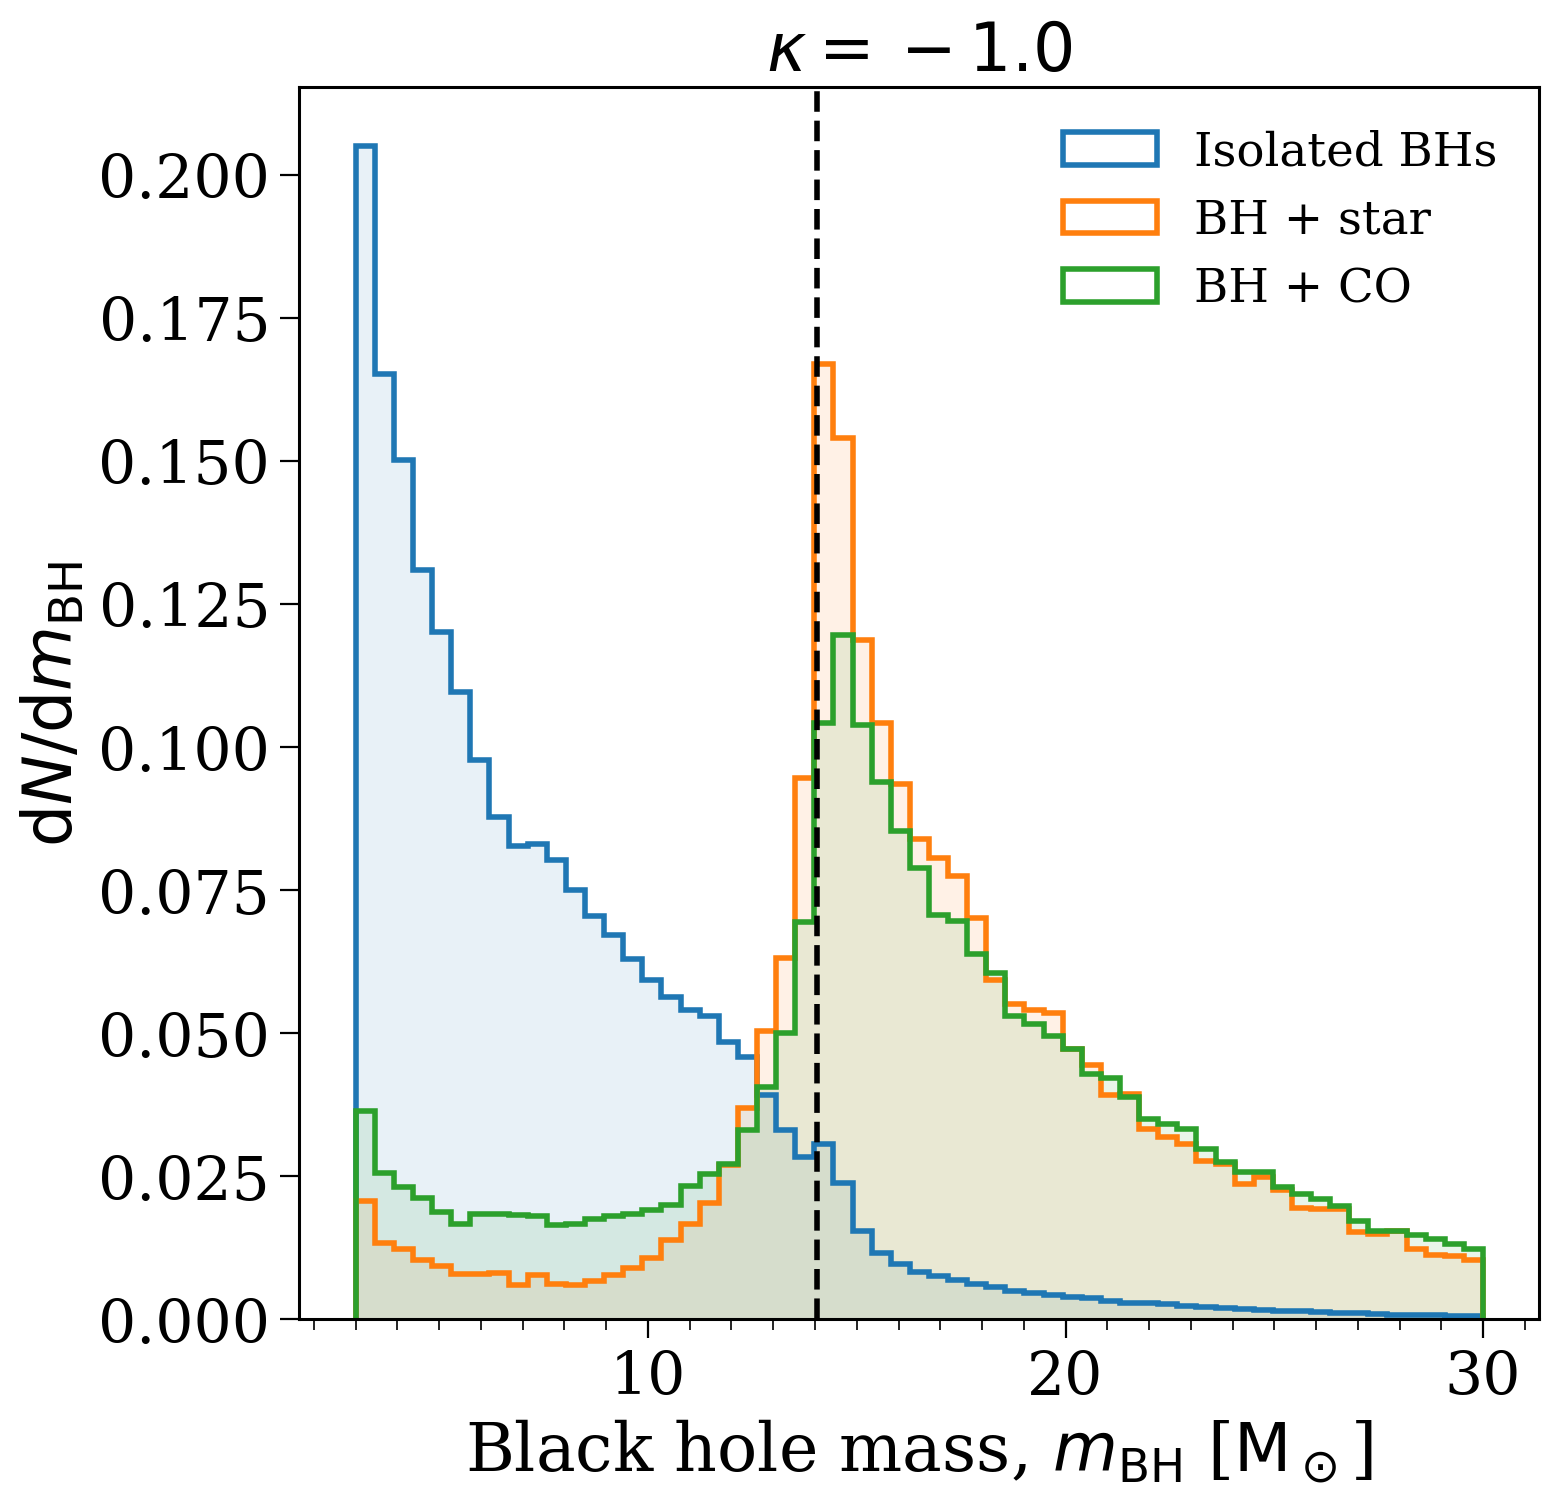

$\kappa = 1.0$ 81


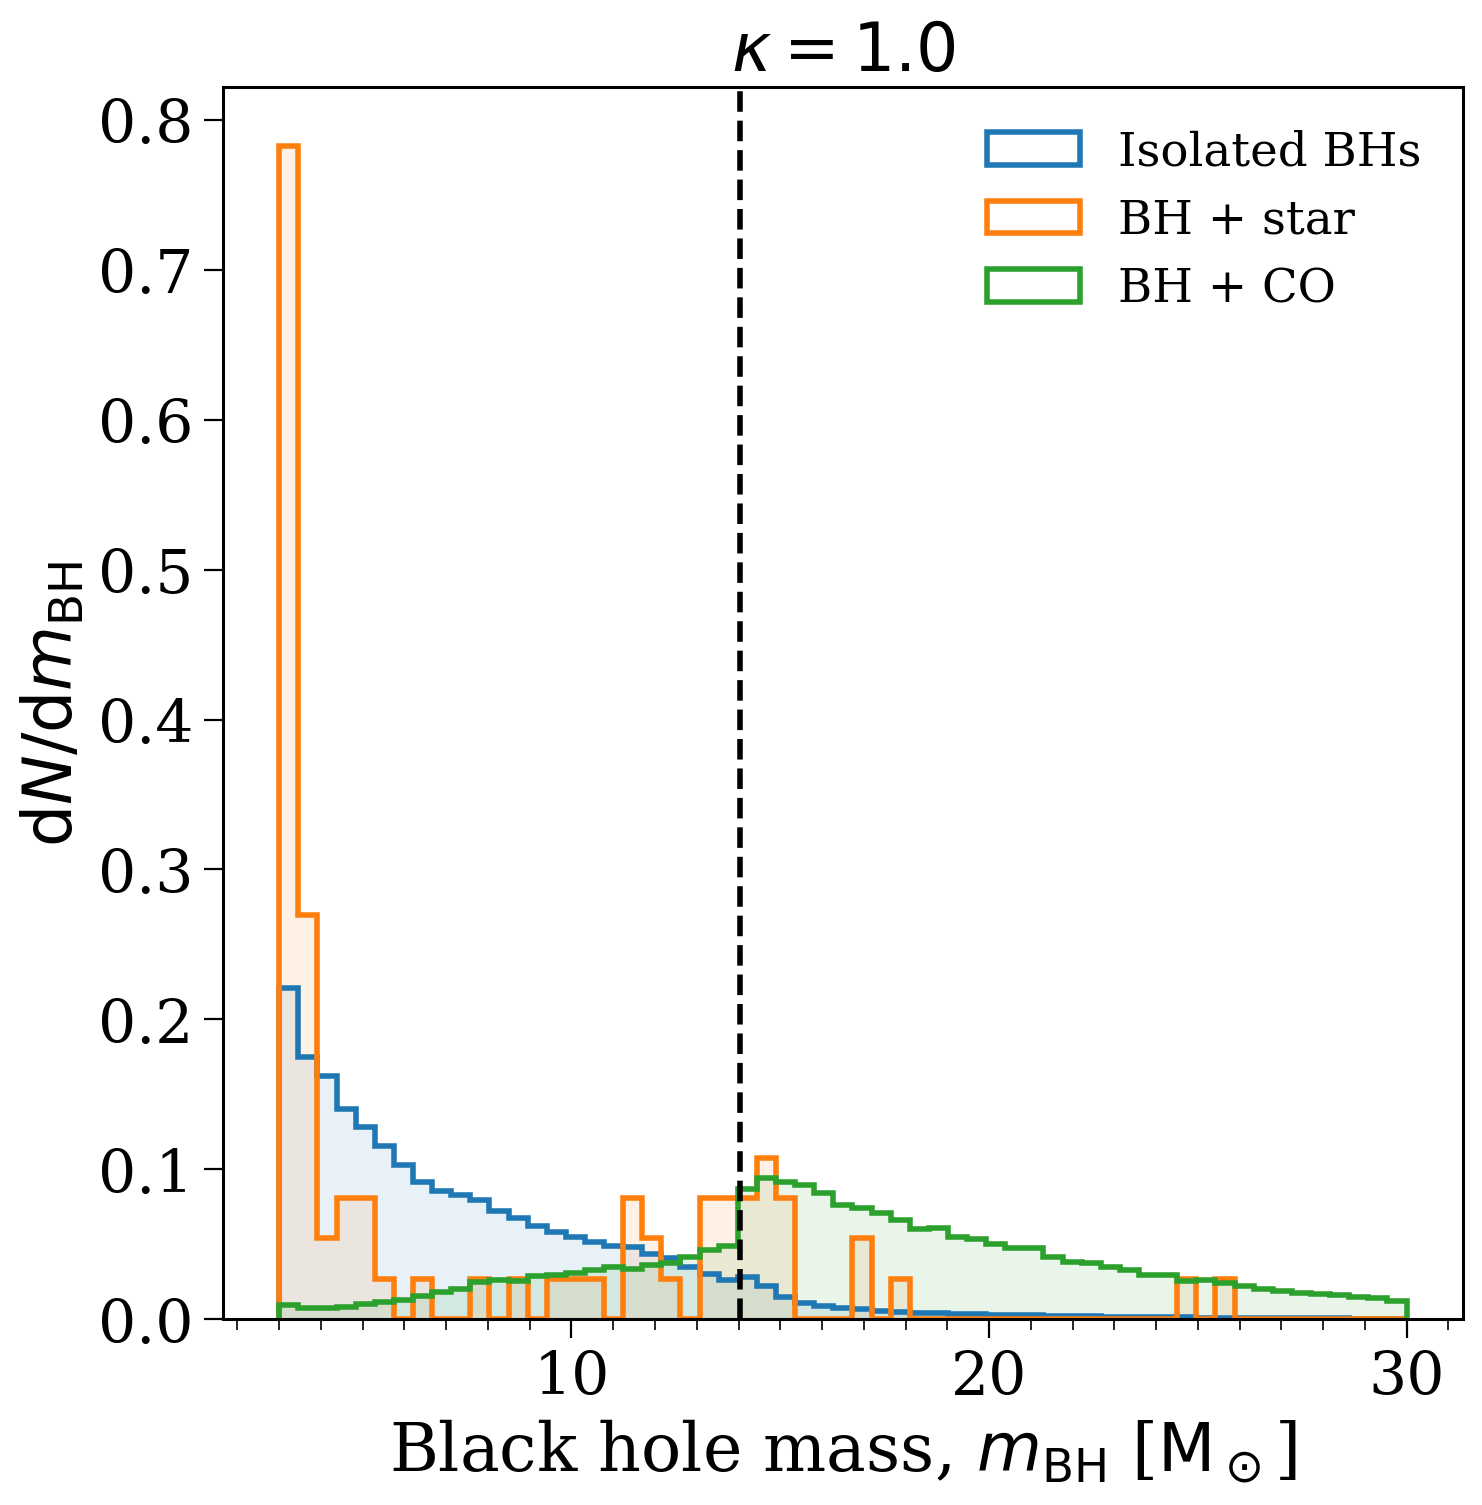

$q_{\rm min} = -1.0$ 169


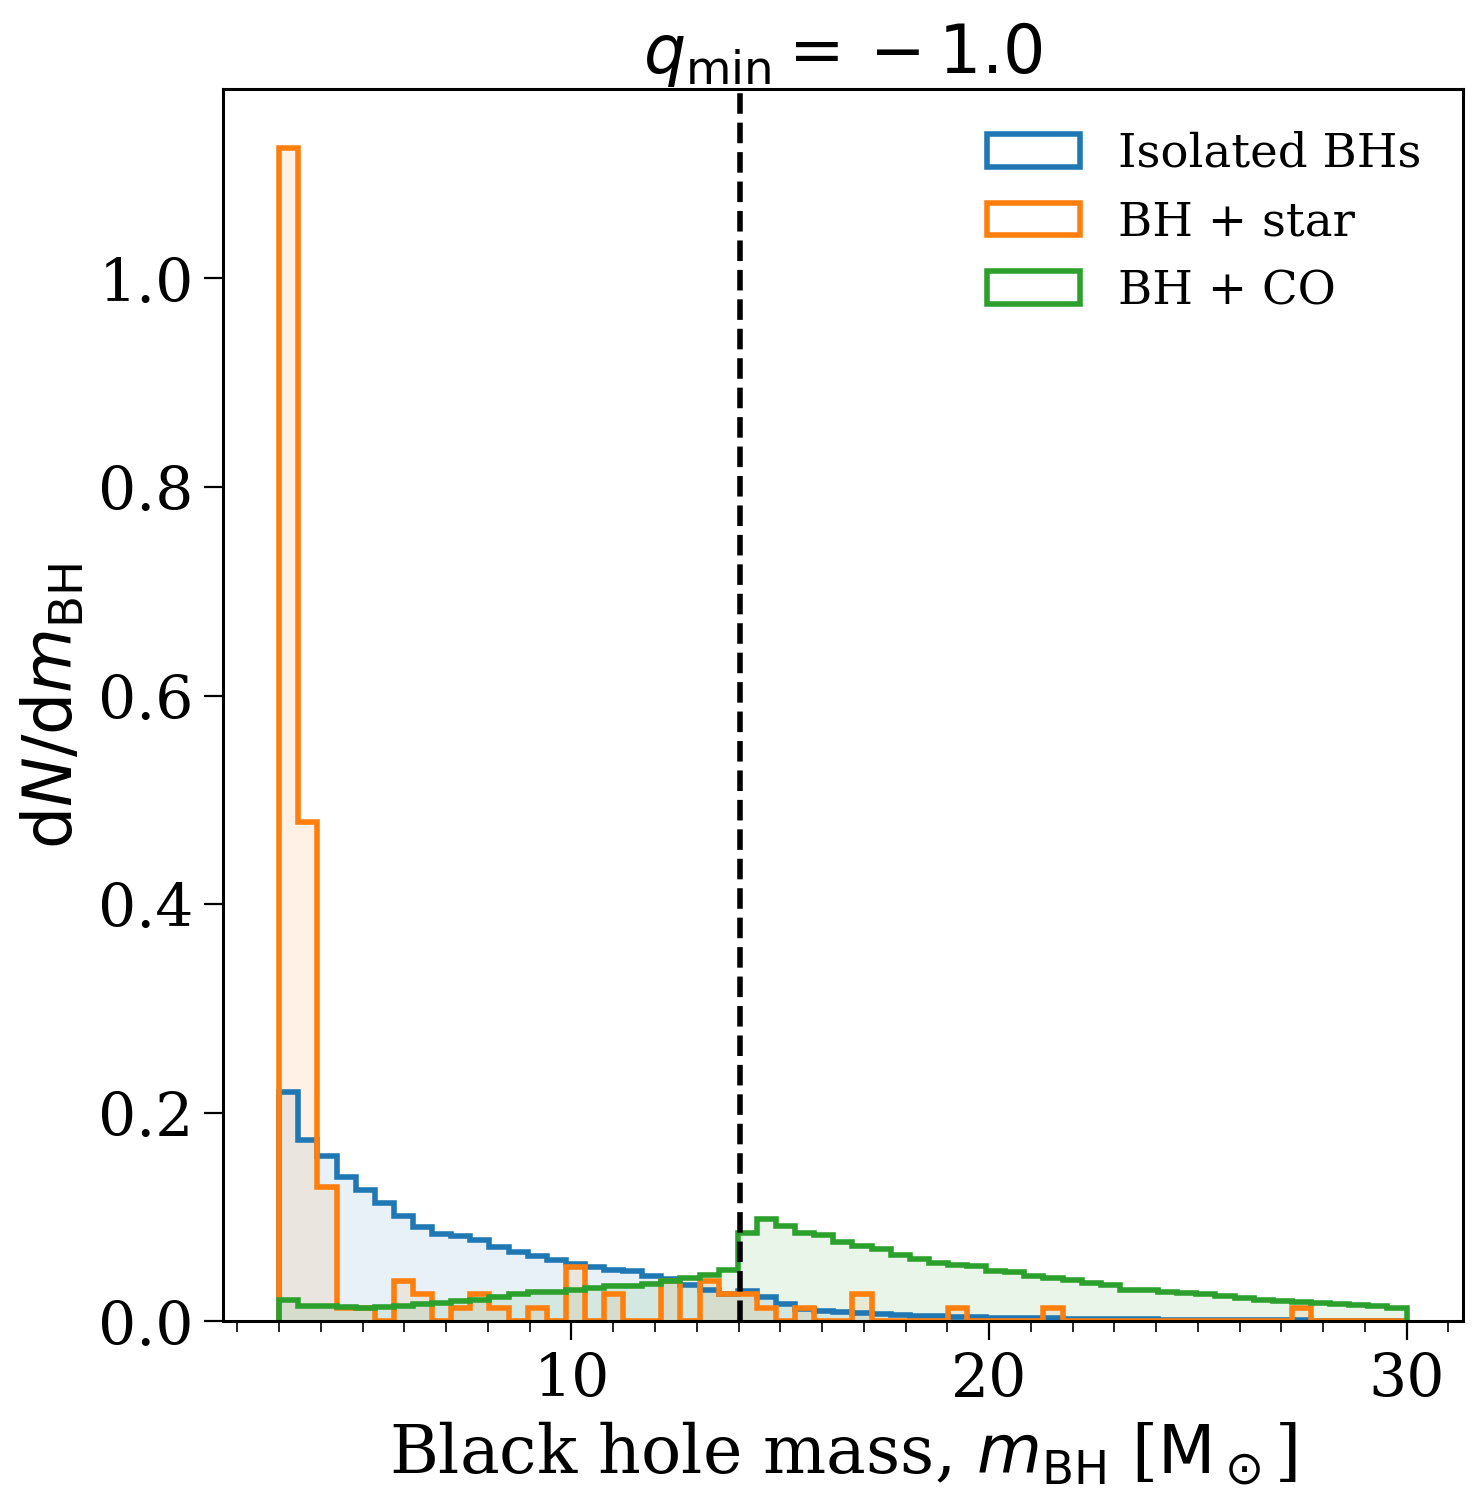

$\pi = 0.0$ 2225


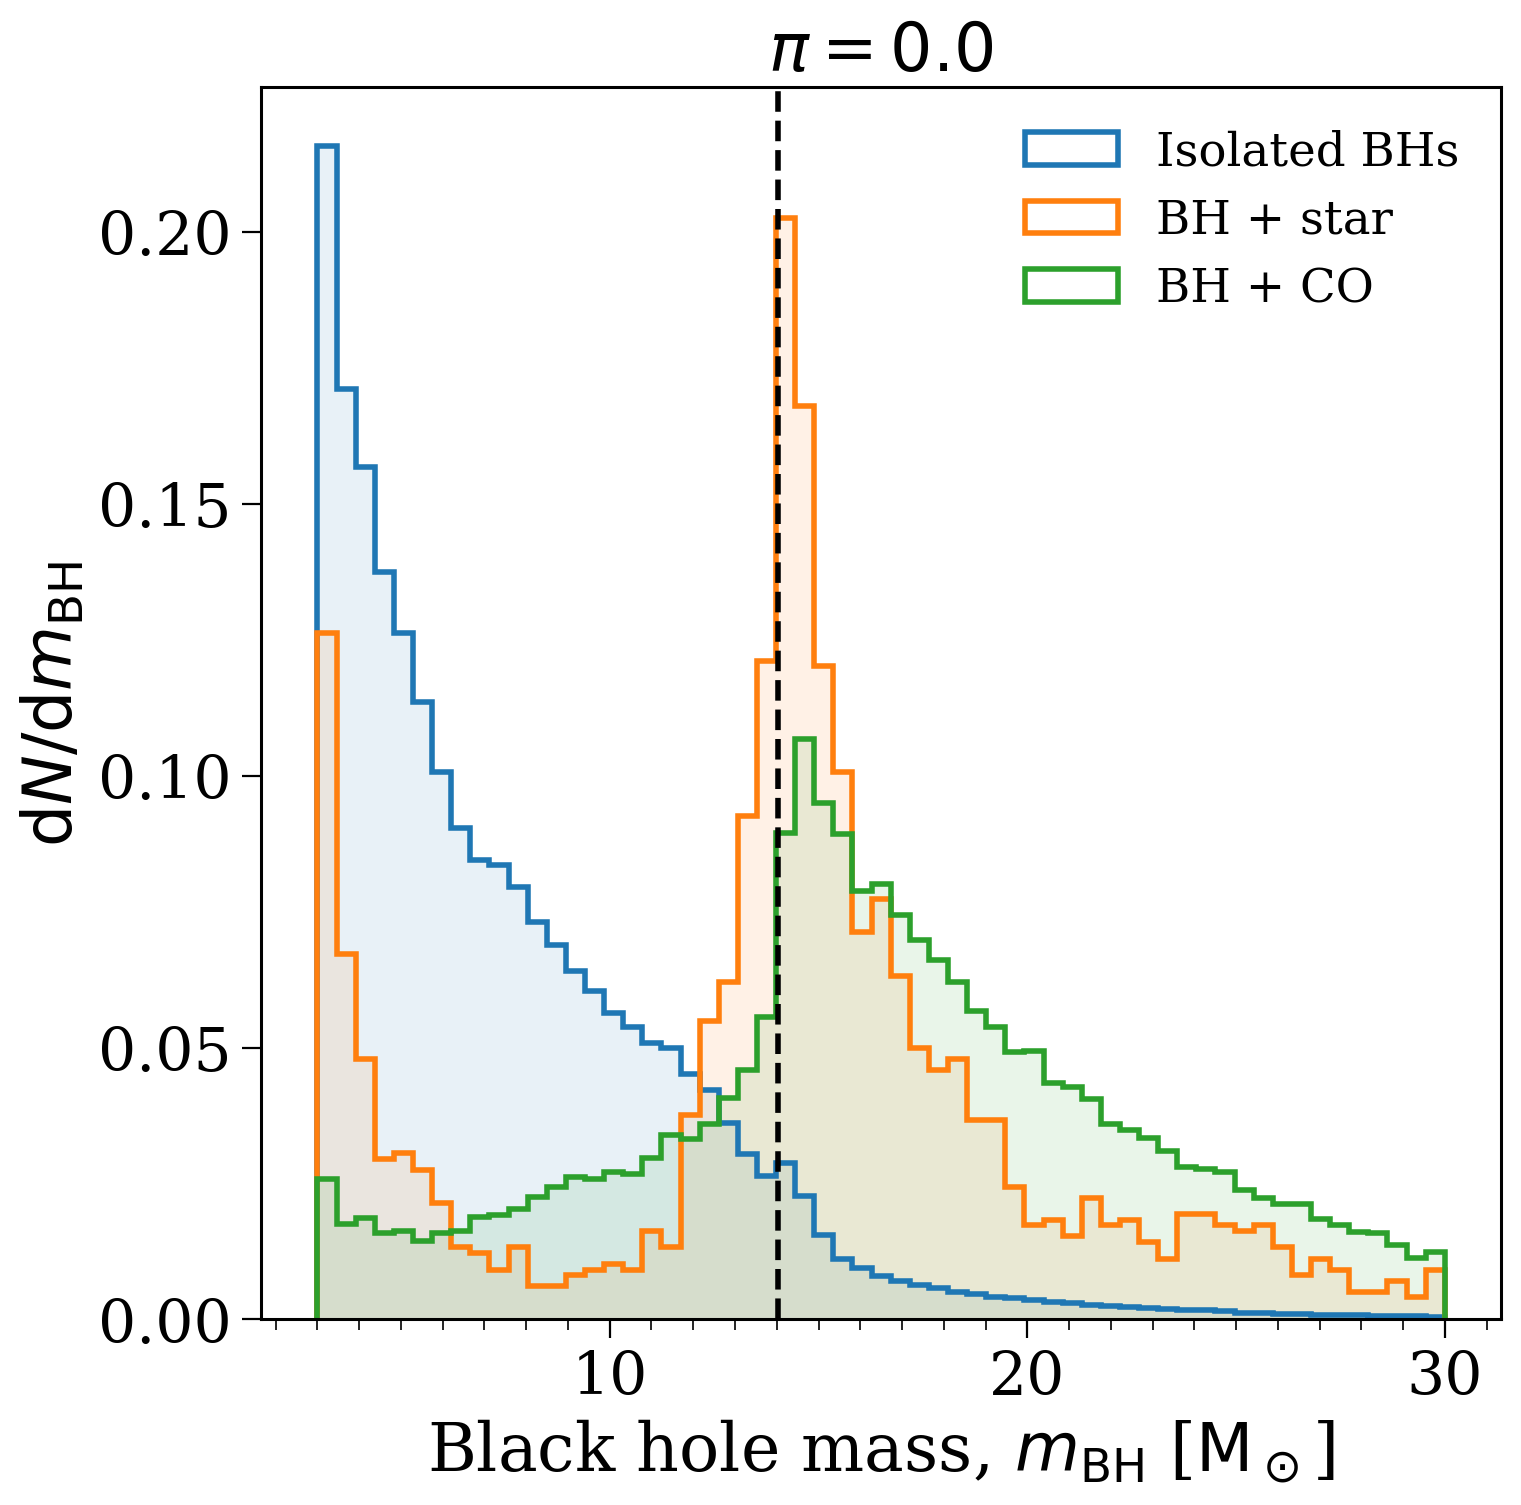

$\pi = -1.0$ 1340


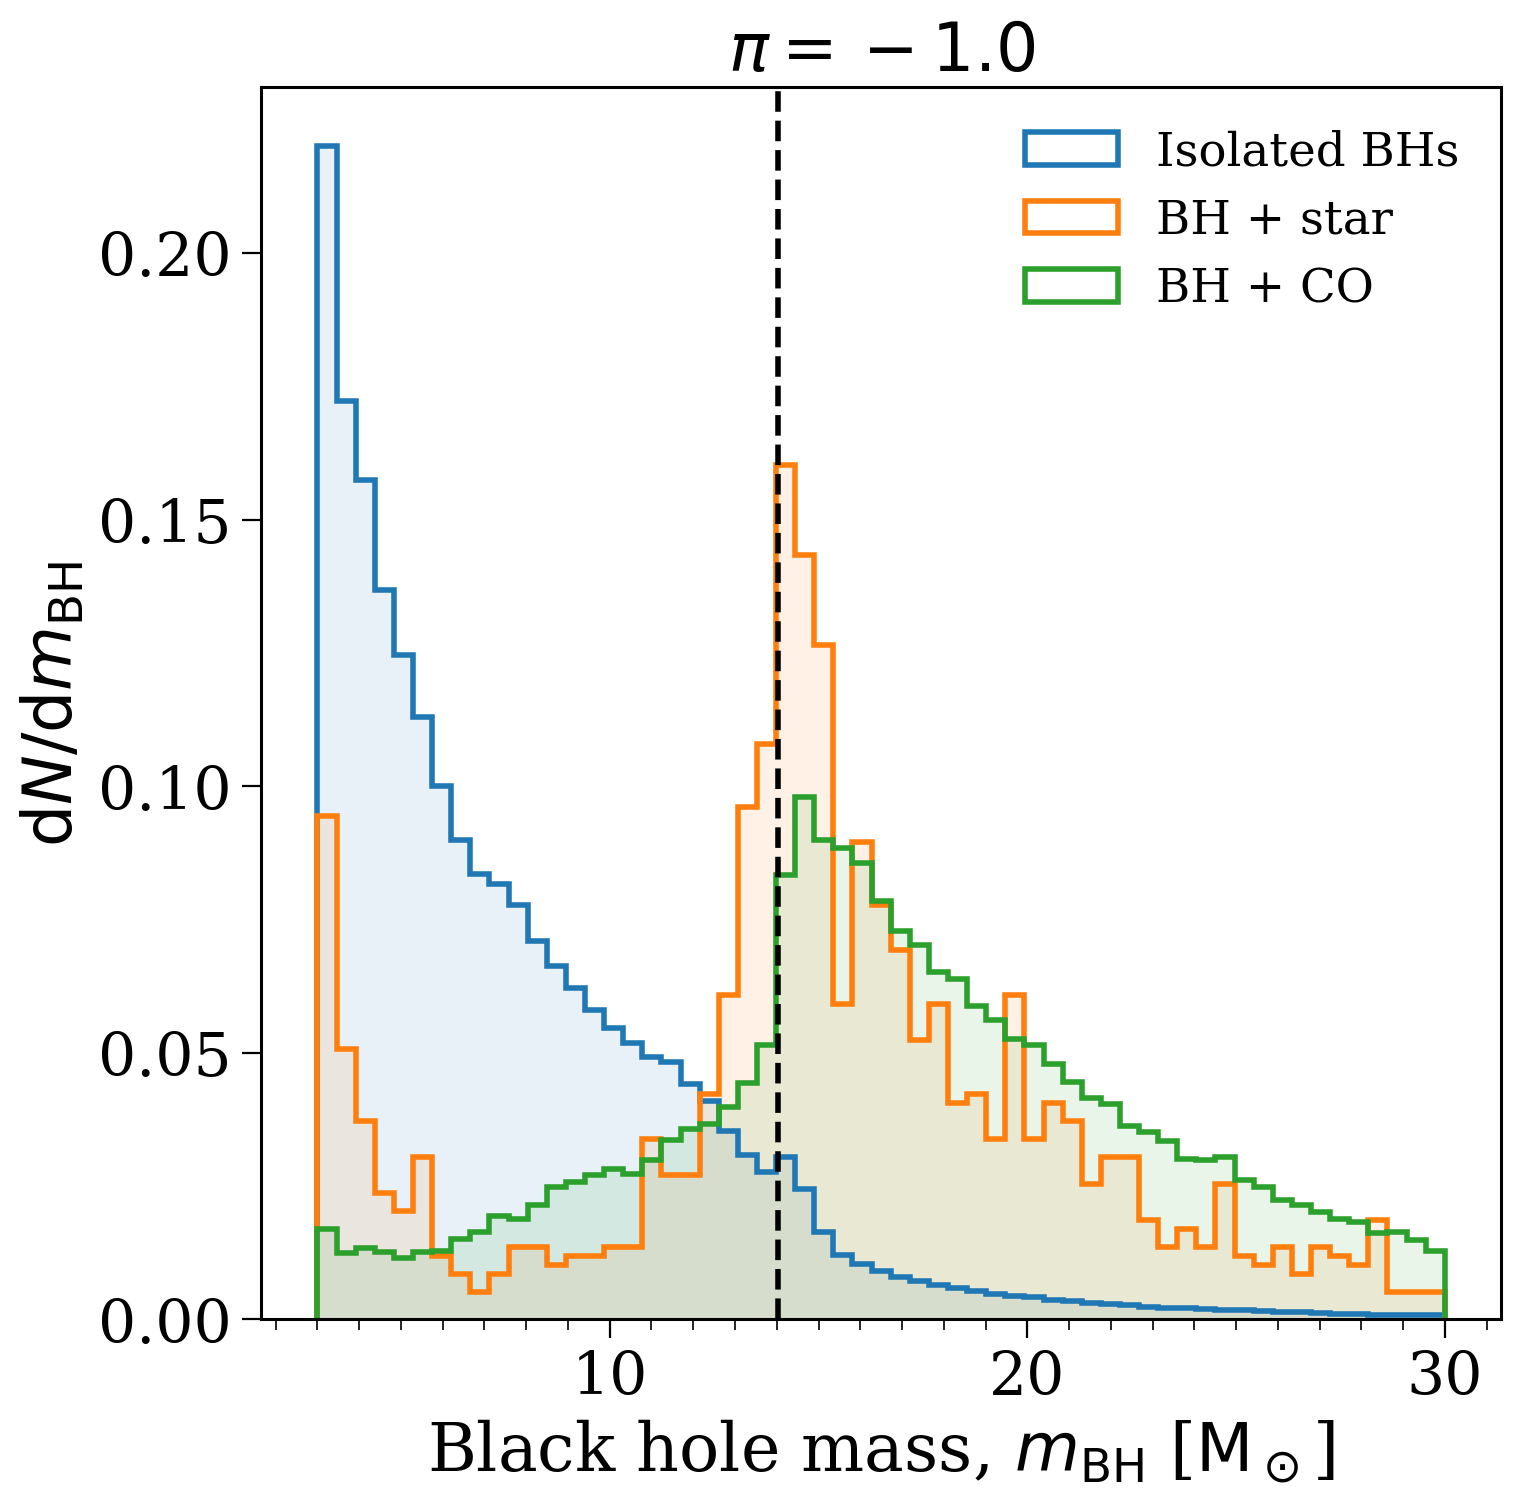

$P_{\rm orb, max} = 10^3\,{\rm days}$ 1781


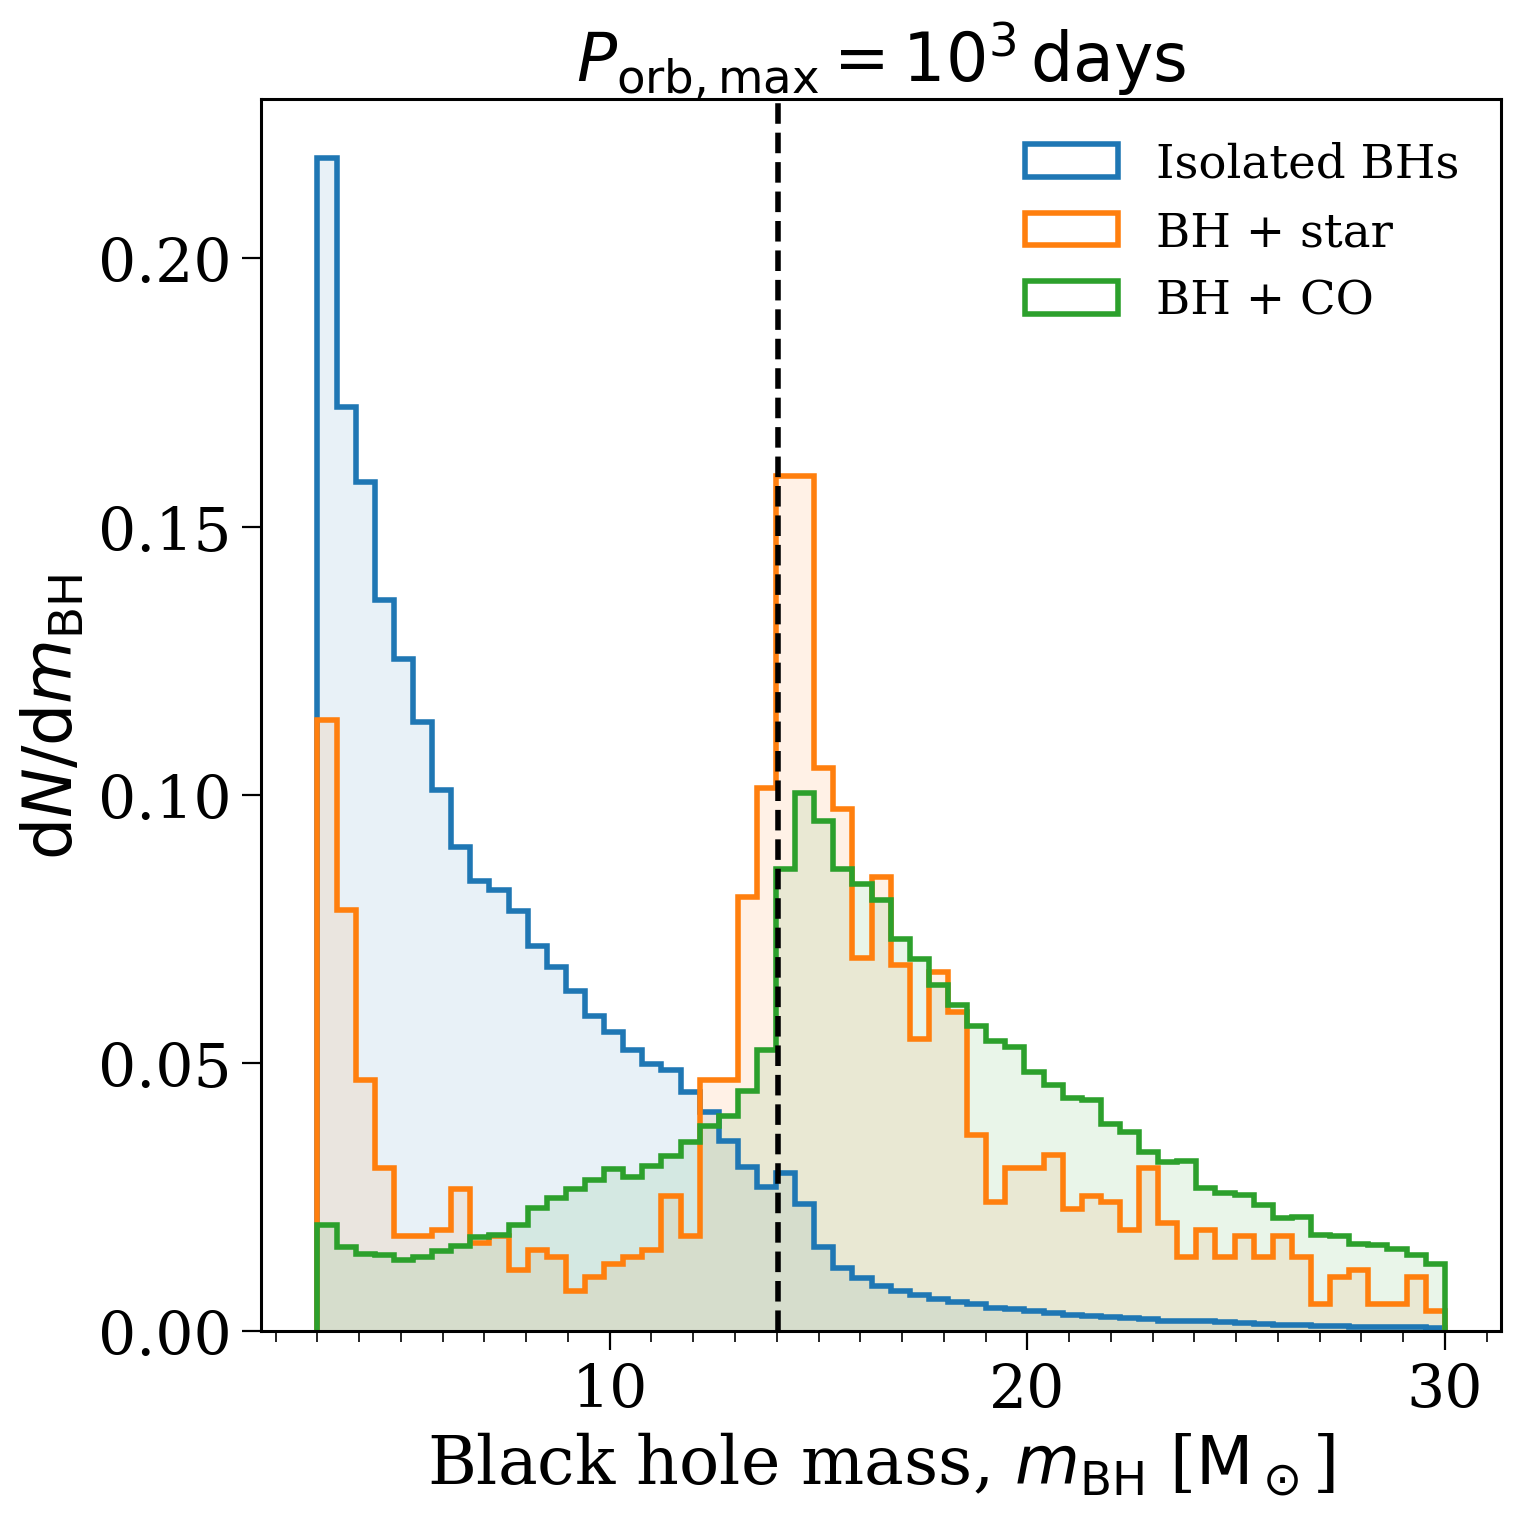

$\beta = 0.0$ 1675


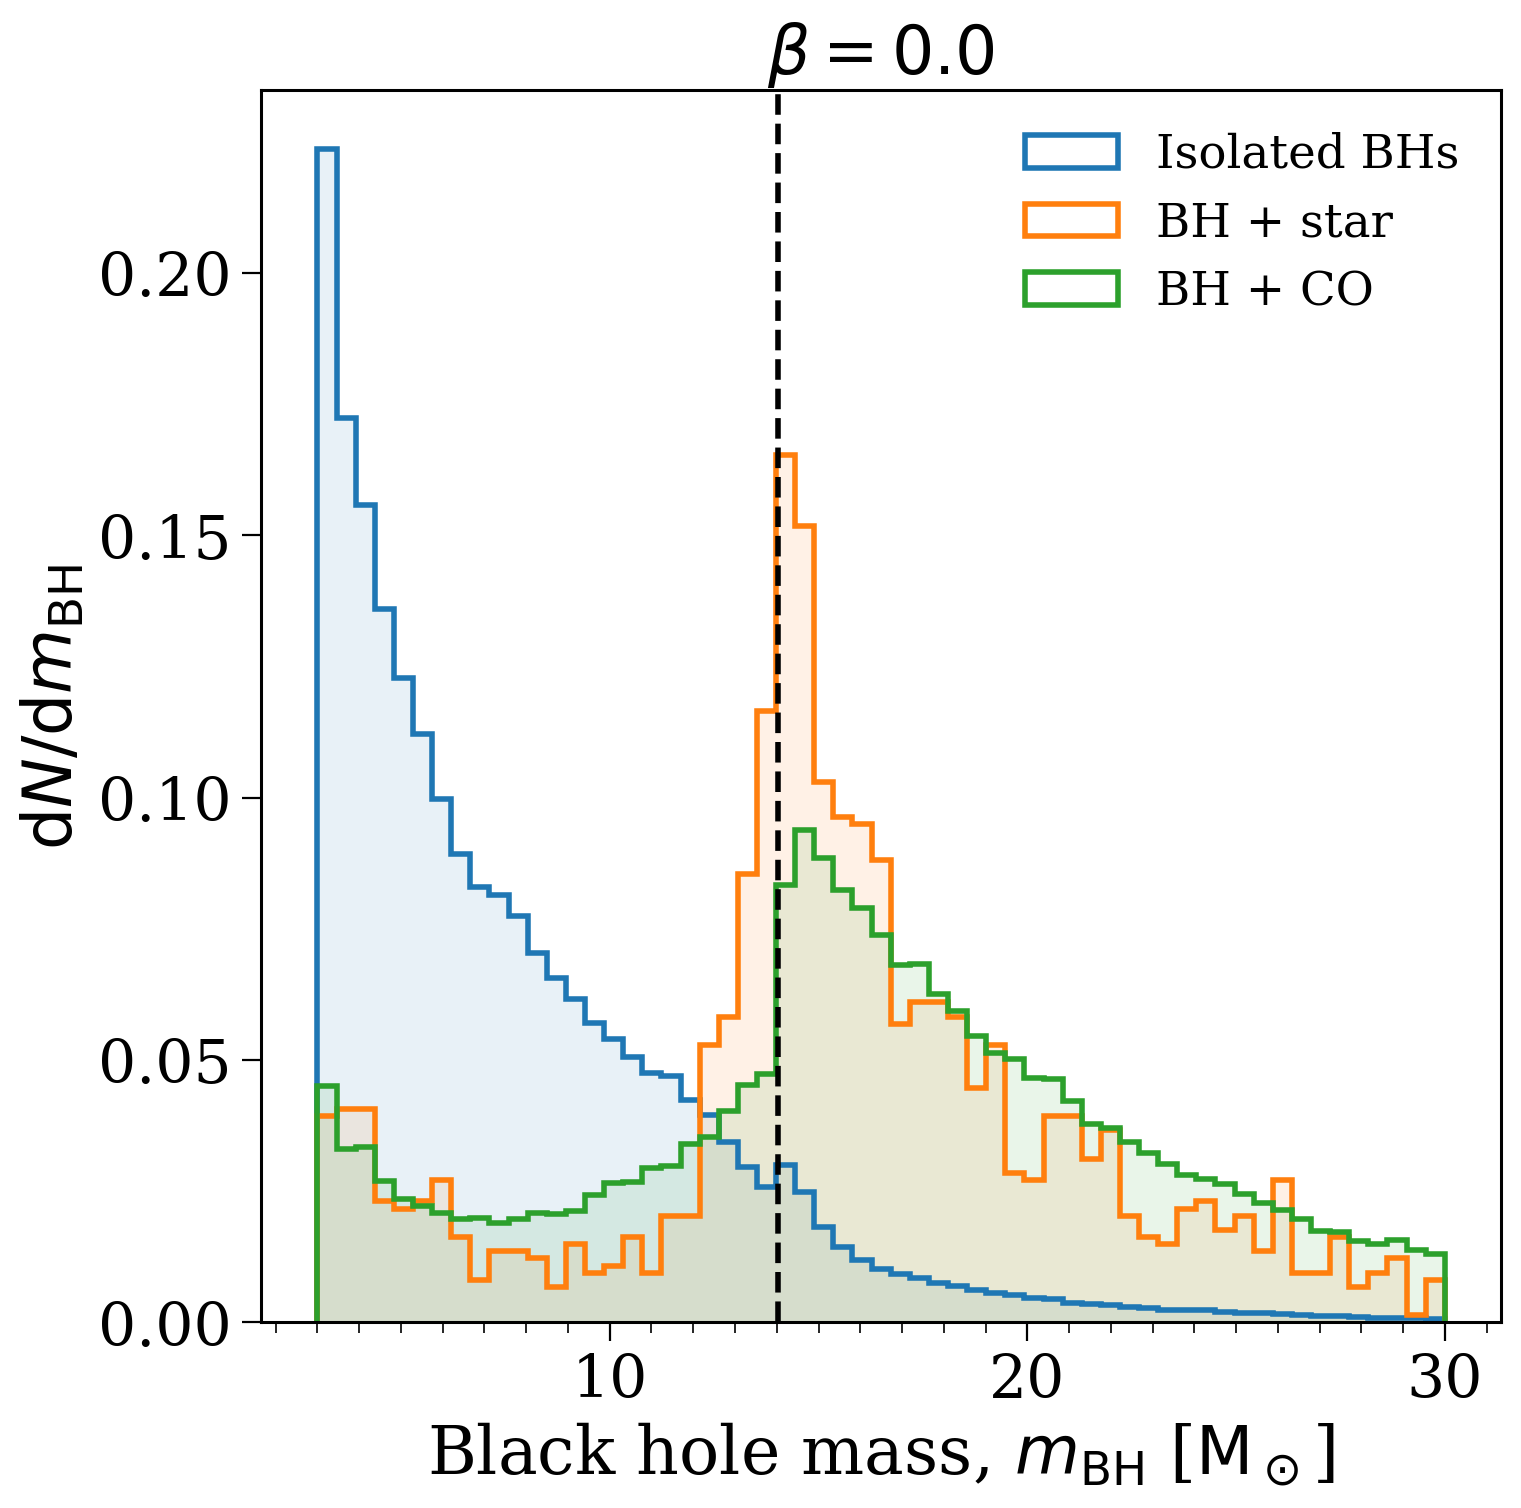

$\beta = 0.5$ 1686


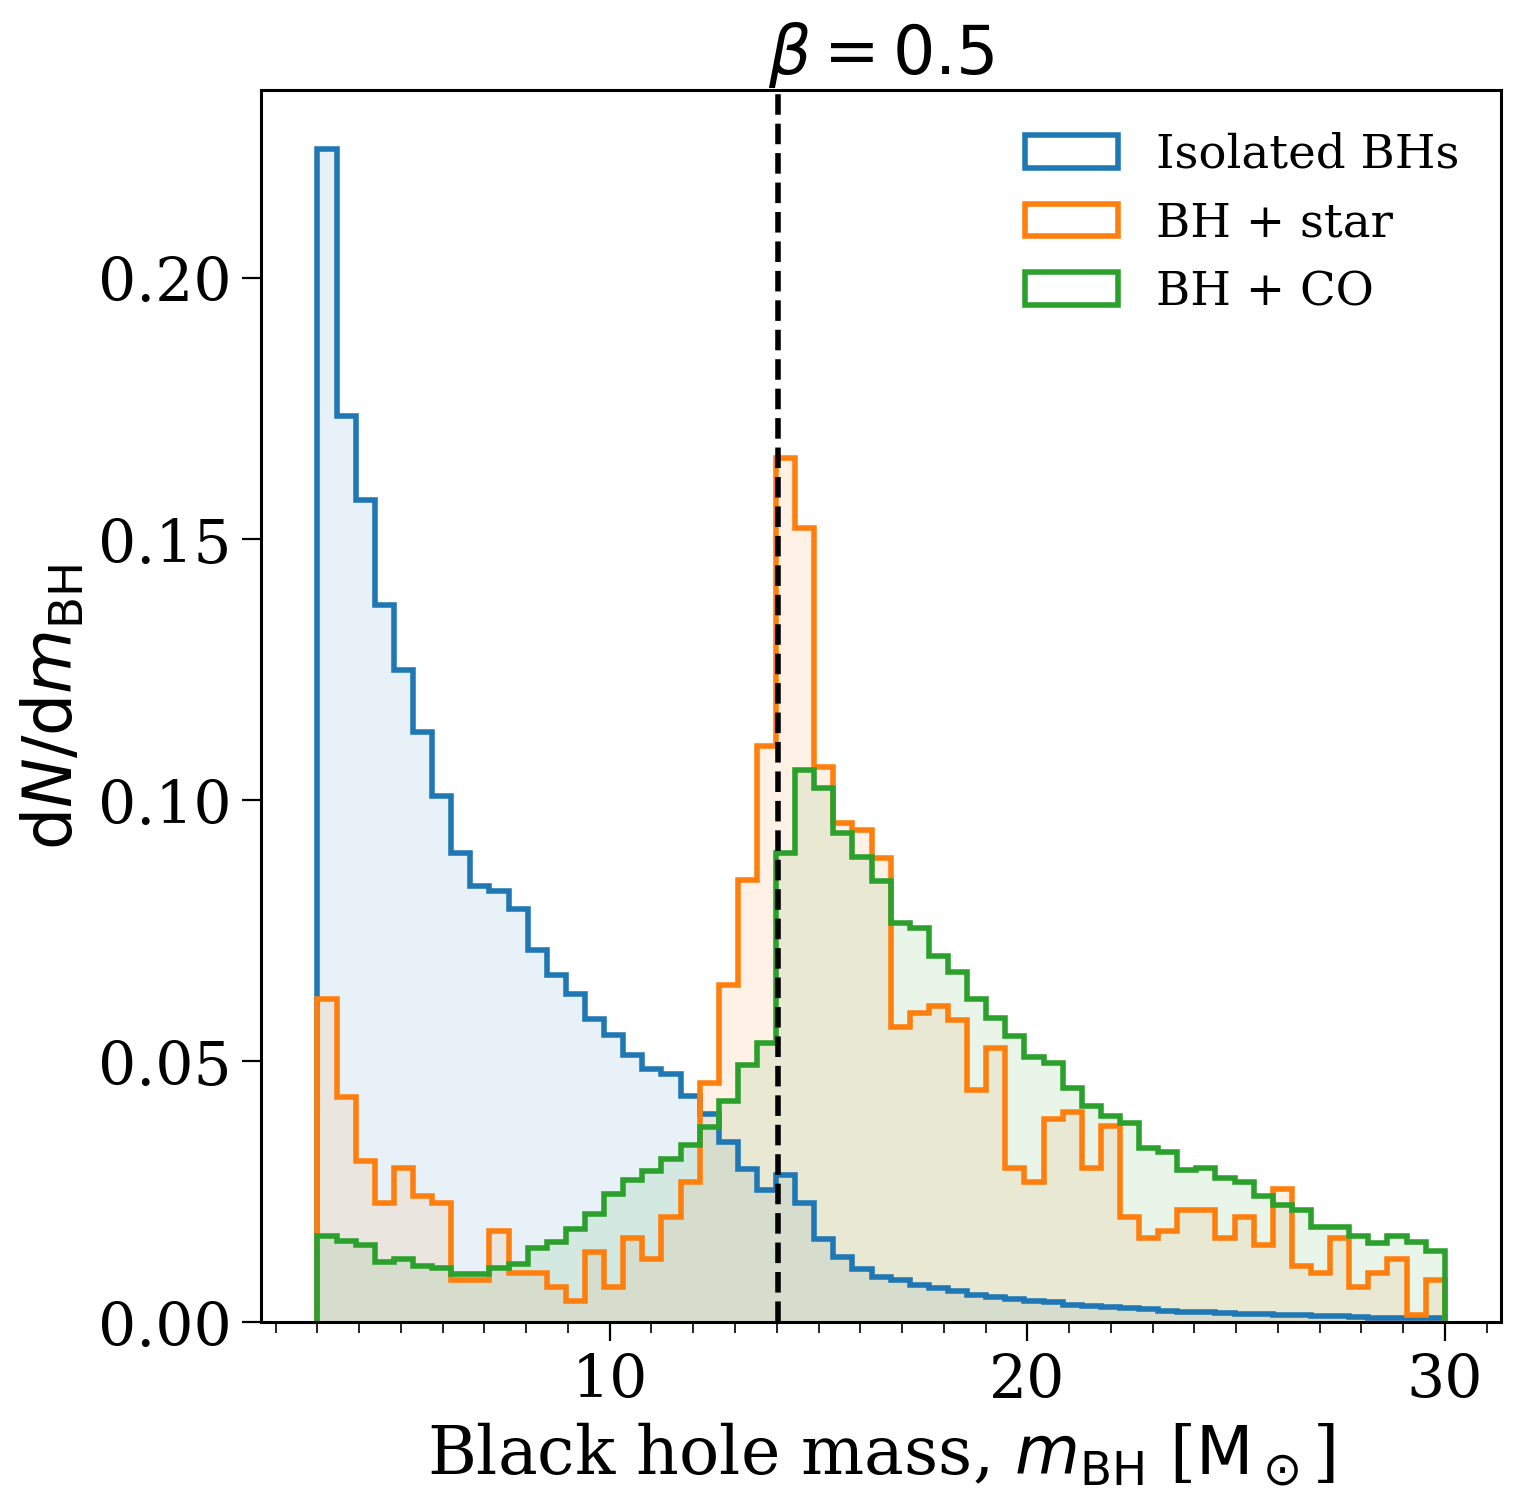

$\beta = 1.0$ 1742


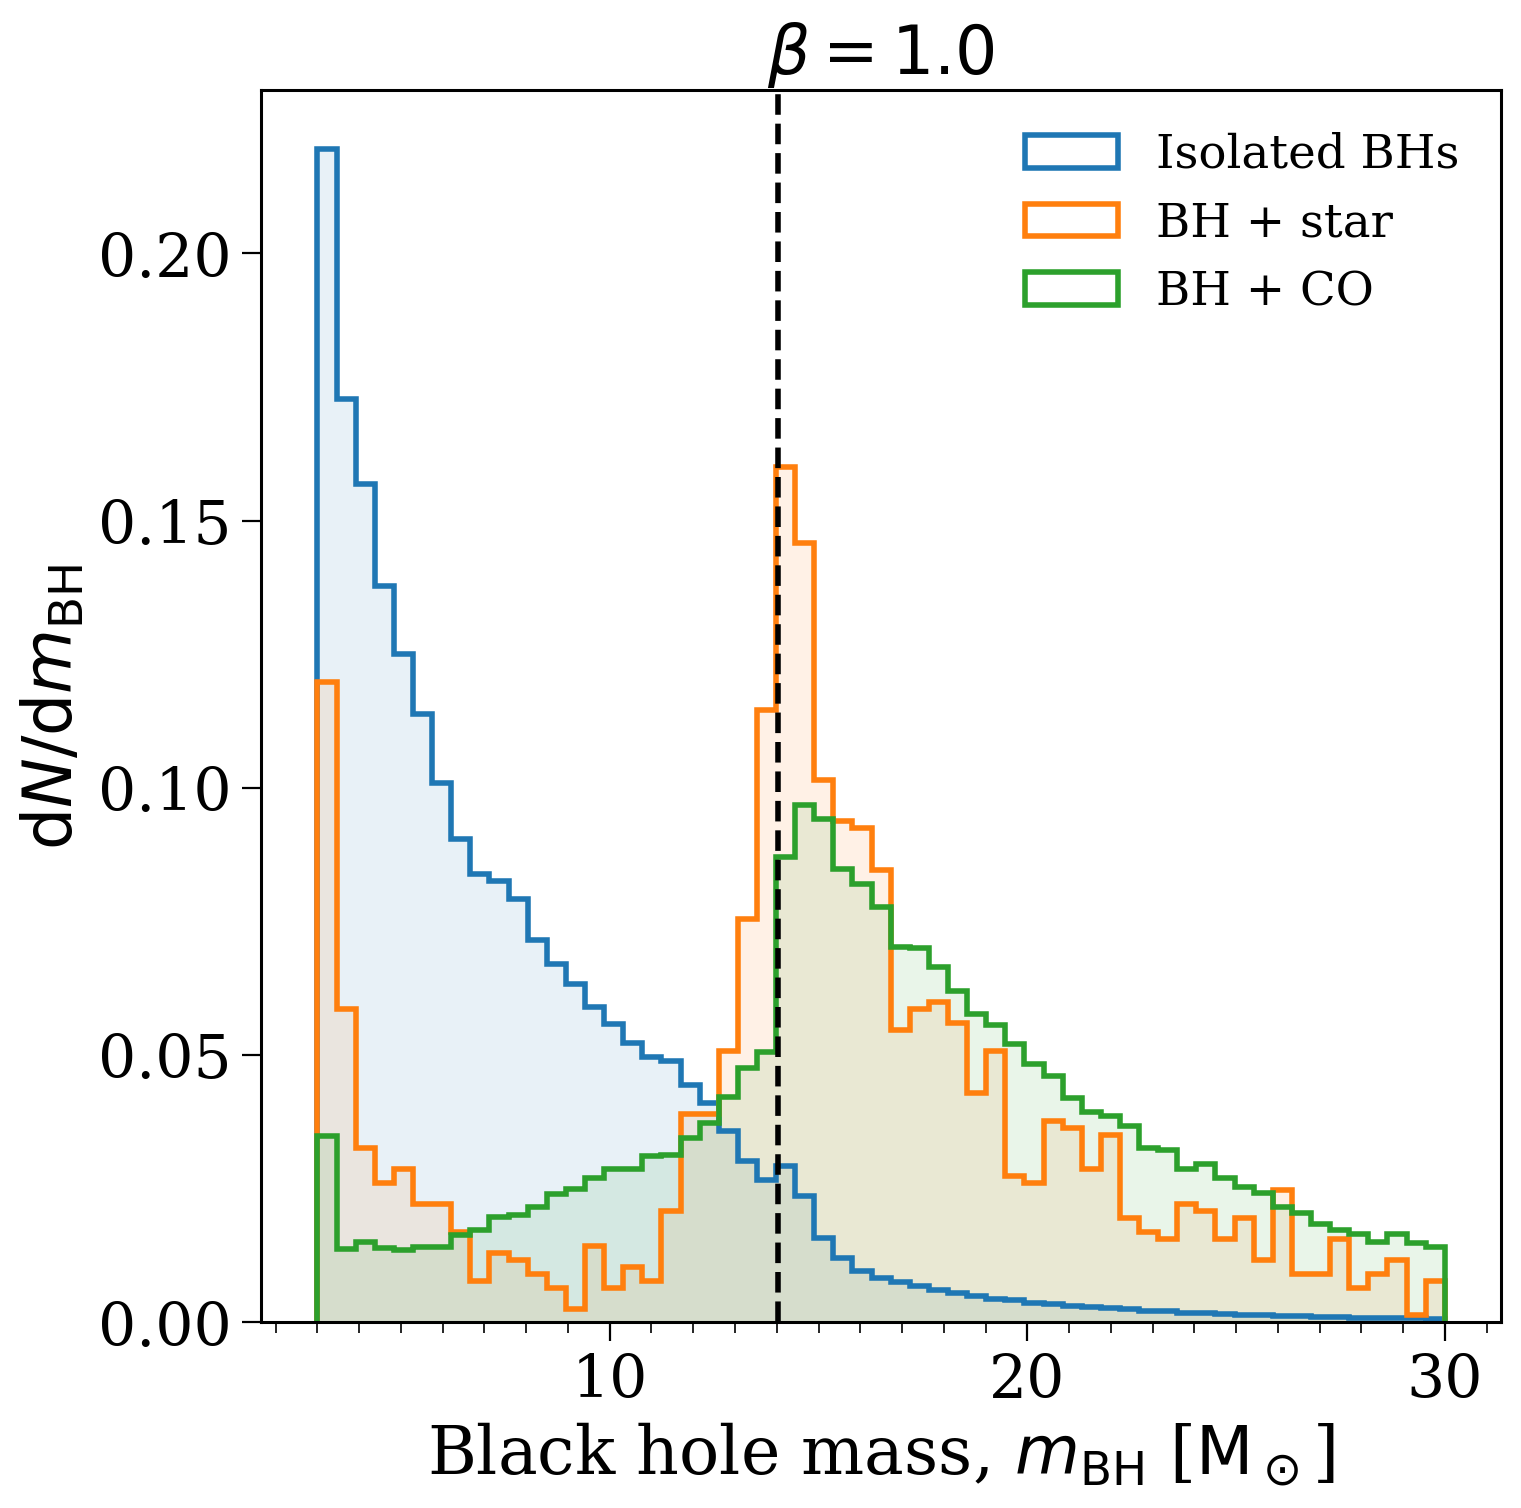

$\alpha_{\rm CE} = 0.1$ 1540


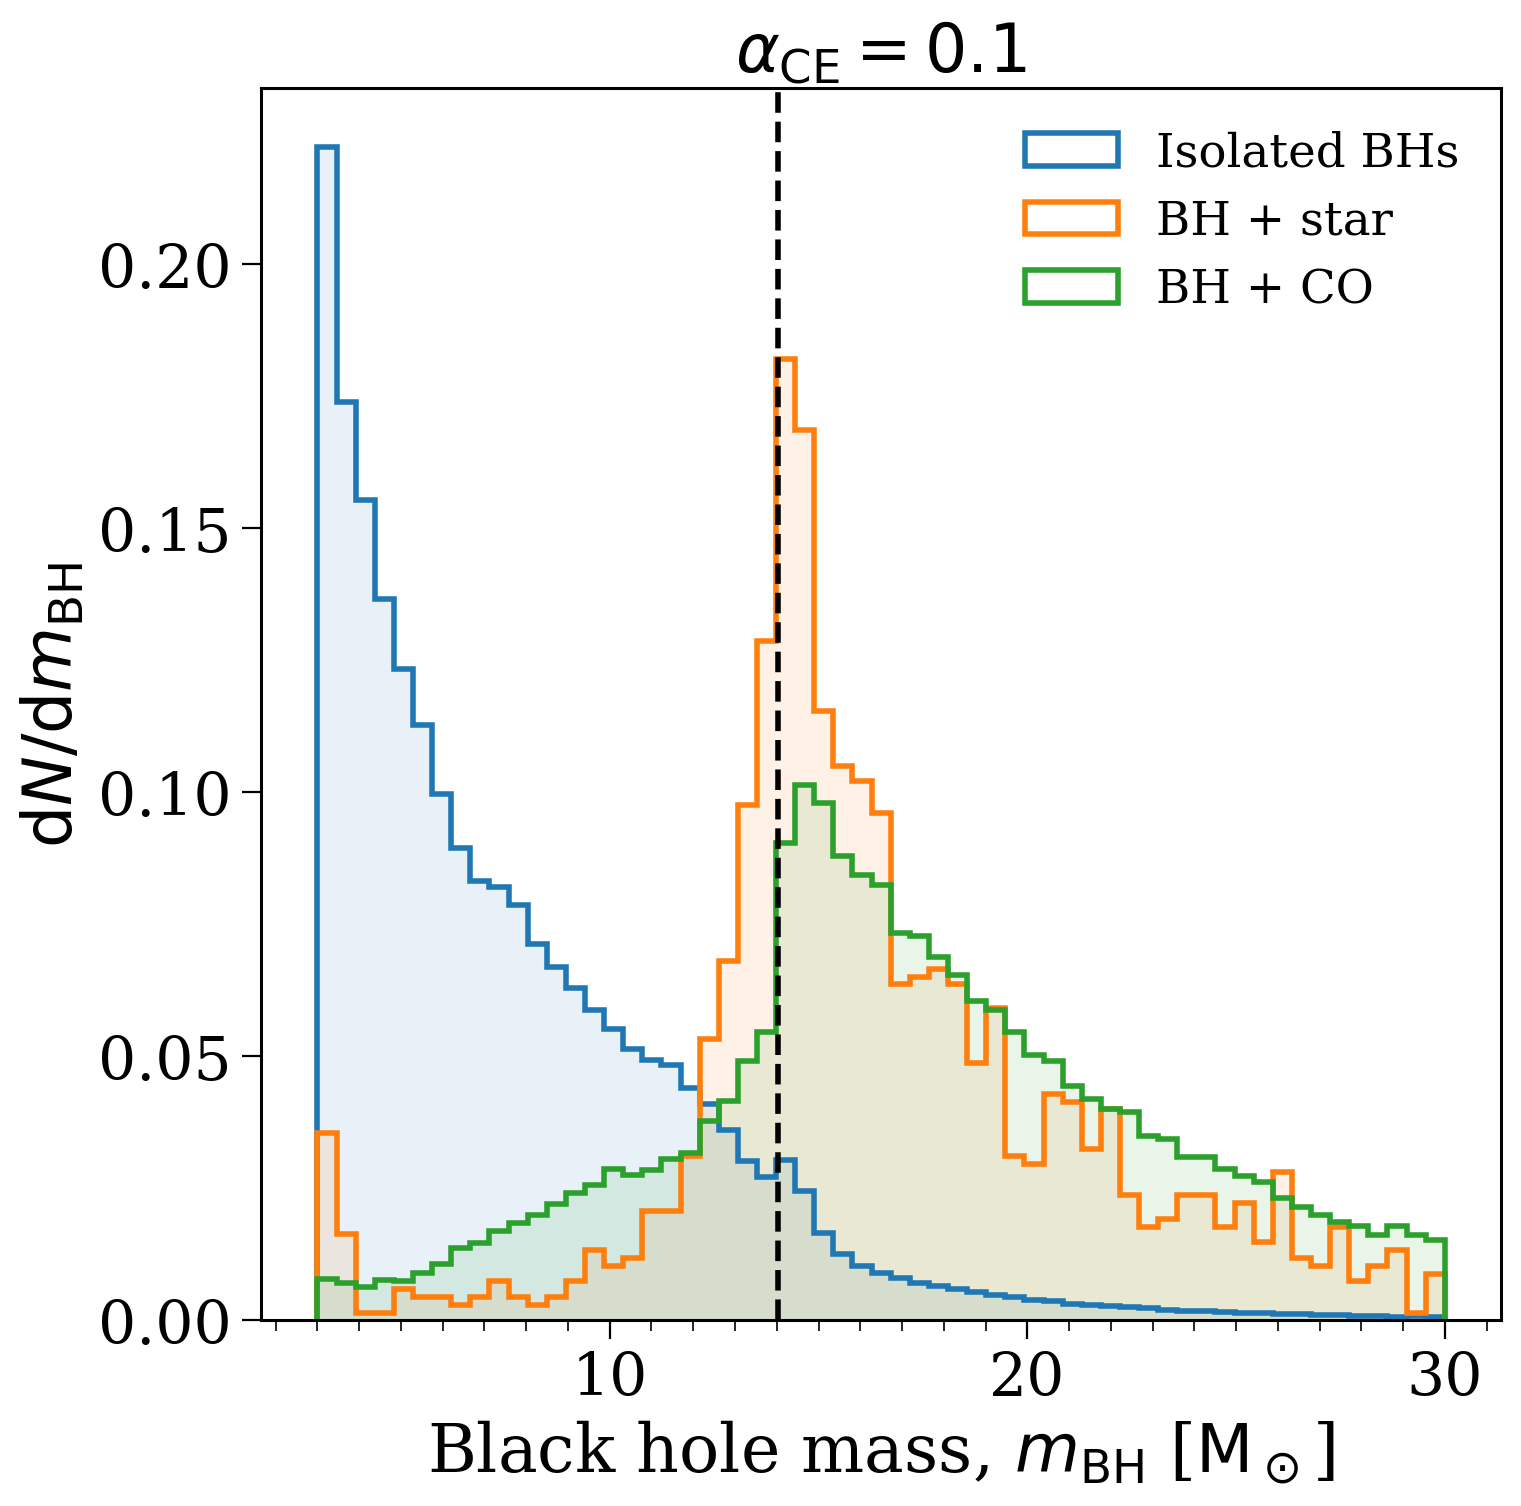

$\alpha_{\rm CE} = 0.5$ 1715


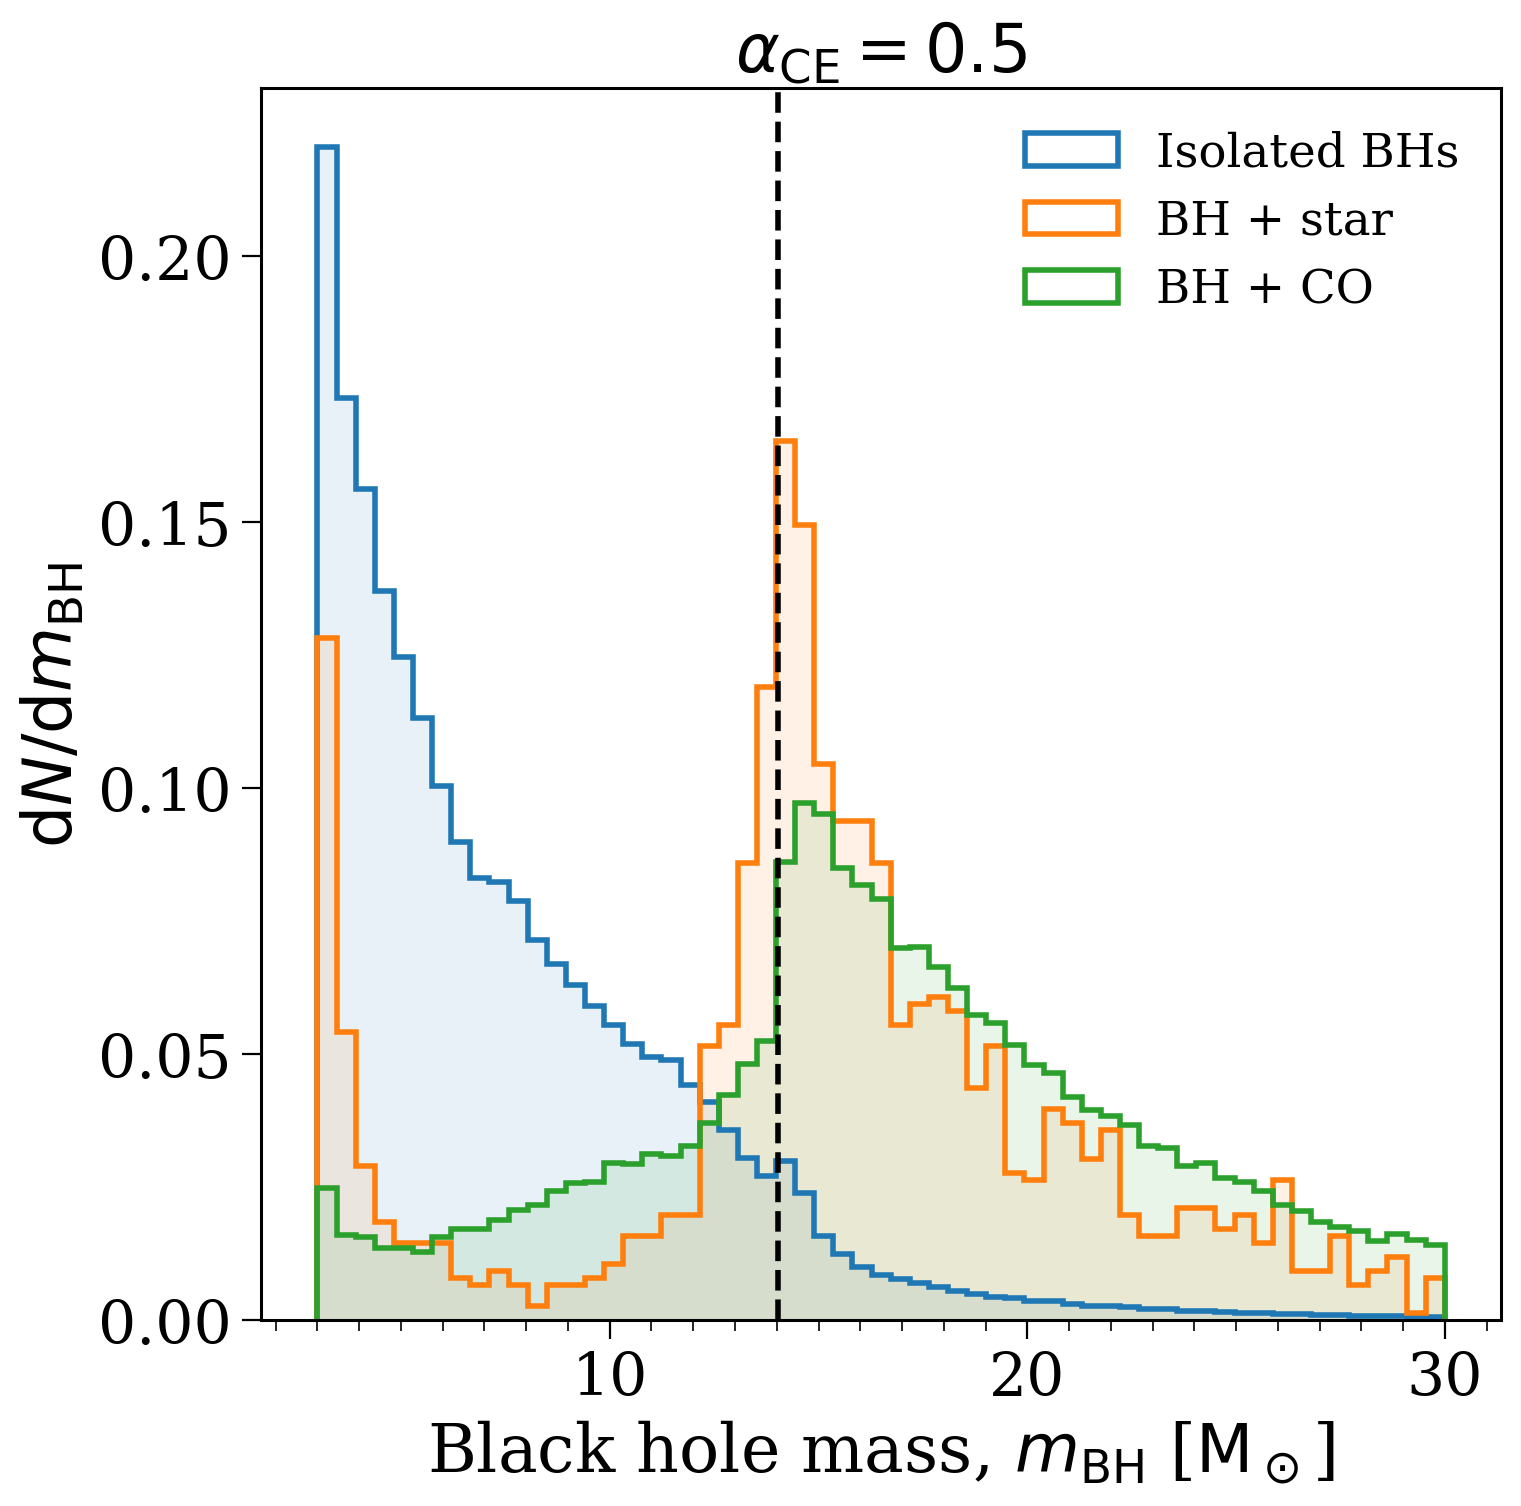

$\alpha_{\rm CE} = 2.0$ 1841


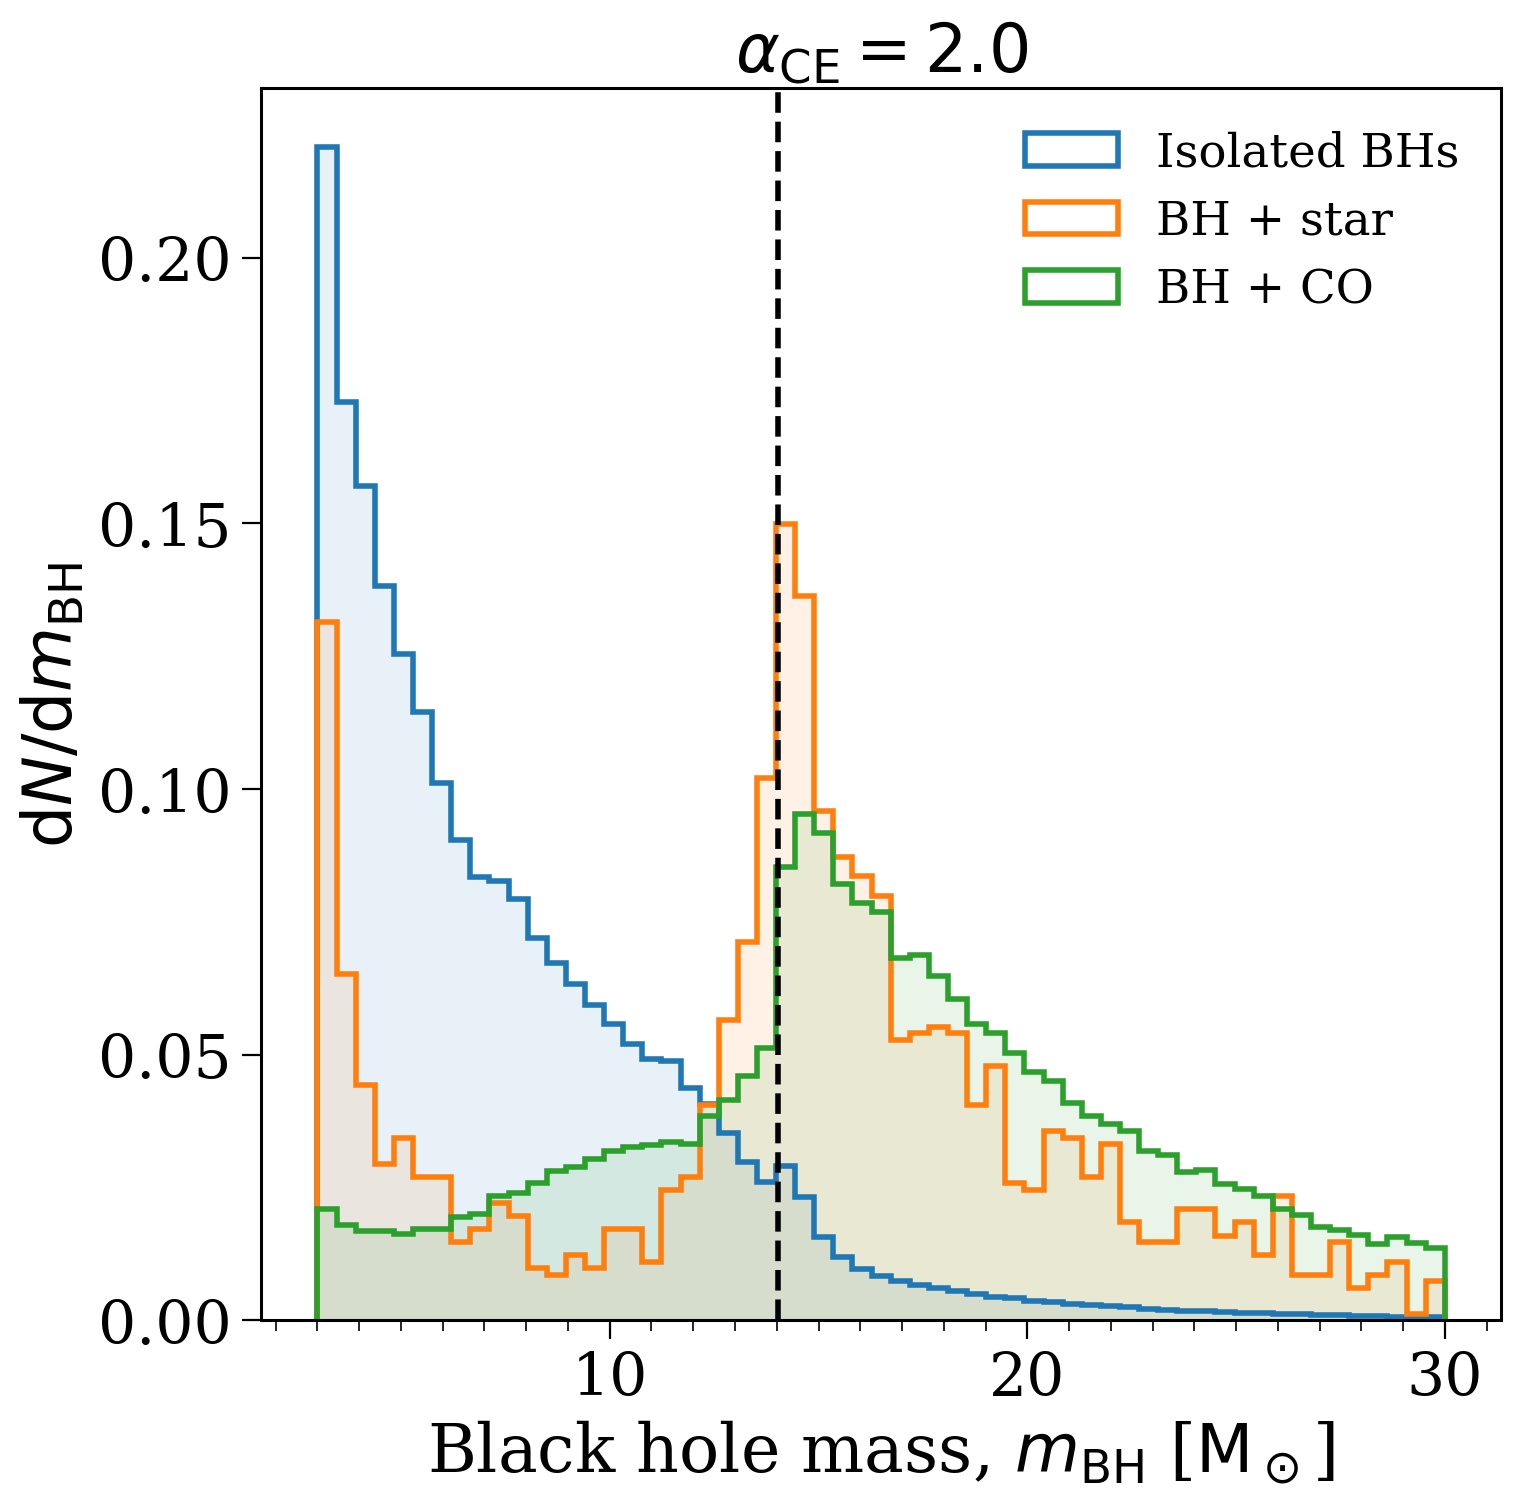

$\alpha_{\rm CE} = 10.0$ 2241


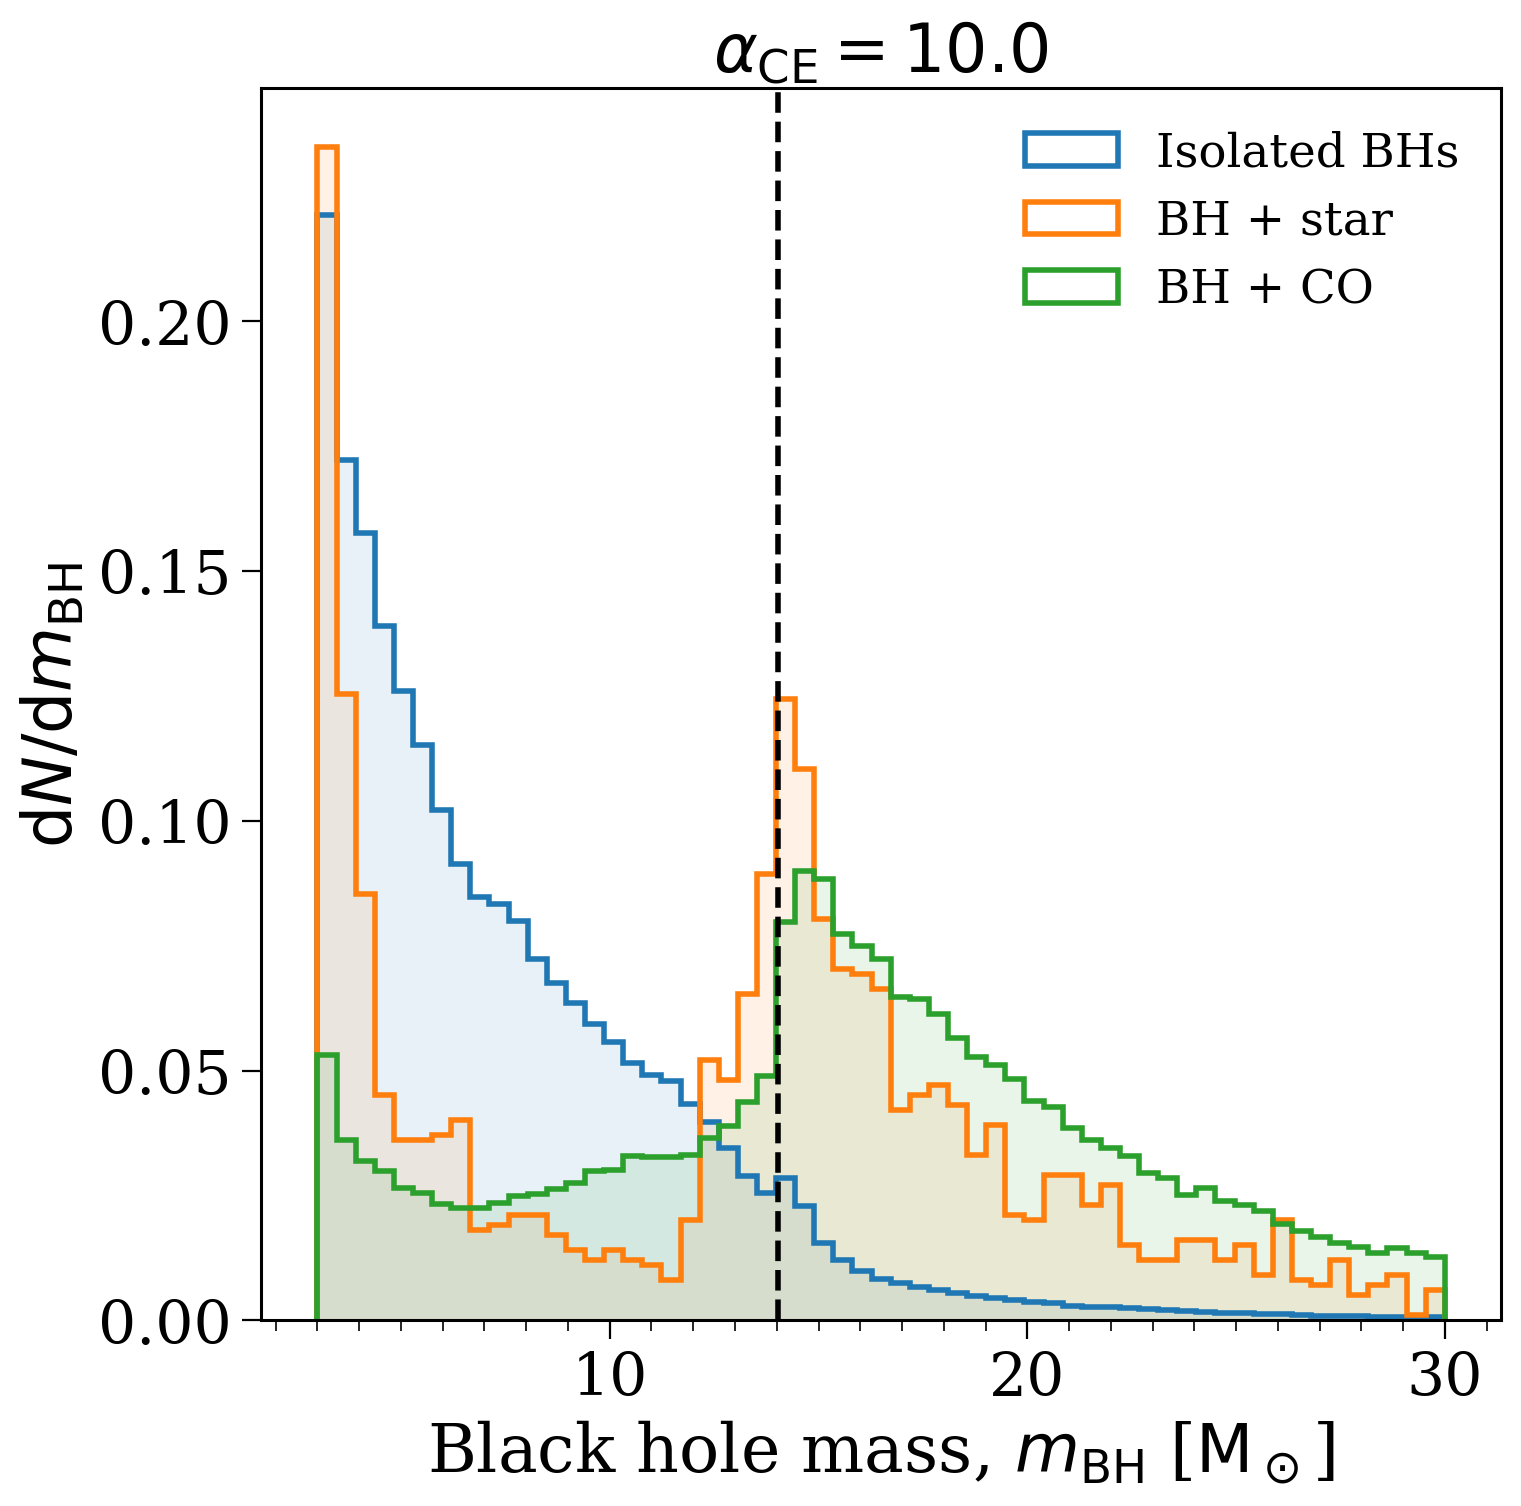

$q_{\rm crit, B} = 0$ 1785


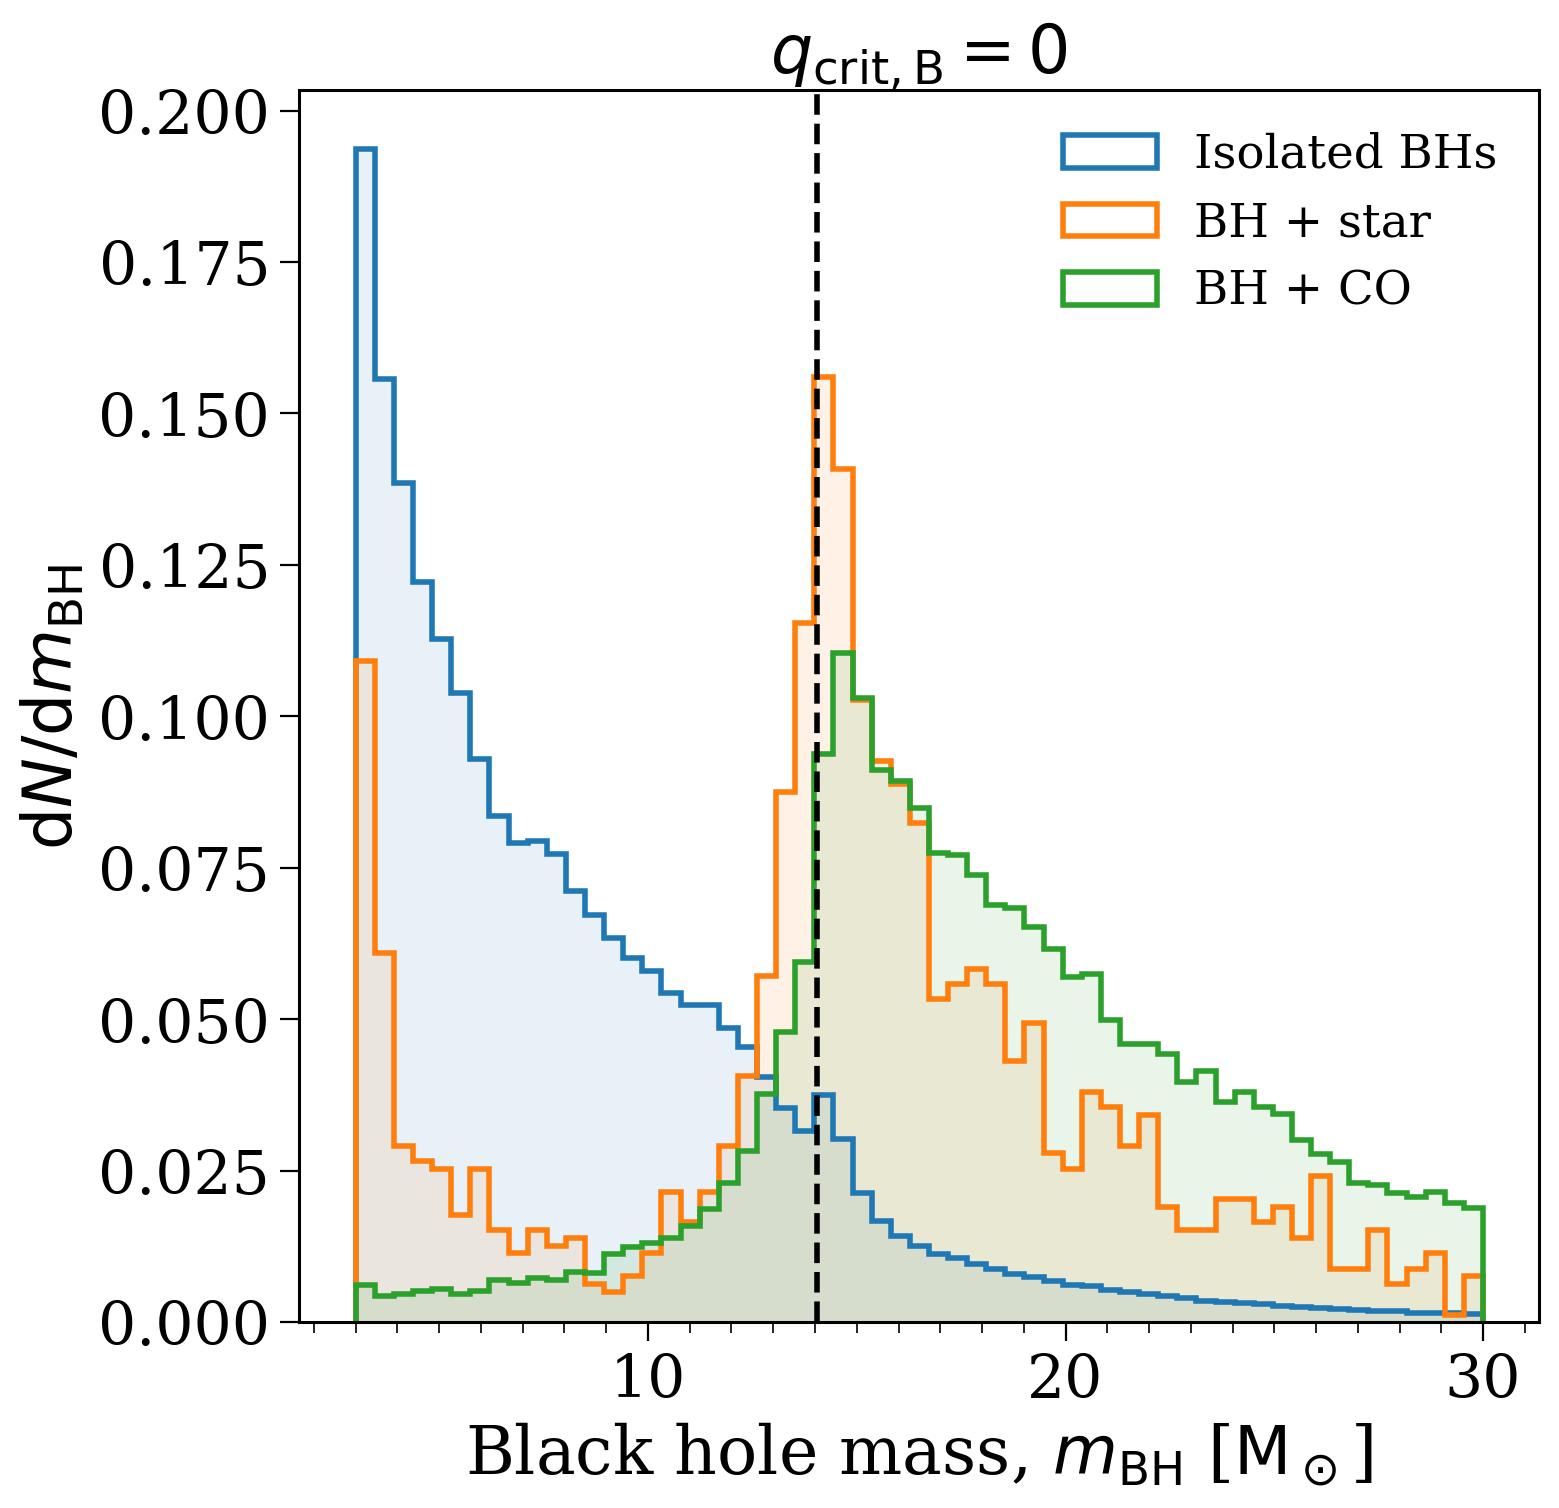

$q_{\rm crit, B} = \infty$ 2262


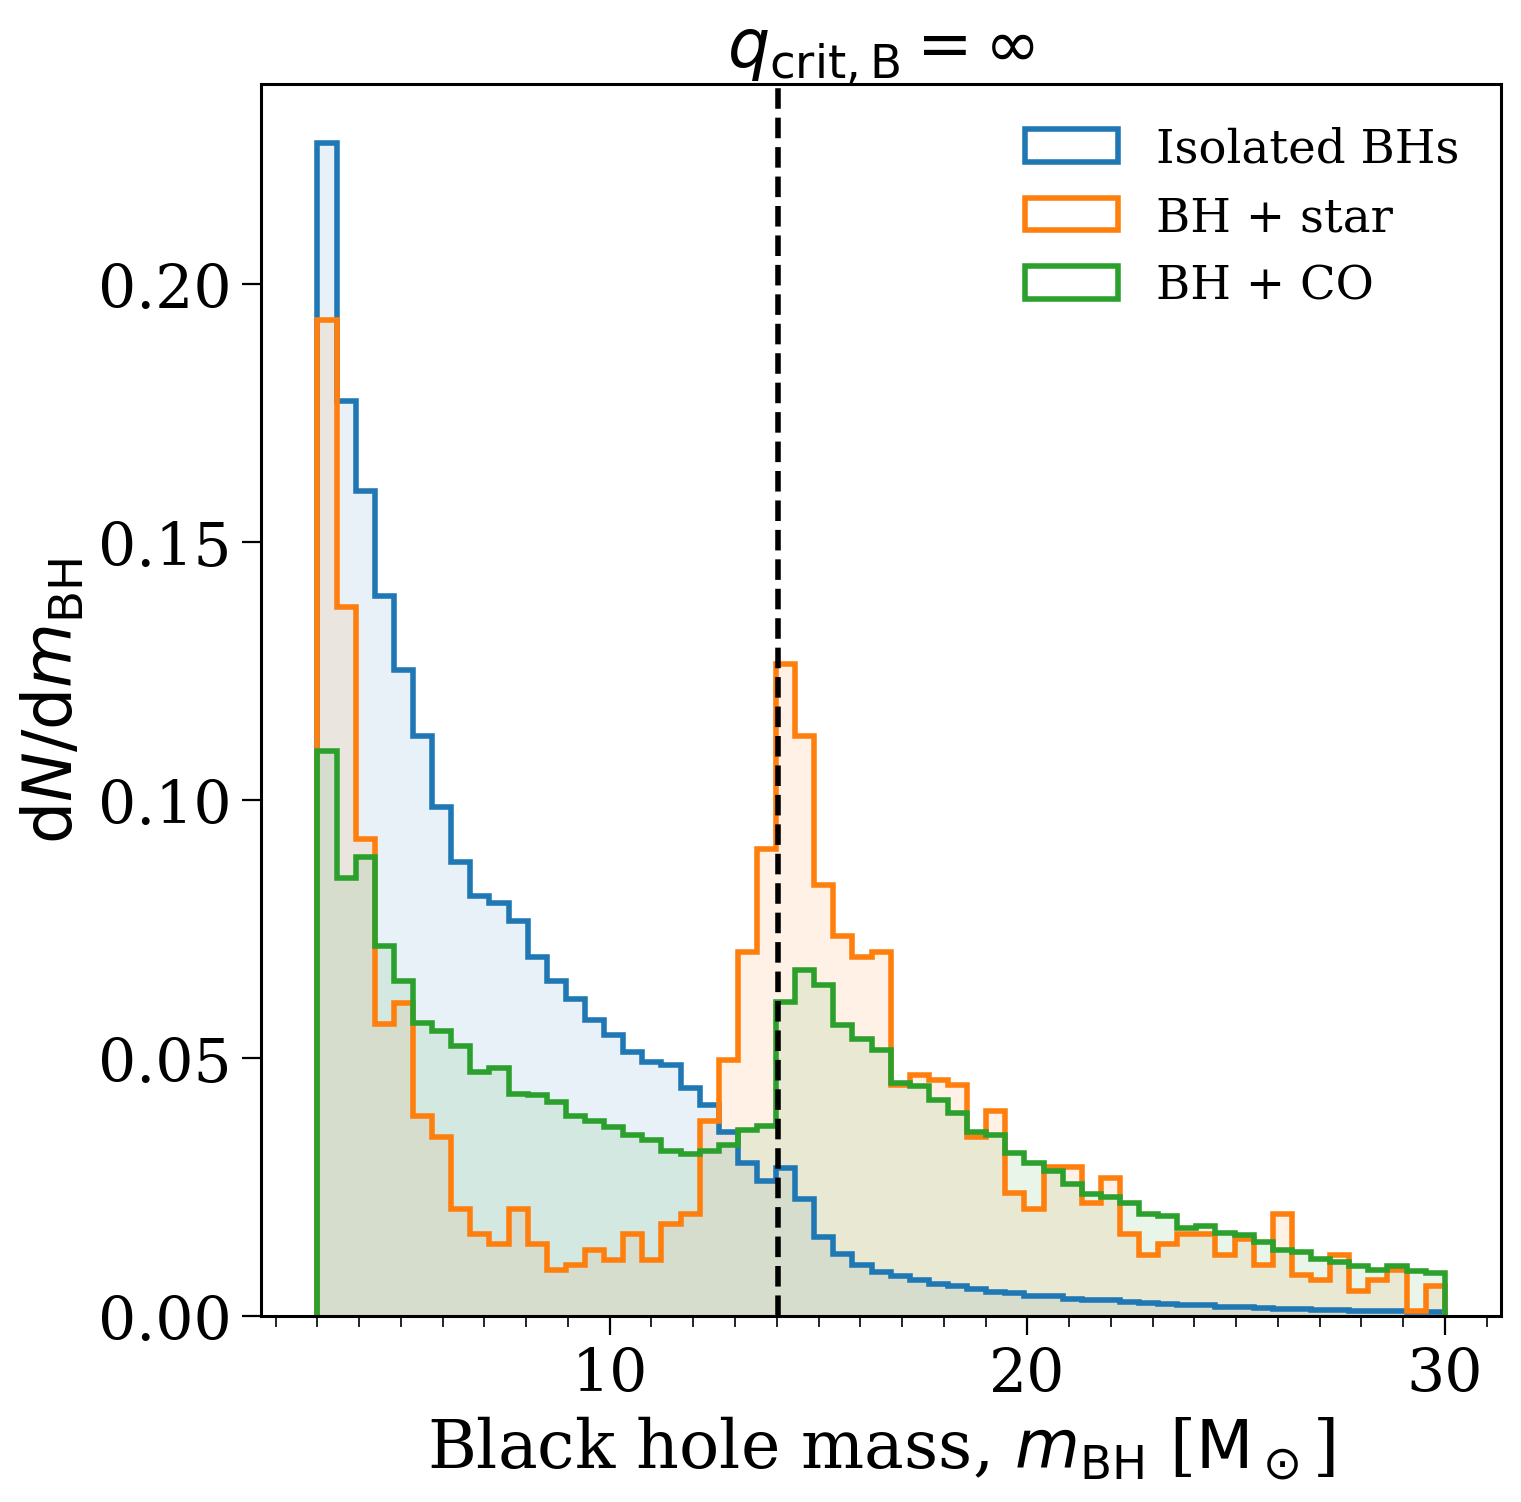

In [15]:
for pop_label in list(data.keys()):#['$f_{\\rm bin} = 1.0$', 'Fryer+2012 Rapid', 'Mandel\\&Muller2020', 'Maltsev+2025']:

    if pop_label == '$f_{\\rm bin} = 0.0$':
        continue

    fig, ax = plt.subplots(figsize=(8, 8))

    bins = np.linspace(3, 30, 60)
    density = True

    # pop_label = "Mandel\\&Muller2020"

    bh_bh = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["primary"]["BH"]) & (data[pop_label]["companion"]["BH"] == 14)
    bh_ns = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] == 13)
    bh_wd = (data[pop_label]["sep"]["BH"] > 0) & (np.isin(data[pop_label]["companion"]["BH"], [10, 11, 12]))
    bh_star = (data[pop_label]["sep"]["BH"] > 0) & (data[pop_label]["companion"]["BH"] < 10)

    print(pop_label, bh_star.sum())

    for masses, colour, label in zip(
        [
            data[pop_label]["mass"]["BH"][data[pop_label]["sep"]["BH"] <= 0],
            data[pop_label]["mass"]["BH"][bh_star],
            data[pop_label]["mass"]["BH"][bh_bh | bh_ns | bh_wd],
        ],
        ['tab:blue', 'tab:orange', 'tab:green'],
        ["Isolated BHs","BH + star", "BH + CO"]
    ):
        plotting.nice_transparent_hist(
            ax, data=masses, bins=bins, colour=colour, alpha=0.1, label=label, density=density, lw=2
        )

        # ["Isolated BHs\n(Microlensing)","BH + star\n(Astrometry or XRBs)", "BH + compact object\n(Gravitational waves)"]

    ax.axvline(14.04, ls='--', c='k', lw=2)

    # ax.annotate("Minimum BH mass\nfor full fallback", xy=(12, 0.14), fontsize=0.6*fs, ha='center', va='center', rotation=90)

    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    ax.xaxis.set_minor_locator(plt.MultipleLocator(1))

    leg = ax.legend(fontsize=0.7*fs, frameon=False, loc='upper right')#, labelspacing=1.2)

    ax.set(
        xlabel=r"Black hole mass, $m_{\mathrm{BH}}$ [$\rm M_\odot$]",
        ylabel=r"${\rm d}N/{\rm d}m_{\mathrm{BH}}$",
    )

    ax.set_title(plot_labels[labels.index(pop_label)], fontsize=fs)

    # plt.savefig("../plots/bh_binary_masses.pdf", bbox_inches='tight', format='pdf')
    plt.show()

# Interactive plot data

### BH mass histograms

In [29]:
#!/usr/bin/env python3
"""
Build the compact HDF5 histogram file for the Galactic Underworld interactive page.

Output: data/underworld/bh-mass.h5  (a precomputed 4-D histogram per model:
        [population(3), escaped(2), mass_bin, |z|_bin]).

You only need to implement `load_model_data()` below to return, for one model,
four equal-length arrays:  mass [Msun], height [kpc], separation, escaped [bool].
Everything else (binning, gzip, layout) is handled.
"""
import numpy as np
import h5py
import os

# ---------------------------------------------------------------------------
# 1. CONFIG — edit these to taste
# ---------------------------------------------------------------------------

# Mass bins (Msun): 2–60 in 1-Msun bins -> 58 bins. Fixed across ALL models so
# the histogram bars tween smoothly when switching models in the browser.
MASS_EDGES = np.arange(3.0, 60 + 0.25, 0.25)

# |z| bins (kpc): first bin [0, 0.01), then log-spaced out to 1000 kpc so
# escaped BHs pile into the top bin. ~50 bins.
Z_EDGES = np.concatenate([[0.0], np.logspace(-2, 3, 51)])

# Multiply raw simulated counts -> full-Milky-Way numbers.
# Set to (total MW star-forming mass) / (simulated star-forming mass).
# Paper simulates ~1/100th of the MW, so ~100. Use the exact value you used.
SCALE_TO_MW = 100.0

categories = np.concatenate([[g['title']] * len(g['members']) for g in groups])

OUTFILE = "bh-mass.h5"


# ---------------------------------------------------------------------------
# 2. YOUR DATA LOADER — implement this
# ---------------------------------------------------------------------------
def load_model_data(key):
    """
    Return four equal-length 1-D arrays for the model identified by `key`:

      mass       : BH mass                       [Msun]
      height     : signed Galactocentric z       [kpc]   (|z| is taken below)
      separation : 0 = merger, -1 = disruption, anything else = binary
      escaped    : bool, True if the BH escaped the Galaxy

    ~2 million entries per model is expected and fine.
    Replace the body below with however your simulation data is stored.
    """
    return data[key]["mass"]["BH"], data[key]["pos"]["BH"][:, 2], data[key]["sep"]["BH"], data[key]["escaped"]["BH"]

# ---------------------------------------------------------------------------
# 3. HISTOGRAMMING + WRITE  (no need to edit below here)
# ---------------------------------------------------------------------------
def population_index(separation):
    """0 = binary (default), 1 = merger (sep==0), 2 = disruption (sep==-1)."""
    return np.where(separation == 0, 1, np.where(separation == -1, 2, 0))


def build():
    n_mass = len(MASS_EDGES) - 1
    n_z = len(Z_EDGES) - 1
    print(f"Binning: {n_mass} mass bins x {n_z} |z| bins x 3 pop x 2 esc "
          f"= {3 * 2 * n_mass * n_z} cells/model, {len(labels)} models")

    with h5py.File(OUTFILE, "w") as f:
        f["mass_bin_centres"] = (0.5 * (MASS_EDGES[:-1] + MASS_EDGES[1:])).astype("f4")
        f["mass_bin_widths"] = np.diff(MASS_EDGES).astype("f4")
        f["z_bin_edges"] = Z_EDGES.astype("f4")
        f.attrs["scale_to_mw"] = float(SCALE_TO_MW)
        f["model_names"] = np.array(labels, dtype="S64")
        f["model_labels"] = np.array(plot_labels, dtype="S128")
        f["model_categories"] = np.array(categories, dtype="S64")

        for key, label, cat in zip(labels, plot_labels, categories):
            print(f"  {key} ...", end="", flush=True)
            mass, height, sep, escaped = load_model_data(key)
            mass = np.asarray(mass, dtype="f8")
            absz = np.abs(np.asarray(height, dtype="f8"))
            pop = population_index(np.asarray(sep))
            esc = np.asarray(escaped).astype(int)

            counts = np.zeros((3, 2, n_mass, n_z), dtype=np.uint32)
            for p in range(3):
                for e in range(2):
                    sel = (pop == p) & (esc == e)
                    if not np.any(sel):
                        continue
                    H, _, _ = np.histogram2d(
                        mass[sel], absz[sel], bins=[MASS_EDGES, Z_EDGES])
                    counts[p, e] = H.astype(np.uint32)

            f.create_dataset(
                f"counts/{key}", data=counts.ravel(order="C"),
                compression="gzip", compression_opts=9, shuffle=True)
            print(f" total BHs (raw) = {int(counts.sum()):,}  "
                  f"-> MW ~ {int(counts.sum() * SCALE_TO_MW):,}")

    size_mb = os.path.getsize(OUTFILE) / 1e6
    print(f"\nWrote {OUTFILE}  ({size_mb:.2f} MB)")
    
build()

Binning: 228 mass bins x 51 |z| bins x 3 pop x 2 esc = 69768 cells/model, 32 models
  $f_{\rm bin} = 1.0$ ...

 total BHs (raw) = 1,780,425  -> MW ~ 178,042,500
  No BH kicks ... total BHs (raw) = 1,761,843  -> MW ~ 176,184,300
  Hobbs+2005 ... total BHs (raw) = 1,867,720  -> MW ~ 186,772,000
  No fallback rescaling ... total BHs (raw) = 1,687,424  -> MW ~ 168,742,400
  Fryer+2012 Rapid ... total BHs (raw) = 1,387,963  -> MW ~ 138,796,300
  Mandel\&Muller2020 ... total BHs (raw) = 2,013,021  -> MW ~ 201,302,100
  Maltsev+2025 ... total BHs (raw) = 388,908  -> MW ~ 38,890,800
  $f_{\rm fb} = 0.0$ ... total BHs (raw) = 316,402  -> MW ~ 31,640,200
  $f_{\rm fb} = 0.25$ ... total BHs (raw) = 379,112  -> MW ~ 37,911,200
  $f_{\rm fb} = 0.75$ ... total BHs (raw) = 389,431  -> MW ~ 38,943,100
  $f_{\rm fb} = 1.0$ ... total BHs (raw) = 389,821  -> MW ~ 38,982,100
  $P({\rm pf}) = 0.0$ ... total BHs (raw) = 316,252  -> MW ~ 31,625,200
  $P({\rm pf}) = 1.0$ ... total BHs (raw) = 1,025,638  -> MW ~ 102,563,800
  Time-evolving potential ... total BHs (raw) = 1,766,463  -> MW ~ 176,646,300
  $f_{\rm bin} = 

### Summary plots

In [ ]:
summary_data = df.copy()
summary_data.index = plot_labels
summary_data.columns = ["N_BH", "M_BH", "h_z", "f_esc", "med_lo", "med_hi", "f_bound", "f_merger", "f_unbound", "N_BHstar", "N_BHWD", "N_BHNS", "N_BHBH", "N_NSstar", "N_NSWD", "N_NSNS"]
summary_data = summary_data[["N_BH", "M_BH", "h_z", "f_esc", "med_lo", "med_hi", "f_bound", "f_merger", "N_BHstar", "N_BHWD", "N_BHNS", "N_BHBH"]]

for col, norm in zip(
    ["N_BH", "M_BH", "N_BHstar", "N_BHWD", "N_BHNS", "N_BHBH"],
    [1e8, 1e9, 1e4, 1e5, 1e5, 1e6]
):
    summary_data[col] *= norm

categories = np.concatenate([[g['title']] * len(g['members']) for g in groups])
summary_data["category"] = categories
summary_data["colour"] = [mpl.colors.to_hex(c) for c in constants.SIMULATION_COLOURS]
summary_data["model"] = plot_labels

summary_data.to_json("summary.json", orient="records", indent=2)
summary_data

,N_BH,M_BH,h_z,f_esc,med_lo,med_hi,f_bound,f_merger,N_BHstar,N_BHWD,N_BHNS,N_BHBH,category,colour,label
Fiducial,1.731905e+08,1.501444e+09,786.337943,0.027179,7.698397,6.217435,0.086489,0.328966,1.707298e+05,1.270967e+06,138946.002823,6.699175e+06,Fiducial,#333333,Fiducial
No BH kicks,1.692311e+08,1.461937e+09,378.532048,0.000102,6.838759,8.624322,0.327220,0.354778,7.429338e+05,5.636771e+06,403106.648136,2.429654e+07,Supernova natal kicks,#65b860,No BH kicks
Hobbs+2005,1.808882e+08,1.561381e+09,1122.232525,0.026069,8.147527,6.079768,0.072844,0.306393,1.552700e+05,1.078440e+06,50988.477885,5.945967e+06,Supernova natal kicks,#c0d061,Hobbs+2005
No fallback rescaling,1.769824e+08,1.537990e+09,2557.123797,0.155036,6.381050,7.747932,0.004652,0.302035,2.246950e+04,2.763556e+05,45035.020957,2.397707e+05,Supernova natal kicks,#006400,No fallback rescaling
Fryer+2012 Rapid,1.337654e+08,1.499800e+09,518.822519,0.007342,9.297057,8.622036,0.152613,0.336537,3.800610e+05,2.479231e+06,352598.287745,8.601209e+06,Remnant mass prescriptions,#708090,Fryer+2012 Rapid
Mandel & Muller 2020,2.170842e+08,1.899494e+09,368.376604,0.000671,8.191211,7.113333,0.261853,0.414738,1.027740e+06,7.996357e+06,322927.026603,2.374853e+07,Remnant mass prescriptions,#9467bd,Mandel & Muller 2020
Maltsev+2025 (Default),3.753270e+07,4.686048e+08,467.532883,0.008038,9.657869,7.830750,0.175485,0.310500,1.502768e+05,1.057315e+06,372955.269499,2.502949e+06,Remnant mass prescriptions,#f14432,Maltsev+2025 (Default)
Maltsev+2025 ($f_{\rm fb} = 0.0$),3.047709e+07,4.230080e+08,397.640776,0.002927,9.819120,9.919802,0.213260,0.305156,1.505648e+05,1.053954e+06,386302.535838,2.454361e+06,Remnant mass prescriptions,#fdcab5,Maltsev+2025 ($f_{\rm fb} = 0.0$)
Maltsev+2025 ($f_{\rm fb} = 0.25$),3.677671e+07,4.467249e+08,469.759363,0.017465,9.704685,5.186043,0.177712,0.303530,1.505648e+05,1.058851e+06,363737.013611,2.481247e+06,Remnant mass prescriptions,#fc8a6a,Maltsev+2025 ($f_{\rm fb} = 0.25$)
Maltsev+2025 ($f_{\rm fb} = 0.75$),3.750063e+07,4.881557e+08,442.011160,0.003021,9.756445,9.603286,0.180362,0.312542,1.515251e+05,1.075463e+06,405795.306103,2.565460e+06,Remnant mass prescriptions,#bc141a,Maltsev+2025 ($f_{\rm fb} = 0.75$)
